## Run Linear Probes on Single Datasets & across Multiple Datasets

For more scheduled updates, see `../paper_notebooks/`

* Variations: SE -> Acc; SE -> SE; Acc -> Acc. <br>
* Across all layers for both SLT and TBG tokens. **Goal: find best layers**. <br>
* 2k samples of [SQUAD, trivia-qa, nq] by LLaMA-2-7B. <br>
* Binarization (best split via regression forest). <br>
* (Yes, done!) Take some time to alter the llama codes for keeping residuals and mlp outputs.

In [29]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns

import wandb
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240422_125709-vjb2jtnx/files')  # path for llama2-7b on trivia_qa (2k)
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240501_122139-p2dmjswm/files')  # path for llama2-7b on nq (3.61k) - we may take the first 2k.
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240320_140822-qlf5m8bq/files')  # path for llama2-7b on squad (2k) - not used

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Utility Functions

In [31]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [32]:
entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)  # replace semantic_entropy with cluster_assignment_entropy
print(entropy.shape, entropy)

torch.Size([2000]) tensor([0.3251, -0.0000, 2.0253,  ..., -0.0000, 0.8979, -0.0000])


In [33]:
# Define LR and MLP model structures (LR)
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid
from sklearn.linear_model import LogisticRegression, LinearRegression

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim=1, dropout=0.5):
        super(MLP, self).__init__()
        layers = []
        
        if isinstance(hid_dims, int):
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.append(Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(BatchNorm1d(layer_dims[i+1]))
            layers.append(ReLU())
            layers.append(Dropout(dropout))

        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)


class MLPClassifier(MLP):
    def __init__(self, in_dim, hid_dims, dropout):
        super().__init__(in_dim, hid_dims, out_dim=1, dropout=dropout)

    def forward(self, x):
        x = super().forward(x)
        x = torch.sigmoid(x) 
        return x

## Use Linear Probe for Predicting Semantic Entropy 

We experiment with the 'Last Input Token before Generation' first.

We train simple MLPs (4 hidden layers, 100 epochs w/ early stopping) on the token embeddings from each layer on _semantic entropy_ scores. 

In this section, we only prepare datasets for later transfer learning tasks.

In [34]:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
# Originally float64
ca_entropy = entropy.to(torch.float32)
mean = ca_entropy.mean()
std = ca_entropy.std()
print(ca_entropy.min(), ca_entropy.max(), mean, std)
ca_entropy = (ca_entropy - mean) / std

print(tok_bef_gen_dataset.shape, ca_entropy.shape)

tensor(-0.) tensor(2.3026) tensor(0.7473) tensor(0.7444)
torch.Size([2000, 33, 4096]) torch.Size([2000])


### Explore Token before First Generated Token (TBG)

We experment layer-by-layer.

In [35]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape)

torch.Size([33, 2000, 4096])


In [36]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset

from sklearn.model_selection import train_test_split

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size, set_seed=False, val_test_splits=[0.2, 0.1]):
    if set_seed:
        torch.manual_seed(42)
    
    indices = torch.randperm(total_size)
    test_size = int(total_size * val_test_splits[1])
    valid_size = int((total_size - test_size) * val_test_splits[0])
    train_size = total_size - test_size - valid_size

    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size + valid_size]
    test_indices = indices[train_size + valid_size:]

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    tbg_test_dataloaders = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        
        train_dataset_i = Subset(tensor_dataset_i, train_indices)
        valid_dataset_i = Subset(tensor_dataset_i, valid_indices)
        test_dataset_i = Subset(tensor_dataset_i, test_indices)
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        tbg_test_dataloaders.append(test_dataloader_i)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders
    
def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [37]:
# Training and testing helper function.
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)
        # train_score = model.score(X_train, y_train)
        # val_score = model.score(X_valid, y_valid)
        # print(f"Training R_squared: {train_score:.4f}, Validation R_squared: {val_score:.4f}")
    print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss


def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, 
                       binary_cls=False, title="", silent=False, lr=0.0005):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_valid_loss = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()

        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)

        if epoch == 0 or (epoch+1) % 10 == 0:
            if binary_cls:
                train_accuracy = total_train_correct / total_train_samples
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

    # Plot training and validation loss
    if not silent:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.title(f'Training and Validation Losses for {title}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return None

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                all_preds.extend(preds.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)

    if binary_cls:
        test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        auroc_score = roc_auc_score(all_labels, all_outputs) if len(set(all_labels)) > 1 else float('nan')
        
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return avg_test_loss, test_accuracy, auroc_score
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [38]:
# Plot the 1-D pooled test losses
from datetime import datetime

def plot_1d_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name} per Layer')
    plt.xlabel('Layer_i')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices)  # Assuming all models have the same number of layers
    plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/test_{metric_name}_per_layer_for_{"_".join(model_names)}_{formatted_time}.jpg')
    plt.show()

#### Binarize Entropy and Predict with Logistic Regression

We try binarizing the entropy scores and use logistic regression as with the accuracy prediction.

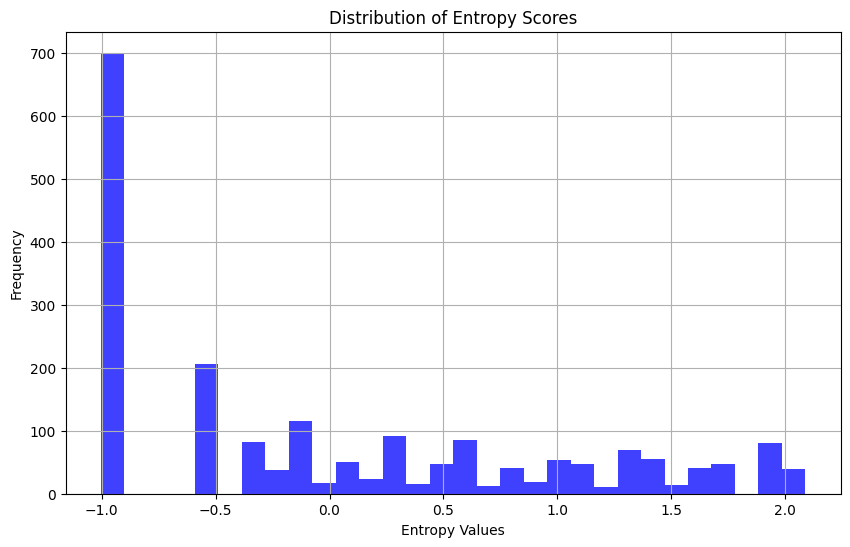

tensor(-1.0039) tensor(2.0892) tensor(1.) tensor(-5.8174e-08)


In [39]:
# Plot the entropy distribution
def plot_entropy_distribution(entropies):
    entropies_np = entropies.numpy()
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(entropies_np, bins=30, alpha=0.75, color='blue')
    plt.title('Distribution of Entropy Scores')  # Title of the histogram
    plt.xlabel('Entropy Values')  # Label for the x-axis
    plt.ylabel('Frequency')  # Label for the y-axis
    plt.grid(True) 
    plt.show()

plot_entropy_distribution(ca_entropy)
print(ca_entropy.min(), ca_entropy.max(), ca_entropy.var(), ca_entropy.mean())

def binarize_entropy(entropies, thres=0.0):
    binary_entropies = torch.full_like(entropies, -1, dtype=torch.float)
    binary_entropies[entropies < thres] = 0
    binary_entropies[entropies > thres] = 1

    return binary_entropies

bca_entropy = binarize_entropy(ca_entropy, 0.0)

# TODO: Use best split

We observe bimodal distribution for the normalized entropy values. The distribution is slightly skewed. **We decide to bin at 0.0 for even splits for now.**

In [40]:
# Fractions of 1's for binarized entropy
print(sum(bca_entropy)/len(bca_entropy))

tensor(0.4215)


In [41]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)

In [42]:
# Training with LR.
tblr_test_accs = []
tblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tblr_test_accs.append(test_acc)
    tblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.5778, AUROC: 0.5195
Training Loss: 0.5799, Validation Loss: 0.6845
Test Loss: 0.6702, Test Accuracy: 0.5600, AUROC: 0.5559
Training on Dataset 2/33
Validation Accuracy: 0.5667, AUROC: 0.5584
Training Loss: 0.5340, Validation Loss: 0.6936
Test Loss: 0.6725, Test Accuracy: 0.5450, AUROC: 0.5834
Training on Dataset 3/33
Validation Accuracy: 0.5750, AUROC: 0.5734
Training Loss: 0.4557, Validation Loss: 0.7202
Test Loss: 0.6880, Test Accuracy: 0.5750, AUROC: 0.5981
Training on Dataset 4/33
Validation Accuracy: 0.6111, AUROC: 0.6152
Training Loss: 0.3981, Validation Loss: 0.7101
Test Loss: 0.6852, Test Accuracy: 0.5950, AUROC: 0.6252
Training on Dataset 5/33
Validation Accuracy: 0.6111, AUROC: 0.6271
Training Loss: 0.3548, Validation Loss: 0.7226
Test Loss: 0.6853, Test Accuracy: 0.6250, AUROC: 0.6461
Training on Dataset 6/33
Validation Accuracy: 0.6139, AUROC: 0.6412
Training Loss: 0.3088, Validation Loss: 0.7342
Test Loss: 0.7007, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6694, AUROC: 0.6862
Training Loss: 0.2092, Validation Loss: 0.7751
Test Loss: 0.6316, Test Accuracy: 0.7000, AUROC: 0.7550
Training on Dataset 9/33
Validation Accuracy: 0.6833, AUROC: 0.7044
Training Loss: 0.1791, Validation Loss: 0.7829
Test Loss: 0.6619, Test Accuracy: 0.7100, AUROC: 0.7551
Training on Dataset 10/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6889, AUROC: 0.7146
Training Loss: 0.1482, Validation Loss: 0.8080
Test Loss: 0.7152, Test Accuracy: 0.6950, AUROC: 0.7571
Training on Dataset 11/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6972, AUROC: 0.7521
Training Loss: 0.0093, Validation Loss: 1.3520
Test Loss: 1.1468, Test Accuracy: 0.7000, AUROC: 0.8038
Training on Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.7367
Training Loss: 0.0090, Validation Loss: 1.4913
Test Loss: 1.1153, Test Accuracy: 0.7250, AUROC: 0.8166
Training on Dataset 33/33
Validation Accuracy: 0.6694, AUROC: 0.7353
Training Loss: 0.0094, Validation Loss: 1.5151
Test Loss: 1.1515, Test Accuracy: 0.7550, AUROC: 0.8120


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [43]:
print(f"LR on TBG embeddings and b-SE: best AUROC {max(tblr_test_aucs):.4f} at layer {np.argmax(tblr_test_aucs)+1}")

LR on TBG embeddings and b-SE: best AUROC 0.8305 at layer 14


### Explore Second Last generated Token (SLT)


In [45]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([2000, 33, 4096])


In [115]:
sec_last_tok_dataset.transpose(0, 1).shape

torch.Size([33, 2000, 4096])

In [46]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 2000, 4096]) torch.float32


In [18]:
# We may want to drop the first layer due to its homogeneity in values.
# print(slt_layered_datasets[0], slt_layered_datasets[0].shape)
# slt_layered_datasets = slt_layered_datasets[1:]

In [47]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)

In [48]:
# Training with LR.
sblr_test_accs = []
sblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sblr_test_accs.append(test_acc)
    sblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.5861, AUROC: 0.5000
Training Loss: 0.6819, Validation Loss: 0.6785
Test Loss: 0.6773, Test Accuracy: 0.5900, AUROC: 0.5000
Training on Dataset 2/33
Validation Accuracy: 0.5889, AUROC: 0.6121
Training Loss: 0.6727, Validation Loss: 0.6710
Test Loss: 0.6731, Test Accuracy: 0.5950, AUROC: 0.5588
Training on Dataset 3/33
Validation Accuracy: 0.5972, AUROC: 0.5778
Training Loss: 0.6645, Validation Loss: 0.6690
Test Loss: 0.6705, Test Accuracy: 0.5800, AUROC: 0.5653
Training on Dataset 4/33
Validation Accuracy: 0.6250, AUROC: 0.6219
Training Loss: 0.6441, Validation Loss: 0.6544
Test Loss: 0.6588, Test Accuracy: 0.6000, AUROC: 0.6068
Training on Dataset 5/33
Validation Accuracy: 0.6056, AUROC: 0.6424
Training Loss: 0.6237, Validation Loss: 0.6425
Test Loss: 0.6410, Test Accuracy: 0.6700, AUROC: 0.6519
Training on Dataset 6/33
Validation Accuracy: 0.6139, AUROC: 0.6778
Training Loss: 0.5758, Validation Loss: 0.6244
Test Loss: 0.6111, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6472, AUROC: 0.6990
Training Loss: 0.4653, Validation Loss: 0.6233
Test Loss: 0.5910, Test Accuracy: 0.6950, AUROC: 0.7376
Training on Dataset 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6833, AUROC: 0.7237
Training Loss: 0.4213, Validation Loss: 0.6113
Test Loss: 0.5811, Test Accuracy: 0.6950, AUROC: 0.7460
Training on Dataset 10/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7667, AUROC: 0.8298
Training Loss: 0.0090, Validation Loss: 1.2775
Test Loss: 1.0564, Test Accuracy: 0.7650, AUROC: 0.8395
Training on Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.8381
Training Loss: 0.0088, Validation Loss: 1.2647
Test Loss: 1.1947, Test Accuracy: 0.7550, AUROC: 0.8322
Training on Dataset 33/33
Validation Accuracy: 0.7750, AUROC: 0.8288
Training Loss: 0.0096, Validation Loss: 1.3051
Test Loss: 1.3091, Test Accuracy: 0.7450, AUROC: 0.8060


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [50]:
print(f"LR on SLT embeddings and b-SE: best AUROC {max(sblr_test_aucs):.4f} at layer {np.argmax(sblr_test_aucs)+1}")

LR on SLT embeddings and b-SE: best AUROC 0.8459 at layer 28


## Use Linear Probe for Predicting Correctness of Generated Answers (or Accuracy)

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

We will use logistic regression for this task, as for the binarized entropy prediction task.

### Token Before first Generation (TBG)

In [51]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([2000]) tensor([1., 1., 0., 1., 0., 0., 1., 0., 1., 0.])


In [52]:
# Prepare X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, accuracies, total_size)

In [53]:
# Dummy accuracy:
print(f"Dummy accuracy: {max(np.mean(y_tests), 1-np.mean(y_tests)):.4f}")

Dummy accuracy: 0.6250


Training on TBG-Acc Dataset 1/33
Validation Accuracy: 0.6639, AUROC: 0.5158
Training Loss: 0.5520, Validation Loss: 0.6365
Test Loss: 0.6232, Test Accuracy: 0.6700, AUROC: 0.6665
Training on TBG-Acc Dataset 2/33
Validation Accuracy: 0.6583, AUROC: 0.5278
Training Loss: 0.5098, Validation Loss: 0.6460
Test Loss: 0.6051, Test Accuracy: 0.6800, AUROC: 0.7005
Training on TBG-Acc Dataset 3/33
Validation Accuracy: 0.6611, AUROC: 0.5678
Training Loss: 0.4350, Validation Loss: 0.6539
Test Loss: 0.6088, Test Accuracy: 0.6450, AUROC: 0.6835
Training on TBG-Acc Dataset 4/33
Validation Accuracy: 0.6500, AUROC: 0.5945
Training Loss: 0.3778, Validation Loss: 0.6605
Test Loss: 0.6356, Test Accuracy: 0.6650, AUROC: 0.6721
Training on TBG-Acc Dataset 5/33
Validation Accuracy: 0.6444, AUROC: 0.5877
Training Loss: 0.3379, Validation Loss: 0.6942
Test Loss: 0.6577, Test Accuracy: 0.6600, AUROC: 0.6726
Training on TBG-Acc Dataset 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6278, AUROC: 0.5708
Training Loss: 0.3005, Validation Loss: 0.7449
Test Loss: 0.7133, Test Accuracy: 0.6200, AUROC: 0.6630
Training on TBG-Acc Dataset 7/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6361, AUROC: 0.6086
Training Loss: 0.2579, Validation Loss: 0.7243
Test Loss: 0.6845, Test Accuracy: 0.6800, AUROC: 0.6930
Training on TBG-Acc Dataset 8/33


...

Validation Accuracy: 0.6917, AUROC: 0.7120
Training Loss: 0.0295, Validation Loss: 0.9862
Test Loss: 0.8032, Test Accuracy: 0.7850, AUROC: 0.7885
Training on TBG-Acc Dataset 18/33
Validation Accuracy: 0.7111, AUROC: 0.7238
Training Loss: 0.0189, Validation Loss: 1.0420
Test Loss: 0.8427, Test Accuracy: 0.7750, AUROC: 0.7914
Training on TBG-Acc Dataset 19/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6833, AUROC: 0.6845
Training Loss: 0.0142, Validation Loss: 1.2383
Test Loss: 0.9108, Test Accuracy: 0.7300, AUROC: 0.7863
Training on TBG-Acc Dataset 20/33
Validation Accuracy: 0.7167, AUROC: 0.6880
Training Loss: 0.0113, Validation Loss: 1.2805
Test Loss: 0.8772, Test Accuracy: 0.7700, AUROC: 0.8013
Training on TBG-Acc Dataset 21/33
Validation Accuracy: 0.7056, AUROC: 0.6708
Training Loss: 0.0085, Validation Loss: 1.3457
Test Loss: 0.9690, Test Accuracy: 0.7500, AUROC: 0.7858
Training on TBG-Acc Dataset 22/33
Validation Accuracy: 0.7111, AUROC: 0.6895
Training Loss: 0.0061, Validation Loss: 1.3378
Test Loss: 1.0762, Test Accuracy: 0.7300, AUROC: 0.7772
Training on TBG-Acc Dataset 23/33
Validation Accuracy: 0.7056, AUROC: 0.7003
Training Loss: 0.0049, Validation Loss: 1.3012
Test Loss: 1.1039, Test Accuracy: 0.7350, AUROC: 0.7750
Training on TBG-Acc Dataset 24/33
Validation Accuracy: 0.7194, AUROC: 0.7034
Training Loss: 0.0040, Validation Loss: 1.2886
Test Loss:

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.6647
Training Loss: 0.0026, Validation Loss: 1.5261
Test Loss: 1.1891, Test Accuracy: 0.7450, AUROC: 0.7871


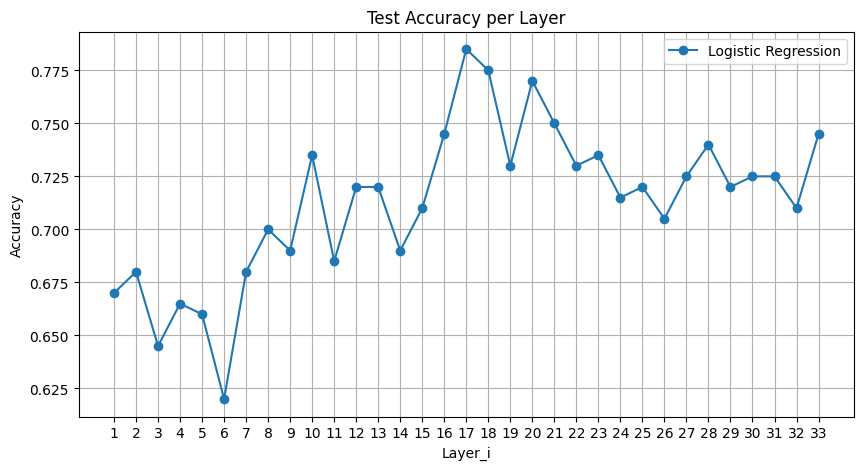

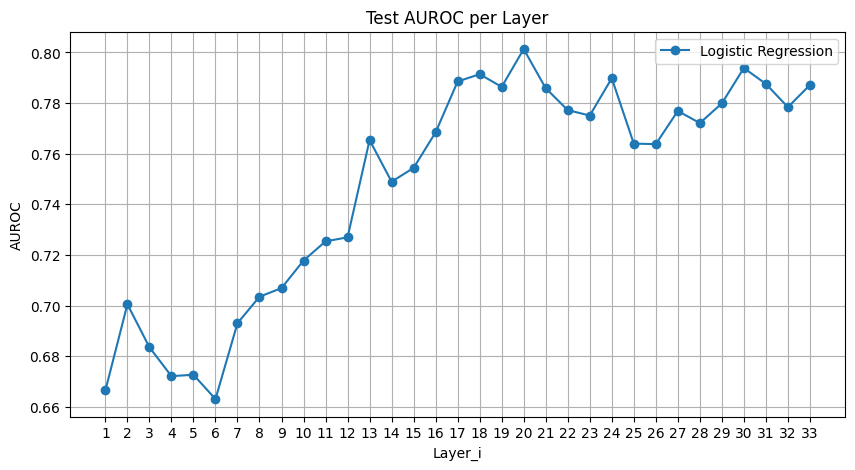

In [54]:
# Training Loops (LR)
talr_test_accs = []
talr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    talr_test_accs.append(test_acc)
    talr_test_aucs.append(test_auc)

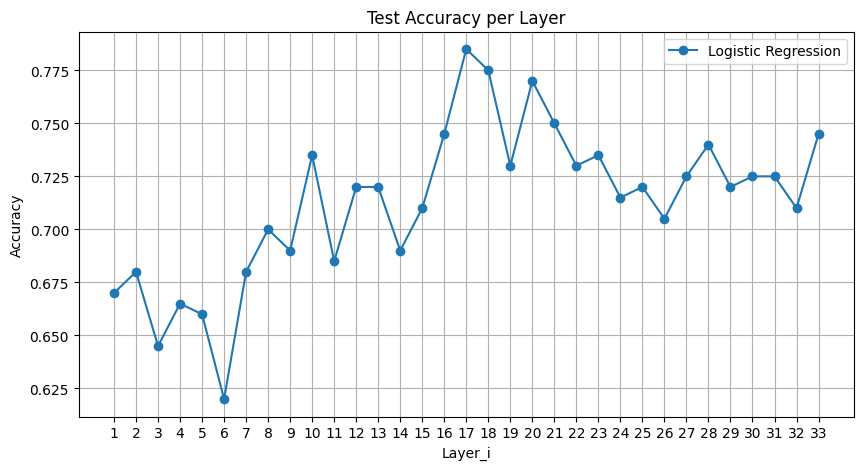

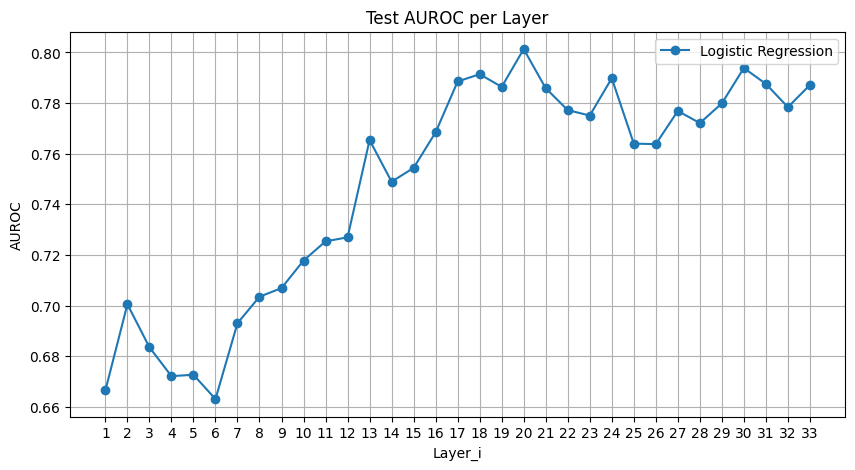

In [55]:
plot_1d_metrics([talr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([talr_test_aucs], ['Logistic Regression'], 'AUROC')

In [56]:
print(f"LR on TBG embeddings and Accuracy: best AUROC {max(talr_test_aucs):.4f} at layer {np.argmax(talr_test_aucs)+1}")

LR on TBG embeddings and Accuracy: best AUROC 0.8013 at layer 20


In [57]:
# Data for SLT embeddings
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, accuracies, total_size)

In [58]:
# Training with LR.
salr_test_accs = []
salr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    salr_test_accs.append(test_acc)
    salr_test_aucs.append(test_auc)

Training on SLT-Acc Dataset 1/33
Validation Accuracy: 0.6750, AUROC: 0.5000
Training Loss: 0.6500, Validation Loss: 0.6325
Test Loss: 0.6625, Test Accuracy: 0.6250, AUROC: 0.5000
Training on SLT-Acc Dataset 2/33
Validation Accuracy: 0.6750, AUROC: 0.5260
Training Loss: 0.6418, Validation Loss: 0.6296
Test Loss: 0.6586, Test Accuracy: 0.6250, AUROC: 0.5854
Training on SLT-Acc Dataset 3/33
Validation Accuracy: 0.6750, AUROC: 0.5365
Training Loss: 0.6363, Validation Loss: 0.6278
Test Loss: 0.6569, Test Accuracy: 0.6250, AUROC: 0.5854
Training on SLT-Acc Dataset 4/33
Validation Accuracy: 0.6806, AUROC: 0.5851
Training Loss: 0.6211, Validation Loss: 0.6200
Test Loss: 0.6554, Test Accuracy: 0.6200, AUROC: 0.5707
Training on SLT-Acc Dataset 5/33
Validation Accuracy: 0.6833, AUROC: 0.6016
Training Loss: 0.6086, Validation Loss: 0.6144
Test Loss: 0.6486, Test Accuracy: 0.6300, AUROC: 0.5939
Training on SLT-Acc Dataset 6/33
Validation Accuracy: 0.6861, AUROC: 0.6098
Training Loss: 0.5703, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6667, AUROC: 0.6430
Training Loss: 0.5342, Validation Loss: 0.6019
Test Loss: 0.6203, Test Accuracy: 0.6800, AUROC: 0.6640
Training on SLT-Acc Dataset 8/33
Validation Accuracy: 0.6778, AUROC: 0.6666
Training Loss: 0.4737, Validation Loss: 0.5984
Test Loss: 0.6193, Test Accuracy: 0.6700, AUROC: 0.6729
Training on SLT-Acc Dataset 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.6943
Training Loss: 0.4289, Validation Loss: 0.5838
Test Loss: 0.5890, Test Accuracy: 0.6800, AUROC: 0.7126
Training on SLT-Acc Dataset 10/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7611, AUROC: 0.7970
Training Loss: 0.0324, Validation Loss: 0.7893
Test Loss: 0.8308, Test Accuracy: 0.7450, AUROC: 0.7886
Training on SLT-Acc Dataset 19/33
Validation Accuracy: 0.7778, AUROC: 0.7866
Training Loss: 0.0238, Validation Loss: 0.8204
Test Loss: 0.9743, Test Accuracy: 0.7350, AUROC: 0.7626
Training on SLT-Acc Dataset 20/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7556, AUROC: 0.7684
Training Loss: 0.0185, Validation Loss: 0.9419
Test Loss: 1.0492, Test Accuracy: 0.7750, AUROC: 0.7742
Training on SLT-Acc Dataset 21/33
Validation Accuracy: 0.7278, AUROC: 0.7482
Training Loss: 0.0127, Validation Loss: 1.0475
Test Loss: 0.9388, Test Accuracy: 0.7600, AUROC: 0.7868
Training on SLT-Acc Dataset 22/33
Validation Accuracy: 0.7028, AUROC: 0.7097
Training Loss: 0.0082, Validation Loss: 1.3923
Test Loss: 1.1712, Test Accuracy: 0.7300, AUROC: 0.7654
Training on SLT-Acc Dataset 23/33
Validation Accuracy: 0.7000, AUROC: 0.7234
Training Loss: 0.0061, Validation Loss: 1.4137
Test Loss: 1.3273, Test Accuracy: 0.7550, AUROC: 0.7537
Training on SLT-Acc Dataset 24/33
Validation Accuracy: 0.7194, AUROC: 0.7570
Training Loss: 0.0048, Validation Loss: 1.2491
Test Loss: 1.3174, Test Accuracy: 0.7550, AUROC: 0.7700
Training on SLT-Acc Dataset 25/33
Validation Accuracy: 0.7139, AUROC: 0.7557
Training Loss: 0.0040, Validation Loss: 1.2427
Test Loss:

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


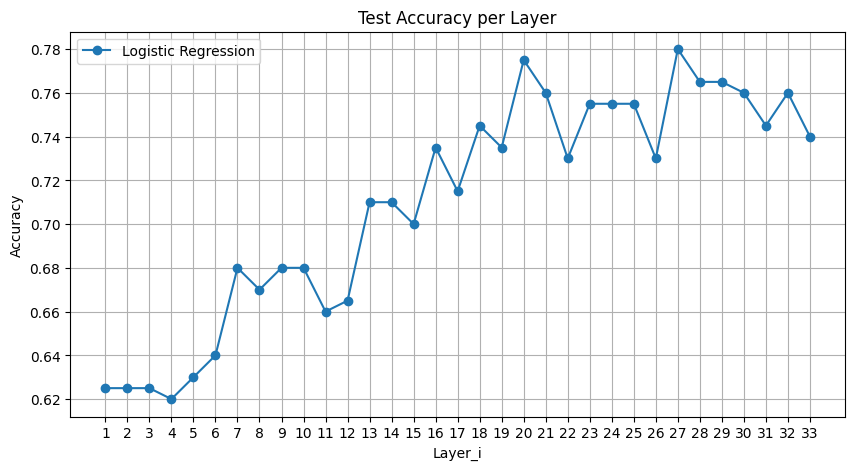

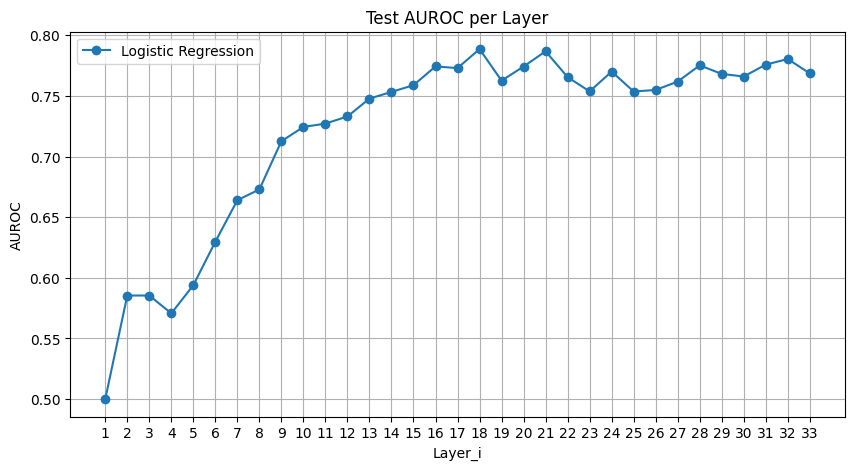

In [59]:
plot_1d_metrics([salr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([salr_test_aucs], ['Logistic Regression'], 'AUROC')

In [60]:
print(f"LR on SLT embeddings and Accuracy: best AUROC {max(salr_test_aucs):.4f} at layer {np.argmax(salr_test_aucs)+1}")

LR on SLT embeddings and Accuracy: best AUROC 0.7886 at layer 18


## Use Classifier for Binary SE for Predicting LLM Accuracy

We want to show that models trained on binary SE are more generalizable to new datasets when predicting their generation correctness.

In [61]:
# Test with accuracy test set (with the same random seed to ensure no data leakage)
# We should reverse the accuracy due to negative R.
r_accuracies = 1 - accuracies

X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, r_accuracies, total_size)

In [62]:
# Training Loops (LR)
tablr_test_accs = []
tablr_test_aucs = []
tablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tablr_test_accs.append(test_acc)
    tablr_test_aucs.append(test_auc)
    tablr_trained_models.append(model)

Training on TBG Dataset 1/33
Validation Accuracy: 0.5778, AUROC: 0.5195
Training Loss: 0.5799, Validation Loss: 0.6845
Test Loss: 0.6609, Test Accuracy: 0.5750, AUROC: 0.5324
Training on TBG Dataset 2/33
Validation Accuracy: 0.5667, AUROC: 0.5584
Training Loss: 0.5340, Validation Loss: 0.6936
Test Loss: 0.6758, Test Accuracy: 0.5600, AUROC: 0.5392
Training on TBG Dataset 3/33
Validation Accuracy: 0.5750, AUROC: 0.5734
Training Loss: 0.4557, Validation Loss: 0.7202
Test Loss: 0.6950, Test Accuracy: 0.5900, AUROC: 0.5795
Training on TBG Dataset 4/33
Validation Accuracy: 0.6111, AUROC: 0.6152
Training Loss: 0.3981, Validation Loss: 0.7101
Test Loss: 0.7049, Test Accuracy: 0.6000, AUROC: 0.5979
Training on TBG Dataset 5/33
Validation Accuracy: 0.6111, AUROC: 0.6271
Training Loss: 0.3548, Validation Loss: 0.7226
Test Loss: 0.7313, Test Accuracy: 0.6100, AUROC: 0.5991
Training on TBG Dataset 6/33
Validation Accuracy: 0.6139, AUROC: 0.6412
Training Loss: 0.3088, Validation Loss: 0.7342
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6694, AUROC: 0.6862
Training Loss: 0.2092, Validation Loss: 0.7751
Test Loss: 0.7645, Test Accuracy: 0.6550, AUROC: 0.6611
Training on TBG Dataset 9/33
Validation Accuracy: 0.6833, AUROC: 0.7044
Training Loss: 0.1791, Validation Loss: 0.7829
Test Loss: 0.8377, Test Accuracy: 0.6450, AUROC: 0.6643
Training on TBG Dataset 10/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6889, AUROC: 0.7146
Training Loss: 0.1482, Validation Loss: 0.8080
Test Loss: 0.8795, Test Accuracy: 0.6600, AUROC: 0.6738
Training on TBG Dataset 11/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6972, AUROC: 0.7521
Training Loss: 0.0093, Validation Loss: 1.3520
Test Loss: 1.7248, Test Accuracy: 0.6650, AUROC: 0.7162
Training on TBG Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6944, AUROC: 0.7367
Training Loss: 0.0090, Validation Loss: 1.4913
Test Loss: 1.8068, Test Accuracy: 0.6500, AUROC: 0.7156
Training on TBG Dataset 33/33
Validation Accuracy: 0.6694, AUROC: 0.7353
Training Loss: 0.0094, Validation Loss: 1.5151
Test Loss: 1.7032, Test Accuracy: 0.7100, AUROC: 0.7403


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


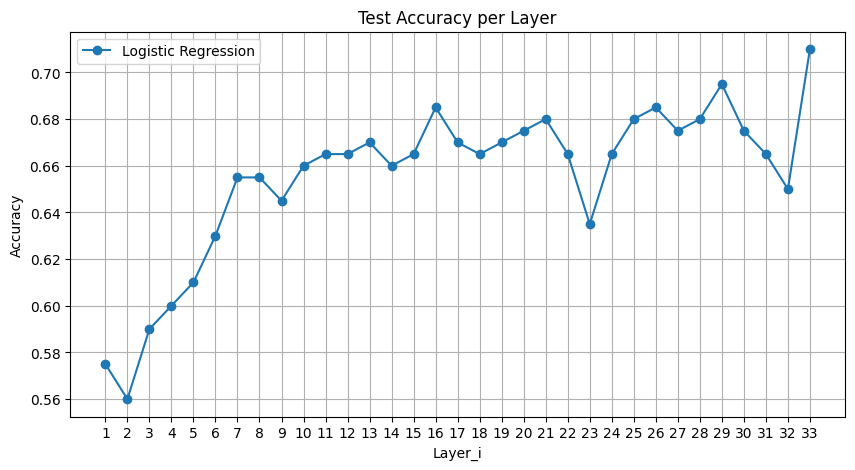

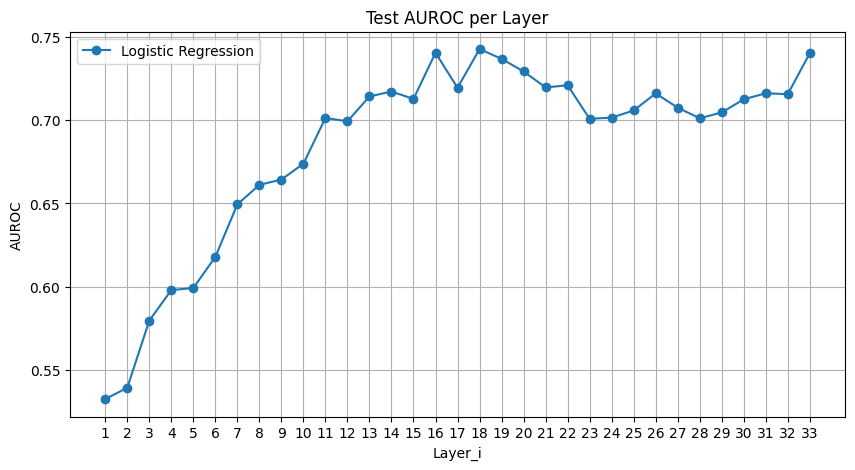

In [64]:
plot_1d_metrics([tablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tablr_test_aucs], ['Logistic Regression'], 'AUROC')

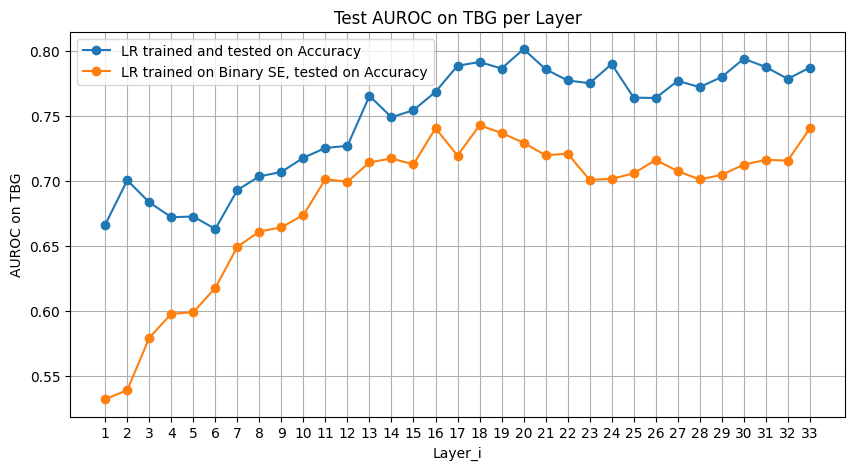

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8013 at 20 layer
TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.7427 at 18 layer


In [65]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([talr_test_aucs, tablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")

Now we test on SLT embeddings.

In [66]:
X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(slt_layered_datasets, r_accuracies, total_size)

In [67]:
# Training Loops (LR)
sablr_test_accs = []
sablr_test_aucs = []
sablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sablr_test_accs.append(test_acc)
    sablr_test_aucs.append(test_auc)
    sablr_trained_models.append(model)

Training on SLT Dataset 1/33
Validation Accuracy: 0.5861, AUROC: 0.5000
Training Loss: 0.6819, Validation Loss: 0.6785
Test Loss: 0.6668, Test Accuracy: 0.6250, AUROC: 0.5000
Training on SLT Dataset 2/33
Validation Accuracy: 0.5889, AUROC: 0.6121
Training Loss: 0.6727, Validation Loss: 0.6710
Test Loss: 0.6682, Test Accuracy: 0.6300, AUROC: 0.4971
Training on SLT Dataset 3/33
Validation Accuracy: 0.5972, AUROC: 0.5778
Training Loss: 0.6645, Validation Loss: 0.6690
Test Loss: 0.6677, Test Accuracy: 0.6150, AUROC: 0.5035
Training on SLT Dataset 4/33
Validation Accuracy: 0.6250, AUROC: 0.6219
Training Loss: 0.6441, Validation Loss: 0.6544
Test Loss: 0.6668, Test Accuracy: 0.5950, AUROC: 0.5437
Training on SLT Dataset 5/33
Validation Accuracy: 0.6056, AUROC: 0.6424
Training Loss: 0.6237, Validation Loss: 0.6425
Test Loss: 0.6512, Test Accuracy: 0.6350, AUROC: 0.6027
Training on SLT Dataset 6/33
Validation Accuracy: 0.6139, AUROC: 0.6778
Training Loss: 0.5758, Validation Loss: 0.6244
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6472, AUROC: 0.6990
Training Loss: 0.4653, Validation Loss: 0.6233
Test Loss: 0.6305, Test Accuracy: 0.6800, AUROC: 0.6858
Training on SLT Dataset 9/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6833, AUROC: 0.7237
Training Loss: 0.4213, Validation Loss: 0.6113
Test Loss: 0.6149, Test Accuracy: 0.6700, AUROC: 0.7021
Training on SLT Dataset 10/33


...

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7667, AUROC: 0.8298
Training Loss: 0.0090, Validation Loss: 1.2775
Test Loss: 1.6703, Test Accuracy: 0.6800, AUROC: 0.7506
Training on SLT Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.8381
Training Loss: 0.0088, Validation Loss: 1.2647
Test Loss: 1.8331, Test Accuracy: 0.7100, AUROC: 0.7485
Training on SLT Dataset 33/33
Validation Accuracy: 0.7750, AUROC: 0.8288
Training Loss: 0.0096, Validation Loss: 1.3051
Test Loss: 1.8586, Test Accuracy: 0.6800, AUROC: 0.7406


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


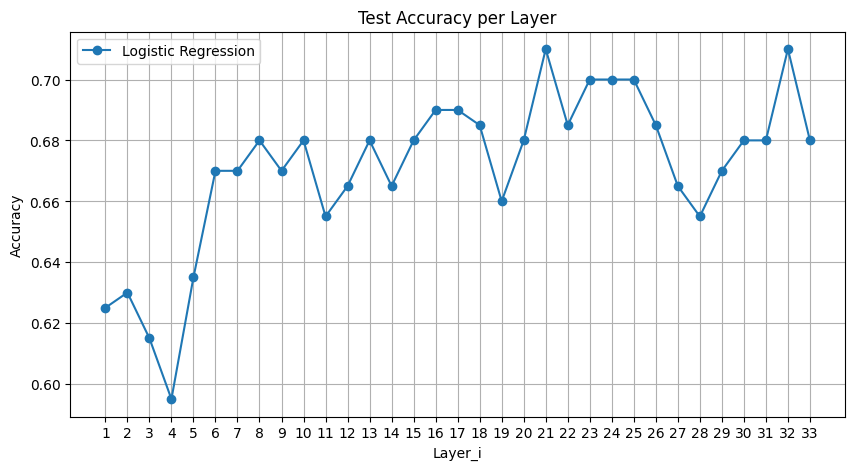

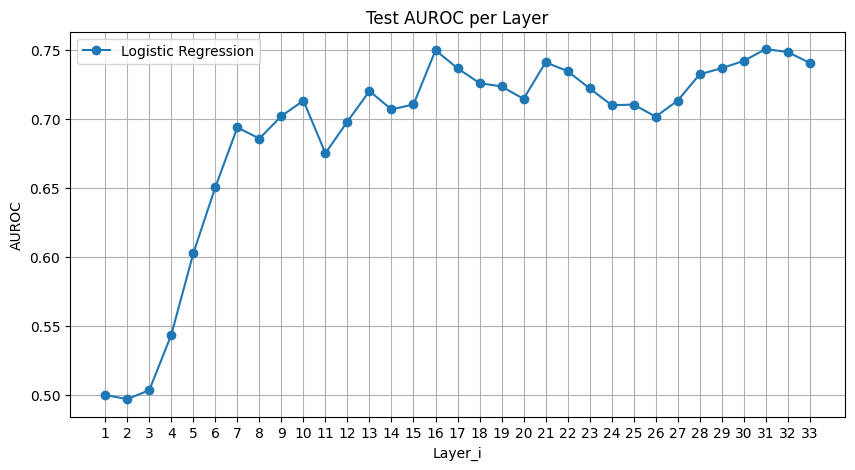

In [68]:
plot_1d_metrics([sablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([sablr_test_aucs], ['Logistic Regression'], 'AUROC')

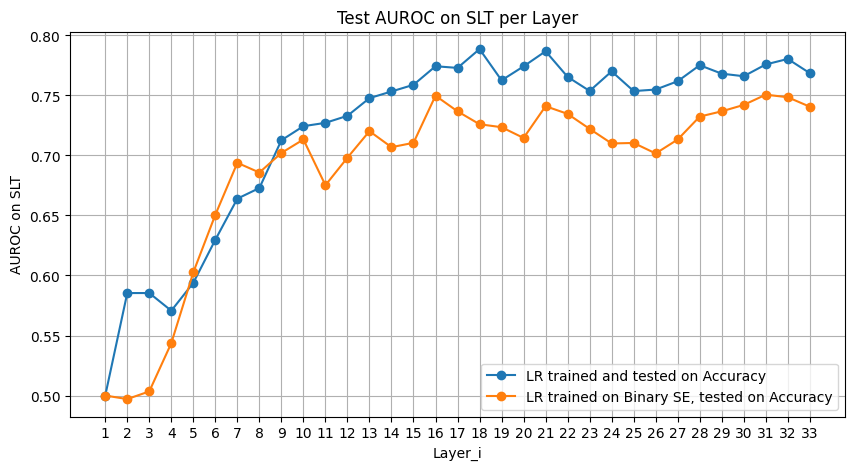

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7886 at 18 layer
SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.7506 at 31 layer


In [69]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([salr_test_aucs, sablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")

### Use models trained on D1 dataset for predicting D2

We test models trained with token embeddings and binary SE's from llama-2-7b on trivia qa (D1), on predicting accuracy scores from llama-2-7b on squad (D2) dataset.

In [70]:
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240501_122139-p2dmjswm/files')   # path for llama2-7b on nq (3.7k)
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
d2_generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
d2_measures = pickle.load(g)
g.close()

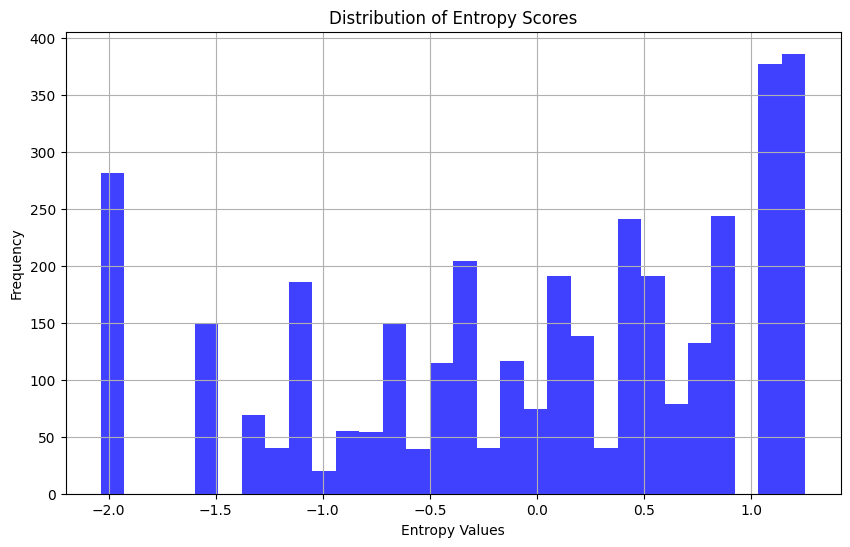

Dummy entropy: 0.5593
Dummy accuracy: 0.6166


In [71]:
# Data extraction and preprocessing.
d2_entropy = torch.tensor(d2_measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)
d2_tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in d2_generations.values()]).squeeze(-2).to(torch.float32)
d2_ca_entropy = d2_entropy.to(torch.float32)
mean = d2_ca_entropy.mean()
std = d2_ca_entropy.std()
d2_ca_entropy = (d2_ca_entropy - mean) / std

d2_tok_bef_gen_layered_datasets = d2_tok_bef_gen_dataset.transpose(0, 1)
plot_entropy_distribution(d2_ca_entropy)
d2_bca_entropy = binarize_entropy(d2_ca_entropy, 0.0)
print(f"Dummy entropy: {sum(d2_bca_entropy)/len(d2_bca_entropy):.4f}")

d2_sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in d2_generations.values()]).squeeze(-2).to(torch.float32)
d2_slt_layered_datasets = d2_sec_last_tok_dataset.transpose(0, 1)[1:]
d2_accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in d2_generations.values()])
print(f"Dummy accuracy: {max(torch.mean(d2_accuracies), 1-torch.mean(d2_accuracies)):.4f}")

### Test on Models Pretrained on D1

#### TBG Tokens

In [74]:
# Prepare test sets from D2.
total_size = d2_r_accuracies.shape[0]
d2_r_accuracies = 1 - d2_accuracies
_, _, d2b_X_tests, _, _, d2b_y_tests = create_Xs_and_ys(d2_tok_bef_gen_layered_datasets, d2_bca_entropy, total_size)
_, _, d2a_X_tests, _, _, d2a_y_tests = create_Xs_and_ys(d2_tok_bef_gen_layered_datasets, d2_r_accuracies, total_size)

In [75]:
# Test trained LRs from D1 on D2.
# Test on binary SE first.
tlr2b_test_accs = []
tlr2b_test_aucs = []

for i, (X_test, y_test) in enumerate(zip(d2b_X_tests, d2b_y_tests)):
    _, test_acc, test_auc = sklearn_evaluate_on_test(tablr_trained_models[i], X_test, y_test, binary_cls=True)
    tlr2b_test_accs.append(test_acc)
    tlr2b_test_aucs.append(test_auc)

Test Loss: 0.7250, Test Accuracy: 0.5180, AUROC: 0.5468
Test Loss: 0.7371, Test Accuracy: 0.5429, AUROC: 0.5659
Test Loss: 0.7590, Test Accuracy: 0.5402, AUROC: 0.5647
Test Loss: 0.7919, Test Accuracy: 0.5291, AUROC: 0.5722
Test Loss: 0.8580, Test Accuracy: 0.5235, AUROC: 0.5232
Test Loss: 0.8549, Test Accuracy: 0.5429, AUROC: 0.5809
Test Loss: 0.9716, Test Accuracy: 0.5457, AUROC: 0.5602
Test Loss: 1.0245, Test Accuracy: 0.5429, AUROC: 0.5555
Test Loss: 1.0796, Test Accuracy: 0.5291, AUROC: 0.5758
Test Loss: 1.1226, Test Accuracy: 0.5873, AUROC: 0.5966
Test Loss: 1.1448, Test Accuracy: 0.5845, AUROC: 0.6184
Test Loss: 1.2009, Test Accuracy: 0.6066, AUROC: 0.6379
Test Loss: 0.9585, Test Accuracy: 0.6482, AUROC: 0.7089
Test Loss: 1.0512, Test Accuracy: 0.6620, AUROC: 0.6968
Test Loss: 1.0304, Test Accuracy: 0.6343, AUROC: 0.7008
Test Loss: 0.9458, Test Accuracy: 0.6870, AUROC: 0.7308
Test Loss: 1.1570, Test Accuracy: 0.6343, AUROC: 0.6830
Test Loss: 1.3240, Test Accuracy: 0.6039, AUROC:

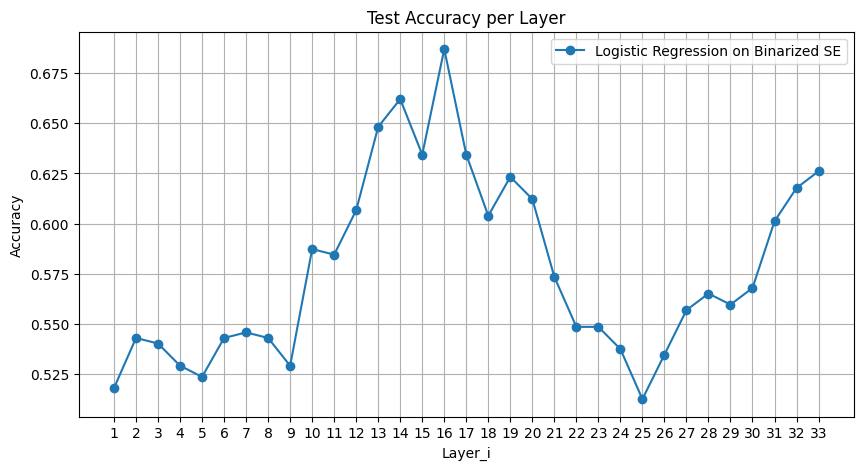

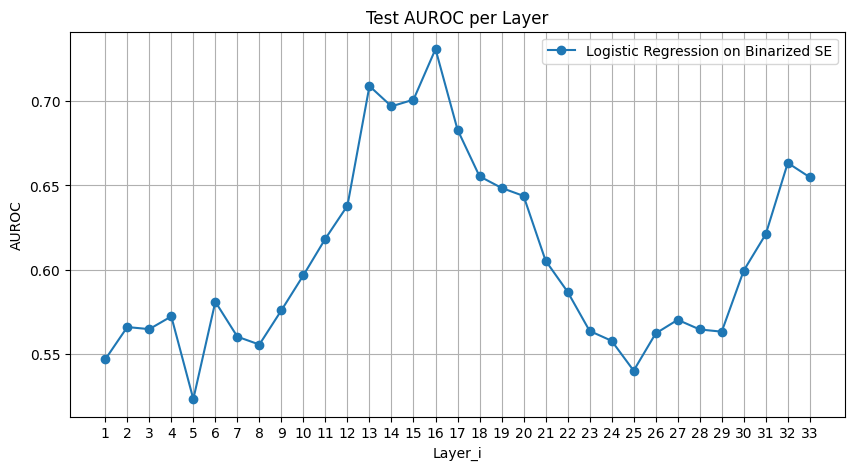

In [76]:
plot_1d_metrics([tlr2b_test_accs], ['Logistic Regression on Binarized SE'], 'Accuracy')
plot_1d_metrics([tlr2b_test_aucs], ['Logistic Regression on Binarized SE'], 'AUROC')

Test Loss: 0.7578, Test Accuracy: 0.4377, AUROC: 0.4811
Test Loss: 0.7817, Test Accuracy: 0.4515, AUROC: 0.5023
Test Loss: 0.8145, Test Accuracy: 0.4875, AUROC: 0.5114
Test Loss: 0.8676, Test Accuracy: 0.4598, AUROC: 0.5004
Test Loss: 0.8876, Test Accuracy: 0.4654, AUROC: 0.5065
Test Loss: 0.9413, Test Accuracy: 0.4681, AUROC: 0.5111
Test Loss: 1.0279, Test Accuracy: 0.4931, AUROC: 0.5395
Test Loss: 1.0889, Test Accuracy: 0.5069, AUROC: 0.5306
Test Loss: 1.1121, Test Accuracy: 0.5374, AUROC: 0.5634
Test Loss: 1.1646, Test Accuracy: 0.5789, AUROC: 0.5909
Test Loss: 1.2194, Test Accuracy: 0.5873, AUROC: 0.6111
Test Loss: 1.2841, Test Accuracy: 0.6094, AUROC: 0.6316
Test Loss: 1.2024, Test Accuracy: 0.6288, AUROC: 0.6388
Test Loss: 1.2787, Test Accuracy: 0.5983, AUROC: 0.6349
Test Loss: 1.2714, Test Accuracy: 0.5873, AUROC: 0.6251
Test Loss: 1.3077, Test Accuracy: 0.6122, AUROC: 0.6195
Test Loss: 1.4607, Test Accuracy: 0.5651, AUROC: 0.5896
Test Loss: 1.5367, Test Accuracy: 0.5900, AUROC:

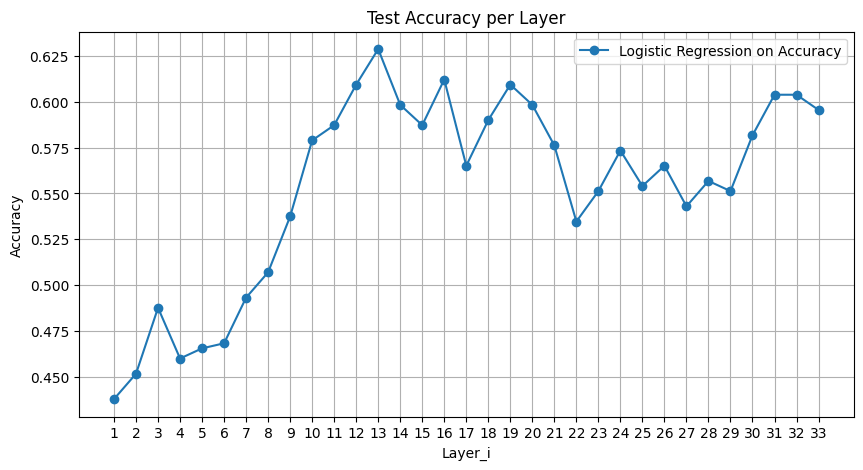

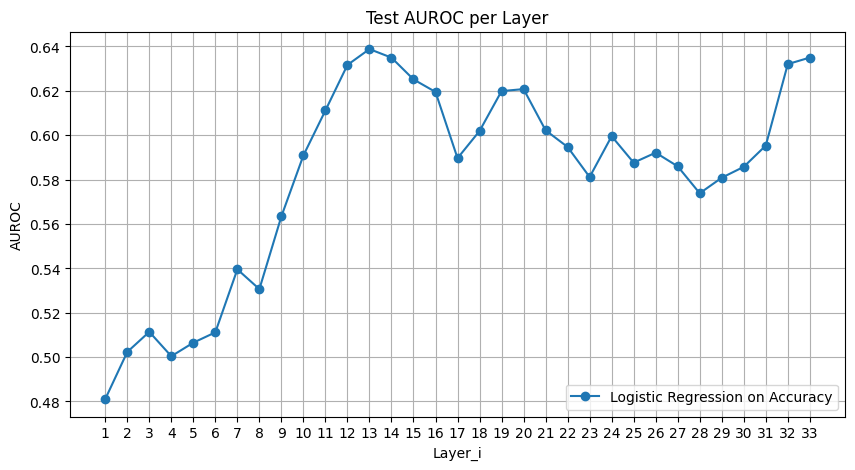

In [77]:
# Then test on accuracy scores
tlr2a_test_accs = []
tlr2a_test_aucs = []

for i, (X_test, y_test) in enumerate(zip(d2a_X_tests, d2a_y_tests)):
    _, test_acc, test_auc = sklearn_evaluate_on_test(tablr_trained_models[i], X_test, y_test, binary_cls=True)
    tlr2a_test_accs.append(test_acc)
    tlr2a_test_aucs.append(test_auc)

plot_1d_metrics([tlr2a_test_accs], ['Logistic Regression on Accuracy'], 'Accuracy')
plot_1d_metrics([tlr2a_test_aucs], ['Logistic Regression on Accuracy'], 'AUROC')

Test Loss: 58.1700, Test Accuracy: 0.5450, AUROC: 0.5477
Test Loss: 56.5490, Test Accuracy: 0.6400, AUROC: 0.6939
Test Loss: 56.9419, Test Accuracy: 0.6250, AUROC: 0.6248
Test Loss: 57.1643, Test Accuracy: 0.6050, AUROC: 0.6396
Test Loss: 57.4398, Test Accuracy: 0.5800, AUROC: 0.6172
Test Loss: 56.9289, Test Accuracy: 0.6050, AUROC: 0.6382
Test Loss: 57.4869, Test Accuracy: 0.6000, AUROC: 0.6222
Test Loss: 56.8438, Test Accuracy: 0.6250, AUROC: 0.6807
Test Loss: 56.3257, Test Accuracy: 0.6800, AUROC: 0.7004
Test Loss: 57.0460, Test Accuracy: 0.6350, AUROC: 0.6776
Test Loss: 56.3338, Test Accuracy: 0.6700, AUROC: 0.7121
Test Loss: 56.7161, Test Accuracy: 0.6350, AUROC: 0.6944
Test Loss: 56.4507, Test Accuracy: 0.6600, AUROC: 0.6872
Test Loss: 56.7823, Test Accuracy: 0.6450, AUROC: 0.6707
Test Loss: 56.5664, Test Accuracy: 0.6450, AUROC: 0.6885
Test Loss: 56.1019, Test Accuracy: 0.6850, AUROC: 0.7369
Test Loss: 56.5487, Test Accuracy: 0.6400, AUROC: 0.6908
Test Loss: 56.7038, Test Accura

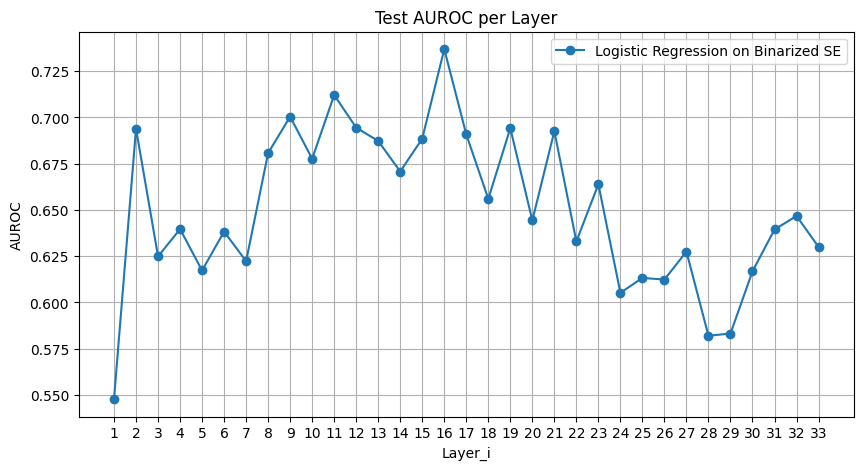

In [153]:
# Test D1-pretrained MLP on binarized SE's from D2 
tmlp2b_test_accs = []
tmlp2b_test_aucs = []

for i, test_loader in enumerate(d2b_tbg_test_dataloaders):
    test_loss, test_acc, test_auc = evaluate_on_test(tabmlp_trained_models[i], test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tmlp2b_test_accs.append(test_acc)
    tmlp2b_test_aucs.append(test_auc)

plot_1d_metrics([tmlp2b_test_aucs], ['Logistic Regression on Binarized SE'], 'AUROC')

Test Loss: 80.7681, Test Accuracy: 0.5450, AUROC: 0.5869
Test Loss: 80.2436, Test Accuracy: 0.5900, AUROC: 0.6438
Test Loss: 80.2131, Test Accuracy: 0.5950, AUROC: 0.6249
Test Loss: 80.7336, Test Accuracy: 0.5450, AUROC: 0.6303
Test Loss: 80.1394, Test Accuracy: 0.5800, AUROC: 0.6623
Test Loss: 80.0080, Test Accuracy: 0.6250, AUROC: 0.6607
Test Loss: 80.9286, Test Accuracy: 0.5200, AUROC: 0.6256
Test Loss: 80.4506, Test Accuracy: 0.5950, AUROC: 0.6379
Test Loss: 79.8831, Test Accuracy: 0.7100, AUROC: 0.6593
Test Loss: 80.2188, Test Accuracy: 0.6950, AUROC: 0.6460
Test Loss: 79.7416, Test Accuracy: 0.7400, AUROC: 0.6682
Test Loss: 79.5456, Test Accuracy: 0.7550, AUROC: 0.7166
Test Loss: 79.2741, Test Accuracy: 0.7800, AUROC: 0.7308
Test Loss: 79.3318, Test Accuracy: 0.7550, AUROC: 0.7775
Test Loss: 78.8950, Test Accuracy: 0.8050, AUROC: 0.7815
Test Loss: 78.5749, Test Accuracy: 0.8450, AUROC: 0.8187
Test Loss: 79.1018, Test Accuracy: 0.8100, AUROC: 0.6932
Test Loss: 79.0746, Test Accura

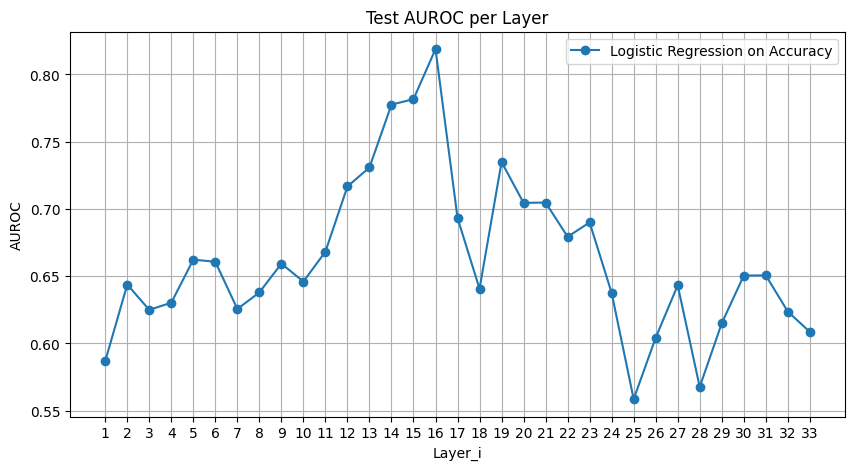

In [154]:
# Test D1-pretrained MLP on Accuracy scores from D2 
tmlp2a_test_accs = []
tmlp2a_test_aucs = []

for i, test_loader in enumerate(d2a_tbg_test_dataloaders):
    test_loss, test_acc, test_auc = evaluate_on_test(tabmlp_trained_models[i], test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tmlp2a_test_accs.append(test_acc)
    tmlp2a_test_aucs.append(test_auc)

plot_1d_metrics([tmlp2a_test_aucs], ['Logistic Regression on Accuracy'], 'AUROC')

#### SLT Tokens

In [41]:
# Prepare test sets from D2.
_, _, d2b_X_tests, _, _, d2b_y_tests = create_Xs_and_ys(d2_slt_layered_datasets, d2_bca_entropy, total_size)
_, _, d2a_X_tests, _, _, d2a_y_tests = create_Xs_and_ys(d2_slt_layered_datasets, d2_r_accuracies, total_size)

Test Loss: 0.7226, Test Accuracy: 0.4432, AUROC: 0.5807
Test Loss: 0.8452, Test Accuracy: 0.4432, AUROC: 0.5243
Test Loss: 0.9060, Test Accuracy: 0.4432, AUROC: 0.5218
Test Loss: 0.7025, Test Accuracy: 0.4765, AUROC: 0.5270
Test Loss: 0.7314, Test Accuracy: 0.4460, AUROC: 0.5509
Test Loss: 0.6849, Test Accuracy: 0.5568, AUROC: 0.5916
Test Loss: 0.7991, Test Accuracy: 0.5623, AUROC: 0.5229
Test Loss: 0.8271, Test Accuracy: 0.4848, AUROC: 0.5428
Test Loss: 1.2312, Test Accuracy: 0.4737, AUROC: 0.5481
Test Loss: 1.2906, Test Accuracy: 0.4737, AUROC: 0.5920
Test Loss: 1.0439, Test Accuracy: 0.5346, AUROC: 0.5784
Test Loss: 2.2779, Test Accuracy: 0.4432, AUROC: 0.5624
Test Loss: 0.9214, Test Accuracy: 0.5956, AUROC: 0.6220
Test Loss: 1.3688, Test Accuracy: 0.5928, AUROC: 0.5684
Test Loss: 1.5721, Test Accuracy: 0.5346, AUROC: 0.6212
Test Loss: 1.4775, Test Accuracy: 0.5540, AUROC: 0.6148
Test Loss: 1.3066, Test Accuracy: 0.6399, AUROC: 0.6660
Test Loss: 1.2637, Test Accuracy: 0.6620, AUROC:

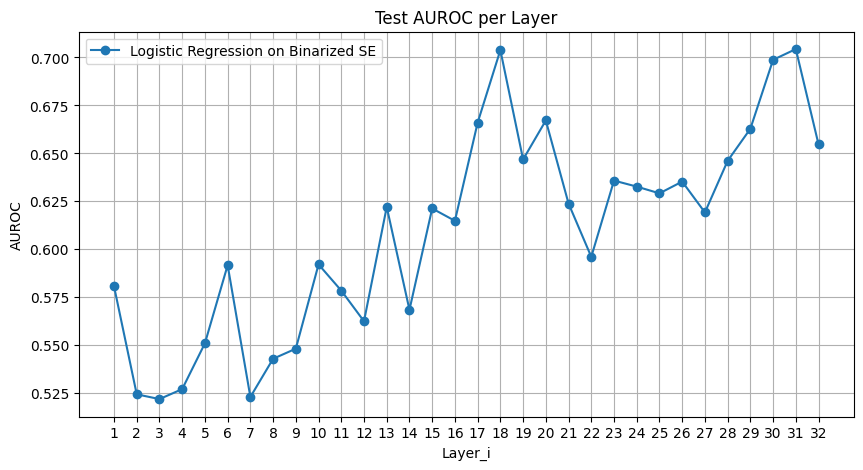

In [91]:
# Test trained LRs from D1 on D2.
# Test on binary SE first.
slr2b_test_accs = []
slr2b_test_aucs = []

for i, (X_test, y_test) in enumerate(zip(d2b_X_tests, d2b_y_tests)):
    _, test_acc, test_auc = sklearn_evaluate_on_test(sablr_trained_models[i], X_test, y_test, binary_cls=True)
    slr2b_test_accs.append(test_acc)
    slr2b_test_aucs.append(test_auc)

# plot_1d_metrics([tlr2b_test_accs], ['Logistic Regression on Binarized SE'], 'Accuracy')
plot_1d_metrics([slr2b_test_aucs], ['Logistic Regression on Binarized SE'], 'AUROC')

Test Loss: 0.7354, Test Accuracy: 0.4017, AUROC: 0.5557
Test Loss: 0.8847, Test Accuracy: 0.4017, AUROC: 0.4944
Test Loss: 0.9541, Test Accuracy: 0.4017, AUROC: 0.5075
Test Loss: 0.7080, Test Accuracy: 0.4737, AUROC: 0.5186
Test Loss: 0.7488, Test Accuracy: 0.4211, AUROC: 0.5442
Test Loss: 0.6947, Test Accuracy: 0.5374, AUROC: 0.5708
Test Loss: 0.7205, Test Accuracy: 0.5983, AUROC: 0.5809
Test Loss: 0.8412, Test Accuracy: 0.4543, AUROC: 0.5654
Test Loss: 1.3002, Test Accuracy: 0.4321, AUROC: 0.5578
Test Loss: 1.3515, Test Accuracy: 0.4377, AUROC: 0.6156
Test Loss: 0.9626, Test Accuracy: 0.5485, AUROC: 0.6373
Test Loss: 2.3485, Test Accuracy: 0.4183, AUROC: 0.6091
Test Loss: 0.8393, Test Accuracy: 0.6371, AUROC: 0.6612
Test Loss: 1.2160, Test Accuracy: 0.6066, AUROC: 0.5902
Test Loss: 1.7992, Test Accuracy: 0.5097, AUROC: 0.5714
Test Loss: 1.5611, Test Accuracy: 0.5623, AUROC: 0.6265
Test Loss: 1.4111, Test Accuracy: 0.5817, AUROC: 0.6426
Test Loss: 1.6191, Test Accuracy: 0.6150, AUROC:

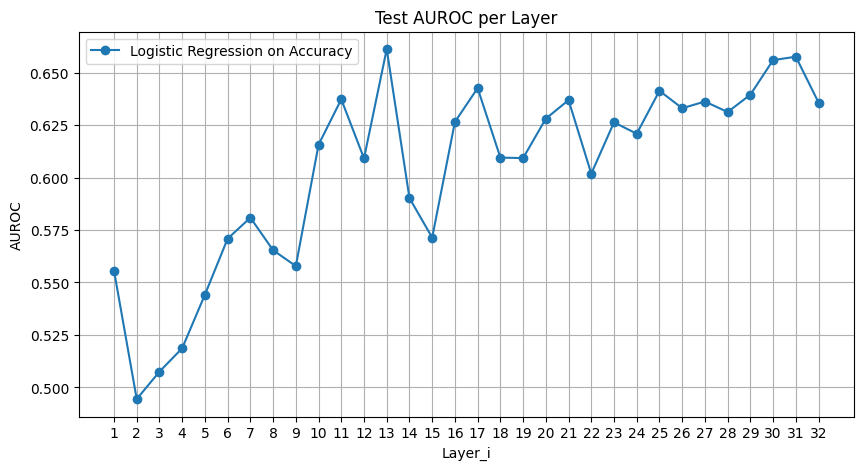

In [87]:
# Then test on accuracy scores
slr2a_test_accs = []
slr2a_test_aucs = []

for i, (X_test, y_test) in enumerate(zip(d2a_X_tests, d2a_y_tests)):
    _, test_acc, test_auc = sklearn_evaluate_on_test(sablr_trained_models[i], X_test, y_test, binary_cls=True)
    slr2a_test_accs.append(test_acc)
    slr2a_test_aucs.append(test_auc)

# plot_1d_metrics([tlr2a_test_accs], ['Logistic Regression on Accuracy'], 'Accuracy')
plot_1d_metrics([slr2a_test_aucs], ['Logistic Regression on Accuracy'], 'AUROC')

Test Loss: 57.4523, Test Accuracy: 0.5200, AUROC: 0.5868
Test Loss: 58.2039, Test Accuracy: 0.4650, AUROC: 0.5196
Test Loss: 57.5697, Test Accuracy: 0.5500, AUROC: 0.4750
Test Loss: 57.7188, Test Accuracy: 0.5600, AUROC: 0.5483
Test Loss: 57.8278, Test Accuracy: 0.5750, AUROC: 0.5752
Test Loss: 57.6557, Test Accuracy: 0.4900, AUROC: 0.5807
Test Loss: 57.3467, Test Accuracy: 0.6050, AUROC: 0.6361
Test Loss: 56.8067, Test Accuracy: 0.6200, AUROC: 0.6078
Test Loss: 57.1323, Test Accuracy: 0.6100, AUROC: 0.6791
Test Loss: 55.8607, Test Accuracy: 0.6950, AUROC: 0.7147
Test Loss: 57.2105, Test Accuracy: 0.6000, AUROC: 0.6678
Test Loss: 56.2518, Test Accuracy: 0.6500, AUROC: 0.7470
Test Loss: 56.4464, Test Accuracy: 0.6750, AUROC: 0.6844
Test Loss: 56.4989, Test Accuracy: 0.6300, AUROC: 0.7275
Test Loss: 56.1495, Test Accuracy: 0.6800, AUROC: 0.7420
Test Loss: 56.3740, Test Accuracy: 0.6400, AUROC: 0.7996
Test Loss: 56.2197, Test Accuracy: 0.6550, AUROC: 0.7728
Test Loss: 56.1084, Test Accura

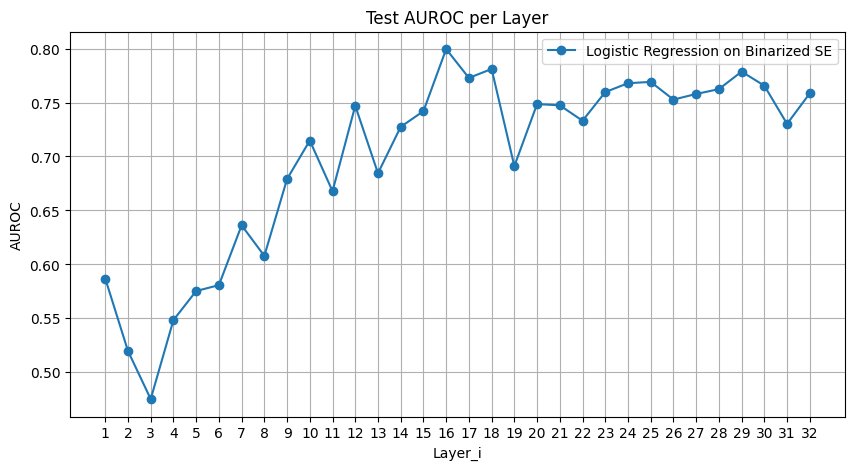

In [158]:
# Test D1-pretrained MLP on binarized SE's from D2 
smlp2b_test_accs = []
smlp2b_test_aucs = []

for i, test_loader in enumerate(d2b_slt_test_dataloaders):
    test_loss, test_acc, test_auc = evaluate_on_test(sabmlp_trained_models[i], test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    smlp2b_test_accs.append(test_acc)
    smlp2b_test_aucs.append(test_auc)

plot_1d_metrics([smlp2b_test_aucs], ['Logistic Regression on Binarized SE'], 'AUROC')

Test Loss: 80.6177, Test Accuracy: 0.3400, AUROC: 0.5336
Test Loss: 81.0133, Test Accuracy: 0.3350, AUROC: 0.5513
Test Loss: 79.7453, Test Accuracy: 0.7600, AUROC: 0.5007
Test Loss: 80.0783, Test Accuracy: 0.7100, AUROC: 0.5525
Test Loss: 80.7222, Test Accuracy: 0.5850, AUROC: 0.6154
Test Loss: 80.8976, Test Accuracy: 0.3000, AUROC: 0.5773
Test Loss: 81.0568, Test Accuracy: 0.5650, AUROC: 0.5746
Test Loss: 79.7220, Test Accuracy: 0.7600, AUROC: 0.5980
Test Loss: 81.3812, Test Accuracy: 0.4700, AUROC: 0.5754
Test Loss: 79.3323, Test Accuracy: 0.7650, AUROC: 0.6962
Test Loss: 80.9153, Test Accuracy: 0.5500, AUROC: 0.6429
Test Loss: 79.2330, Test Accuracy: 0.7800, AUROC: 0.6974
Test Loss: 79.5736, Test Accuracy: 0.7450, AUROC: 0.7194
Test Loss: 79.1011, Test Accuracy: 0.8100, AUROC: 0.6942
Test Loss: 79.3272, Test Accuracy: 0.7900, AUROC: 0.7341
Test Loss: 78.7629, Test Accuracy: 0.8400, AUROC: 0.7888
Test Loss: 78.9850, Test Accuracy: 0.8150, AUROC: 0.7883
Test Loss: 79.1149, Test Accura

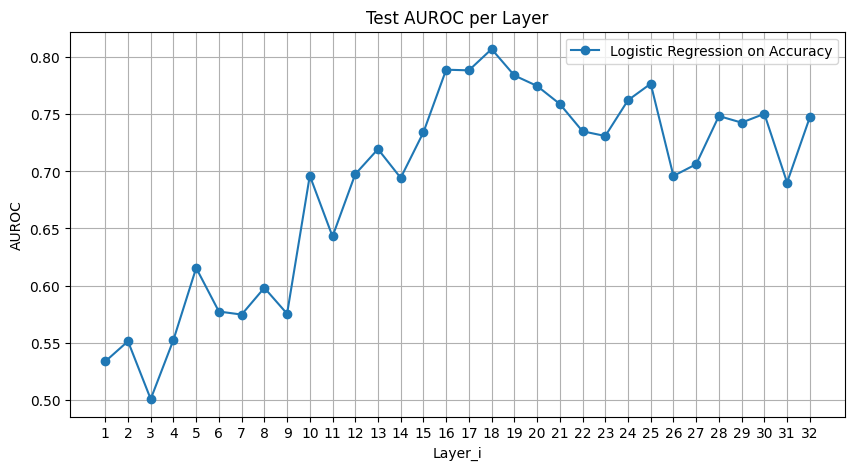

In [159]:
# Test D1-pretrained MLP on Accuracy scores from D2 
smlp2a_test_accs = []
smlp2a_test_aucs = []

for i, test_loader in enumerate(d2a_slt_test_dataloaders):
    test_loss, test_acc, test_auc = evaluate_on_test(sabmlp_trained_models[i], test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    smlp2a_test_accs.append(test_acc)
    smlp2a_test_aucs.append(test_auc)

plot_1d_metrics([smlp2a_test_aucs], ['Logistic Regression on Accuracy'], 'AUROC')

### Train Accuracy / SE Classifiers from Scratch on D2

#### TBG Tokens

In [78]:
# Prepare all data sets from D2.
d2a_tbg_train_dataloaders, d2a_tbg_valid_dataloaders, d2a_tbg_test_dataloaders = create_dataloaders(d2_tok_bef_gen_layered_datasets, d2_r_accuracies, total_size, batch_size, set_seed=True)
d2b_tbg_train_dataloaders, d2b_tbg_valid_dataloaders, d2b_tbg_test_dataloaders = create_dataloaders(d2_tok_bef_gen_layered_datasets, d2_bca_entropy, total_size, batch_size, set_seed=True)

d2a_X_trains, d2a_X_vals, d2a_X_tests, d2a_y_trains, d2a_y_vals, d2a_y_tests = create_Xs_and_ys(d2_tok_bef_gen_layered_datasets, d2_r_accuracies, total_size)
d2b_X_trains, d2b_X_vals, d2b_X_tests, d2b_y_trains, d2b_y_vals, d2b_y_tests = create_Xs_and_ys(d2_tok_bef_gen_layered_datasets, d2_bca_entropy, total_size)

Training on D2 TBG Dataset 1/33
Validation Accuracy: 0.6215, AUROC: 0.6270
Training Loss: 0.5930, Validation Loss: 0.6458
Test Loss: 0.6659, Test Accuracy: 0.5983, AUROC: 0.5685
Training on D2 TBG Dataset 2/33
Validation Accuracy: 0.6246, AUROC: 0.6404
Training Loss: 0.5603, Validation Loss: 0.6403
Test Loss: 0.6667, Test Accuracy: 0.5762, AUROC: 0.5781
Training on D2 TBG Dataset 3/33
Validation Accuracy: 0.6323, AUROC: 0.6328
Training Loss: 0.4992, Validation Loss: 0.6495
Test Loss: 0.6935, Test Accuracy: 0.5873, AUROC: 0.5803
Training on D2 TBG Dataset 4/33
Validation Accuracy: 0.6538, AUROC: 0.6237
Training Loss: 0.4388, Validation Loss: 0.6706
Test Loss: 0.7362, Test Accuracy: 0.5457, AUROC: 0.5640
Training on D2 TBG Dataset 5/33
Validation Accuracy: 0.6400, AUROC: 0.6285
Training Loss: 0.3922, Validation Loss: 0.6944
Test Loss: 0.7791, Test Accuracy: 0.5983, AUROC: 0.5769
Training on D2 TBG Dataset 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6231, AUROC: 0.6281
Training Loss: 0.3466, Validation Loss: 0.7217
Test Loss: 0.7982, Test Accuracy: 0.5928, AUROC: 0.5856
Training on D2 TBG Dataset 7/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6200, AUROC: 0.6228
Training Loss: 0.3028, Validation Loss: 0.7751
Test Loss: 0.7953, Test Accuracy: 0.6011, AUROC: 0.6311
Training on D2 TBG Dataset 8/33


...

Validation Accuracy: 0.6292, AUROC: 0.6534
Training Loss: 0.0029, Validation Loss: 2.2476
Test Loss: 2.2449, Test Accuracy: 0.5928, AUROC: 0.6117
Training on D2 TBG Dataset 31/33
Validation Accuracy: 0.6477, AUROC: 0.6528
Training Loss: 0.0025, Validation Loss: 2.3007
Test Loss: 2.4819, Test Accuracy: 0.5845, AUROC: 0.6168
Training on D2 TBG Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6231, AUROC: 0.6492
Training Loss: 0.0023, Validation Loss: 2.3138
Test Loss: 2.6419, Test Accuracy: 0.5983, AUROC: 0.6079
Training on D2 TBG Dataset 33/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6369, AUROC: 0.6621
Training Loss: 0.0044, Validation Loss: 2.5002
Test Loss: 2.9719, Test Accuracy: 0.5596, AUROC: 0.5953


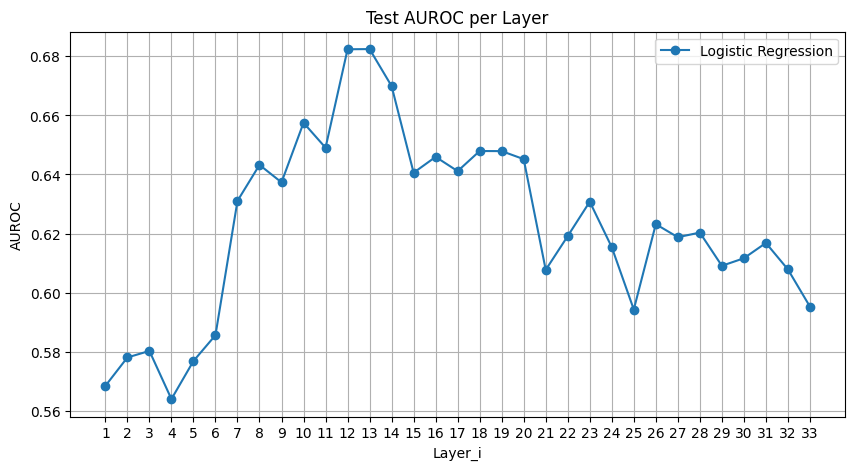

In [79]:
# Training Loops (LR)
tlra_test_accs = []
tlra_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(d2a_X_trains, d2a_X_vals, d2a_X_tests, d2a_y_trains, d2a_y_vals, d2a_y_tests)):
    print(f"Training on D2 TBG Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on D2 TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tlra_test_accs.append(test_acc)
    tlra_test_aucs.append(test_auc)

# plot_1d_metrics([tlra_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tlra_test_aucs], ['Logistic Regression'], 'AUROC')

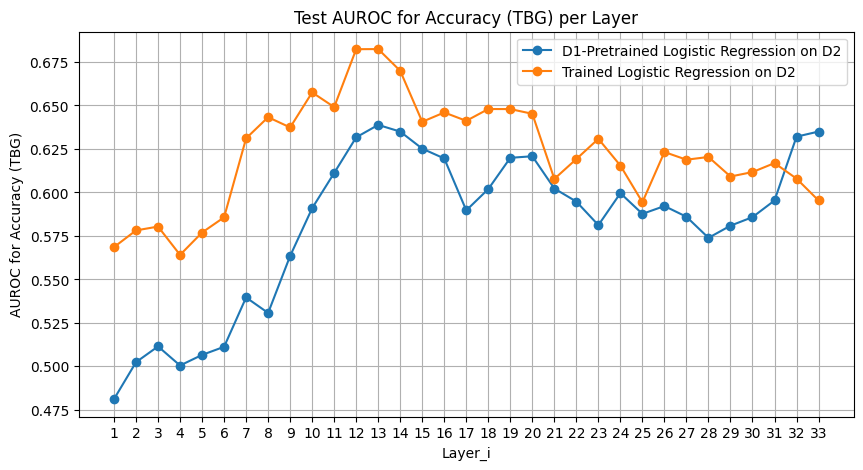

TBG: max AUROC for LR trained on D1's Binary SE, tested on D2's Accuracy: 0.6388 at 13 layer
TBG: max AUROC for LR trained on D2's Accuracy, tested on D2's Accuracy: 0.6824 at 13 layer


In [80]:
# Comparison with using pretrained model on D1 for prediction on D2
plot_1d_metrics([tlr2a_test_aucs, tlra_test_aucs], ['D1-Pretrained Logistic Regression on D2', 'Trained Logistic Regression on D2'], 'AUROC for Accuracy (TBG)')
print(f"TBG: max AUROC for LR trained on D1's Binary SE, tested on D2's Accuracy: {max(tlr2a_test_aucs):.4f} at {np.argmax(tlr2a_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on D2's Accuracy, tested on D2's Accuracy: {max(tlra_test_aucs):.4f} at {np.argmax(tlra_test_aucs)+1} layer")

Training on D2 TBG-SE Dataset 1/33
Validation Accuracy: 0.5969, AUROC: 0.6278
Training Loss: 0.6060, Validation Loss: 0.6589
Test Loss: 0.6715, Test Accuracy: 0.5789, AUROC: 0.5981
Training on D2 TBG-SE Dataset 2/33
Validation Accuracy: 0.6000, AUROC: 0.6370
Training Loss: 0.5739, Validation Loss: 0.6517
Test Loss: 0.6695, Test Accuracy: 0.5706, AUROC: 0.6056
Training on D2 TBG-SE Dataset 3/33
Validation Accuracy: 0.6000, AUROC: 0.6317
Training Loss: 0.5064, Validation Loss: 0.6608
Test Loss: 0.6886, Test Accuracy: 0.5983, AUROC: 0.6124
Training on D2 TBG-SE Dataset 4/33
Validation Accuracy: 0.5892, AUROC: 0.6212
Training Loss: 0.4383, Validation Loss: 0.6837
Test Loss: 0.7124, Test Accuracy: 0.5928, AUROC: 0.6231
Training on D2 TBG-SE Dataset 5/33
Validation Accuracy: 0.6231, AUROC: 0.6601
Training Loss: 0.3887, Validation Loss: 0.6729
Test Loss: 0.7399, Test Accuracy: 0.6205, AUROC: 0.6202
Training on D2 TBG-SE Dataset 6/33
Validation Accuracy: 0.6569, AUROC: 0.6842
Training Loss: 0.

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6400, AUROC: 0.6845
Training Loss: 0.2882, Validation Loss: 0.7297
Test Loss: 0.7670, Test Accuracy: 0.6260, AUROC: 0.6595
Training on D2 TBG-SE Dataset 8/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6600, AUROC: 0.7060
Training Loss: 0.2282, Validation Loss: 0.7619
Test Loss: 0.7782, Test Accuracy: 0.6205, AUROC: 0.6876
Training on D2 TBG-SE Dataset 9/33


...

Validation Accuracy: 0.6923, AUROC: 0.7513
Training Loss: 0.0026, Validation Loss: 1.8548
Test Loss: 1.7016, Test Accuracy: 0.7091, AUROC: 0.7669
Training on D2 TBG-SE Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6815, AUROC: 0.7555
Training Loss: 0.0022, Validation Loss: 1.9522
Test Loss: 1.8657, Test Accuracy: 0.7147, AUROC: 0.7589
Training on D2 TBG-SE Dataset 33/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6908, AUROC: 0.7472
Training Loss: 0.0040, Validation Loss: 2.1515
Test Loss: 2.2462, Test Accuracy: 0.6731, AUROC: 0.7347


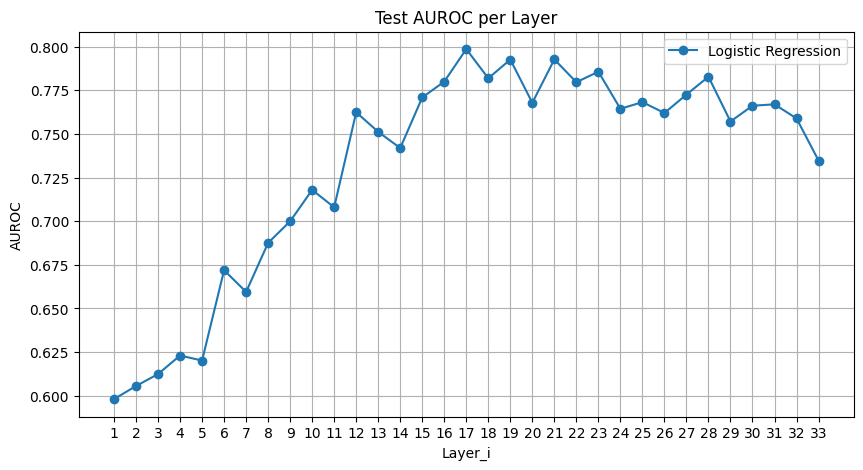

In [81]:
# Training Loops (LR)
tlrb_test_accs = []
tlrb_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(d2b_X_trains, d2b_X_vals, d2b_X_tests, d2b_y_trains, d2b_y_vals, d2b_y_tests)):
    print(f"Training on D2 TBG-SE Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on D2 TBG-SE Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tlrb_test_accs.append(test_acc)
    tlrb_test_aucs.append(test_auc)

# plot_1d_metrics([tlrb_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tlrb_test_aucs], ['Logistic Regression'], 'AUROC')

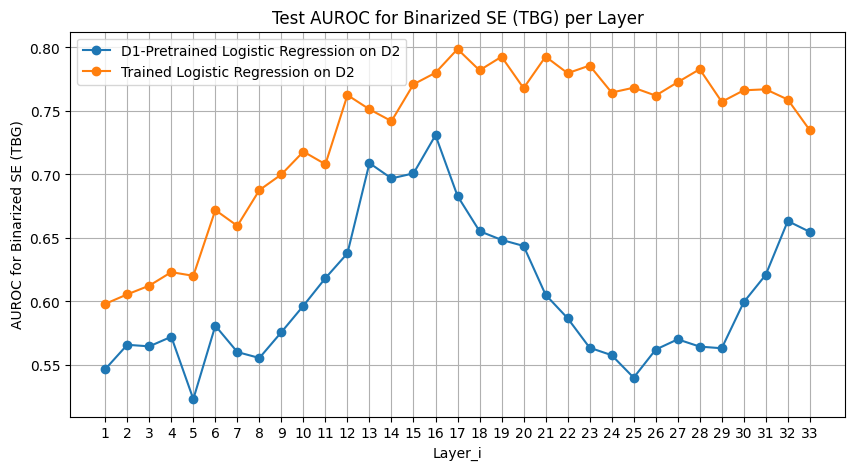

TBG: max AUROC for LR trained on D1's Binary SE, tested on D2's Binary SE: 0.7308 at 16 layer
TBG: max AUROC for LR both trained and tested on D2's Binary SE: 0.7986 at 17 layer


In [82]:
# Comparison with using pretrained model on D1 for prediction on D2 (for SE)
plot_1d_metrics([tlr2b_test_aucs, tlrb_test_aucs], ['D1-Pretrained Logistic Regression on D2', 'Trained Logistic Regression on D2'], 'AUROC for Binarized SE (TBG)')
print(f"TBG: max AUROC for LR trained on D1's Binary SE, tested on D2's Binary SE: {max(tlr2b_test_aucs):.4f} at {np.argmax(tlr2b_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR both trained and tested on D2's Binary SE: {max(tlrb_test_aucs):.4f} at {np.argmax(tlrb_test_aucs)+1} layer")

Using device: cuda
Training on D2 SLT Dataset 1/33
Epoch 1/50, Training Loss: 96.2304, Validation Loss: 94.4301, Training Accuracy: 0.7146
Epoch 10/50, Training Loss: 95.0924, Validation Loss: 94.6666, Training Accuracy: 0.9021
Epoch 20/50, Training Loss: 95.0331, Validation Loss: 94.7289, Training Accuracy: 0.9028
Epoch 30/50, Training Loss: 95.0336, Validation Loss: 94.6873, Training Accuracy: 0.9069
Epoch 40/50, Training Loss: 95.0298, Validation Loss: 94.7252, Training Accuracy: 0.9090
Epoch 50/50, Training Loss: 95.0272, Validation Loss: 94.7410, Training Accuracy: 0.9049


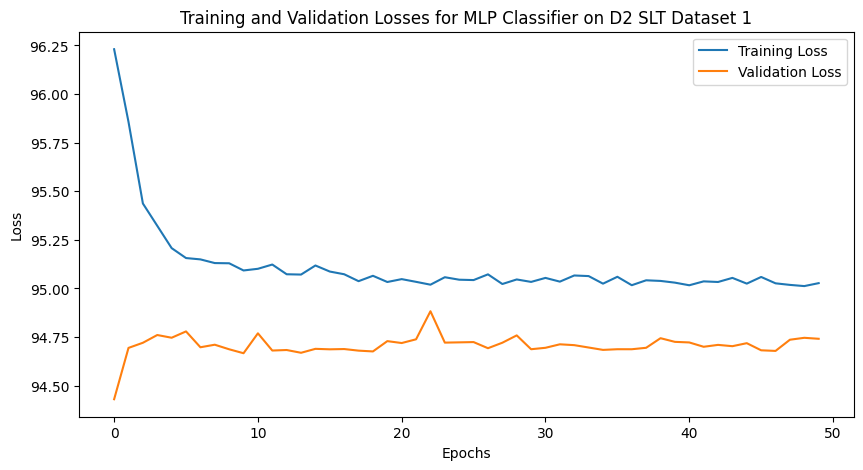

Test Loss: 79.3712, Test Accuracy: 0.7900, AUROC: 0.5080
Training on D2 SLT Dataset 2/33
Epoch 1/50, Training Loss: 96.1921, Validation Loss: 94.4101, Training Accuracy: 0.6361
Epoch 10/50, Training Loss: 95.1036, Validation Loss: 94.8356, Training Accuracy: 0.8993
Epoch 20/50, Training Loss: 95.0698, Validation Loss: 94.7922, Training Accuracy: 0.9062
Epoch 30/50, Training Loss: 95.0111, Validation Loss: 94.8548, Training Accuracy: 0.9083
Epoch 40/50, Training Loss: 95.0284, Validation Loss: 94.8320, Training Accuracy: 0.9042
Epoch 50/50, Training Loss: 94.9605, Validation Loss: 94.8114, Training Accuracy: 0.9111


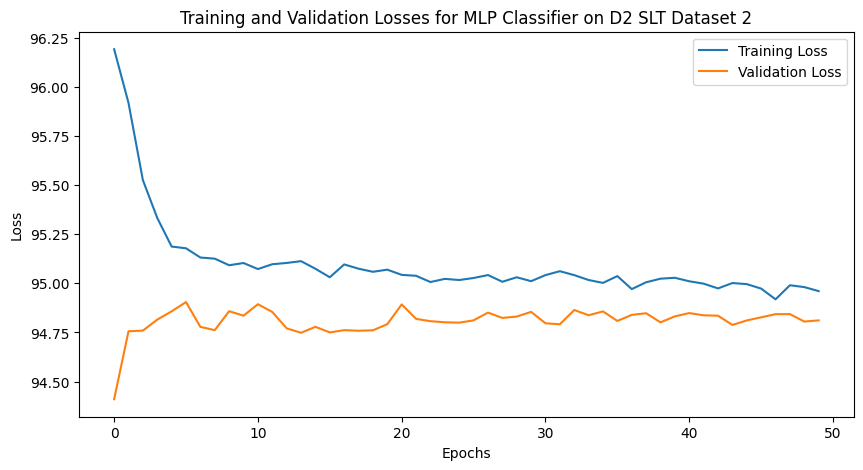

Test Loss: 79.4359, Test Accuracy: 0.7800, AUROC: 0.5499
Training on D2 SLT Dataset 3/33
Epoch 1/50, Training Loss: 96.2290, Validation Loss: 94.5242, Training Accuracy: 0.5215
Epoch 10/50, Training Loss: 95.0552, Validation Loss: 95.0114, Training Accuracy: 0.9035
Epoch 20/50, Training Loss: 94.9091, Validation Loss: 94.8668, Training Accuracy: 0.9111
Epoch 30/50, Training Loss: 94.7955, Validation Loss: 94.9198, Training Accuracy: 0.9215
Epoch 40/50, Training Loss: 94.8074, Validation Loss: 94.7941, Training Accuracy: 0.9174
Epoch 50/50, Training Loss: 94.7697, Validation Loss: 94.7514, Training Accuracy: 0.9201


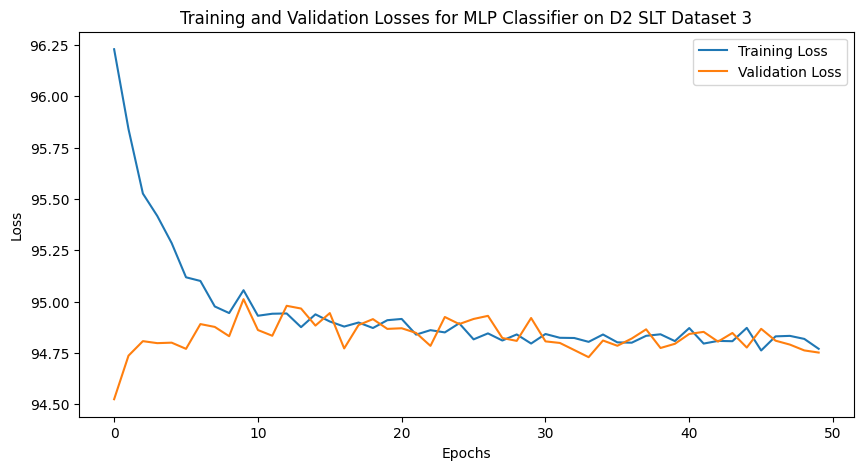

Test Loss: 79.6801, Test Accuracy: 0.7700, AUROC: 0.5734
Training on D2 SLT Dataset 4/33
Epoch 1/50, Training Loss: 96.1998, Validation Loss: 94.6159, Training Accuracy: 0.5132
Epoch 10/50, Training Loss: 94.8503, Validation Loss: 94.8222, Training Accuracy: 0.9174
Epoch 20/50, Training Loss: 94.7568, Validation Loss: 94.7908, Training Accuracy: 0.9187
Epoch 30/50, Training Loss: 94.6858, Validation Loss: 94.7815, Training Accuracy: 0.9278
Epoch 40/50, Training Loss: 94.7159, Validation Loss: 94.8648, Training Accuracy: 0.9229
Epoch 50/50, Training Loss: 94.6518, Validation Loss: 94.8457, Training Accuracy: 0.9250


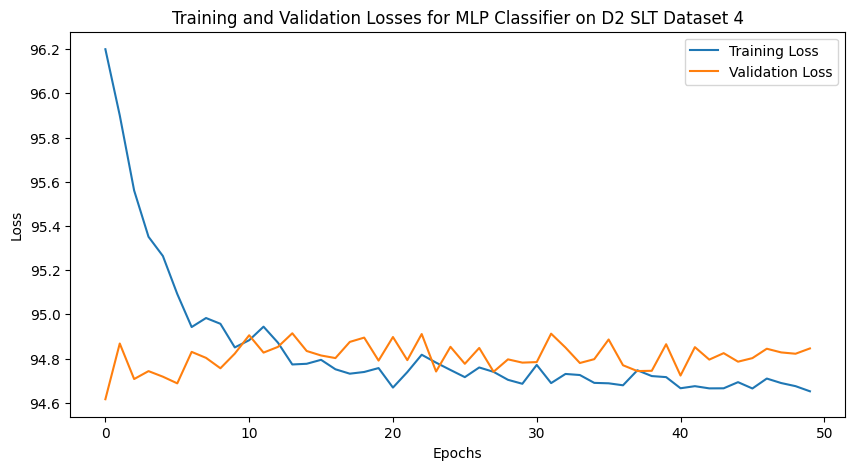

Test Loss: 79.5860, Test Accuracy: 0.7750, AUROC: 0.5539
Training on D2 SLT Dataset 5/33
Epoch 1/50, Training Loss: 96.2726, Validation Loss: 94.6676, Training Accuracy: 0.5208
Epoch 10/50, Training Loss: 94.8357, Validation Loss: 94.7963, Training Accuracy: 0.9229
Epoch 20/50, Training Loss: 94.7260, Validation Loss: 94.8805, Training Accuracy: 0.9264
Epoch 30/50, Training Loss: 94.6990, Validation Loss: 94.8190, Training Accuracy: 0.9257
Epoch 40/50, Training Loss: 94.6589, Validation Loss: 94.8152, Training Accuracy: 0.9306
Epoch 50/50, Training Loss: 94.6520, Validation Loss: 95.0018, Training Accuracy: 0.9257


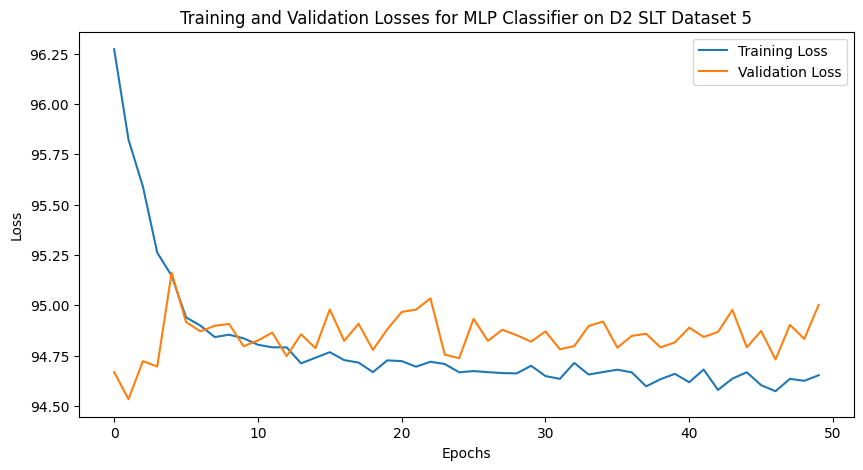

Test Loss: 80.0836, Test Accuracy: 0.7350, AUROC: 0.5097
Training on D2 SLT Dataset 6/33
Epoch 1/50, Training Loss: 96.2368, Validation Loss: 94.8772, Training Accuracy: 0.6736
Epoch 10/50, Training Loss: 94.7697, Validation Loss: 95.0110, Training Accuracy: 0.9208
Epoch 20/50, Training Loss: 94.7012, Validation Loss: 94.8495, Training Accuracy: 0.9257
Epoch 30/50, Training Loss: 94.5842, Validation Loss: 94.9521, Training Accuracy: 0.9326
Epoch 40/50, Training Loss: 94.6067, Validation Loss: 94.9212, Training Accuracy: 0.9278
Epoch 50/50, Training Loss: 94.5656, Validation Loss: 94.9322, Training Accuracy: 0.9319


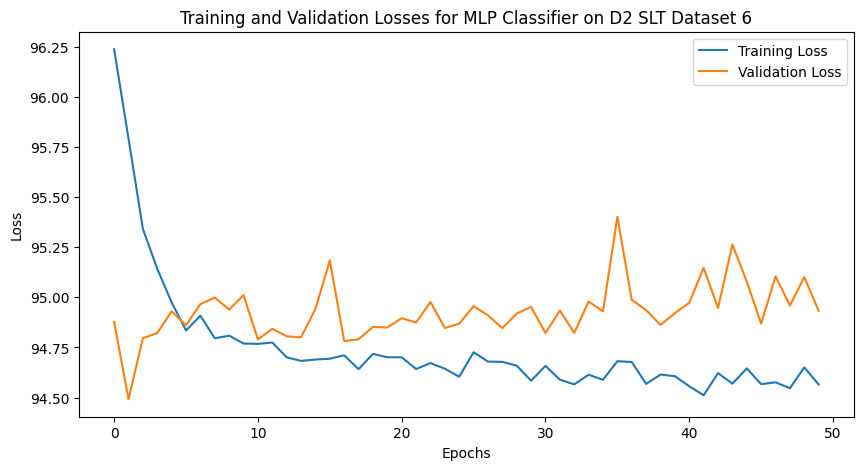

Test Loss: 79.8453, Test Accuracy: 0.7600, AUROC: 0.4836
Training on D2 SLT Dataset 7/33
Epoch 1/50, Training Loss: 96.1455, Validation Loss: 94.3752, Training Accuracy: 0.4306
Epoch 10/50, Training Loss: 94.6817, Validation Loss: 95.0381, Training Accuracy: 0.9222
Epoch 20/50, Training Loss: 94.5616, Validation Loss: 94.8202, Training Accuracy: 0.9264
Epoch 30/50, Training Loss: 94.4768, Validation Loss: 94.8273, Training Accuracy: 0.9361
Epoch 40/50, Training Loss: 94.4473, Validation Loss: 94.8707, Training Accuracy: 0.9389
Epoch 50/50, Training Loss: 94.3489, Validation Loss: 95.0859, Training Accuracy: 0.9424


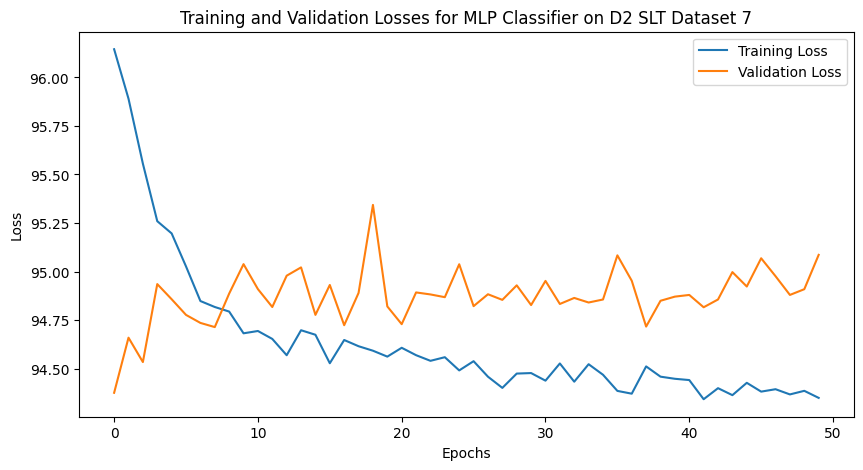

Test Loss: 79.9249, Test Accuracy: 0.7250, AUROC: 0.5608
Training on D2 SLT Dataset 8/33
Epoch 1/50, Training Loss: 96.2447, Validation Loss: 94.4586, Training Accuracy: 0.4160
Epoch 10/50, Training Loss: 94.5620, Validation Loss: 94.8152, Training Accuracy: 0.9257
Epoch 20/50, Training Loss: 94.4936, Validation Loss: 94.8686, Training Accuracy: 0.9264
Epoch 30/50, Training Loss: 94.2599, Validation Loss: 94.9853, Training Accuracy: 0.9458
Epoch 40/50, Training Loss: 94.2148, Validation Loss: 94.8511, Training Accuracy: 0.9479
Epoch 50/50, Training Loss: 94.2252, Validation Loss: 94.9692, Training Accuracy: 0.9486


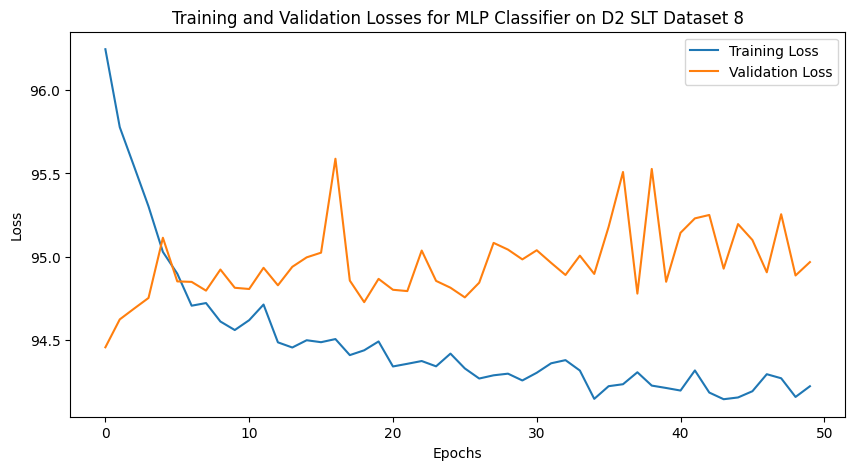

Test Loss: 79.9199, Test Accuracy: 0.7400, AUROC: 0.5967
Training on D2 SLT Dataset 9/33
Epoch 1/50, Training Loss: 96.2278, Validation Loss: 94.4357, Training Accuracy: 0.3736
Epoch 10/50, Training Loss: 94.6015, Validation Loss: 94.8102, Training Accuracy: 0.9250
Epoch 20/50, Training Loss: 94.4145, Validation Loss: 95.0616, Training Accuracy: 0.9361
Epoch 30/50, Training Loss: 94.3120, Validation Loss: 94.9507, Training Accuracy: 0.9389
Epoch 40/50, Training Loss: 94.1418, Validation Loss: 95.1809, Training Accuracy: 0.9493
Epoch 50/50, Training Loss: 94.0670, Validation Loss: 95.2100, Training Accuracy: 0.9563


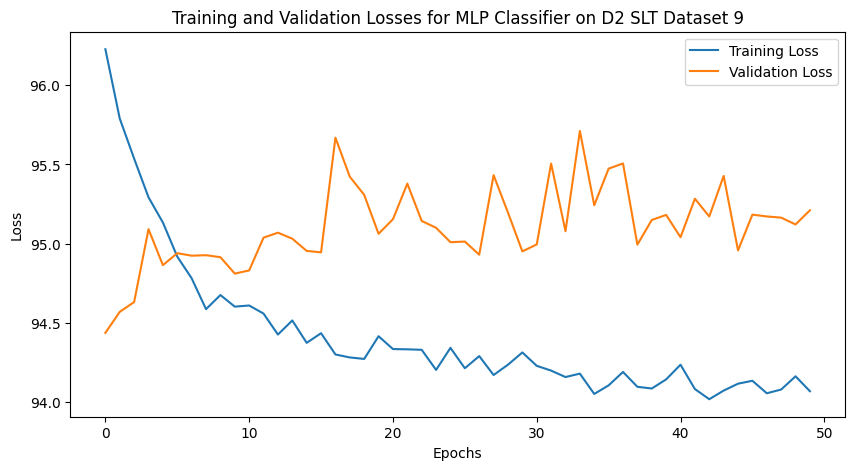

Test Loss: 79.5923, Test Accuracy: 0.7750, AUROC: 0.5811
Training on D2 SLT Dataset 10/33
Epoch 1/50, Training Loss: 96.3221, Validation Loss: 94.7862, Training Accuracy: 0.5604
Epoch 10/50, Training Loss: 94.3824, Validation Loss: 94.8353, Training Accuracy: 0.9354
Epoch 20/50, Training Loss: 94.1989, Validation Loss: 94.8358, Training Accuracy: 0.9479
Epoch 30/50, Training Loss: 94.1914, Validation Loss: 95.0753, Training Accuracy: 0.9451
Epoch 40/50, Training Loss: 94.0864, Validation Loss: 94.9876, Training Accuracy: 0.9569
Epoch 50/50, Training Loss: 94.0707, Validation Loss: 95.0986, Training Accuracy: 0.9528


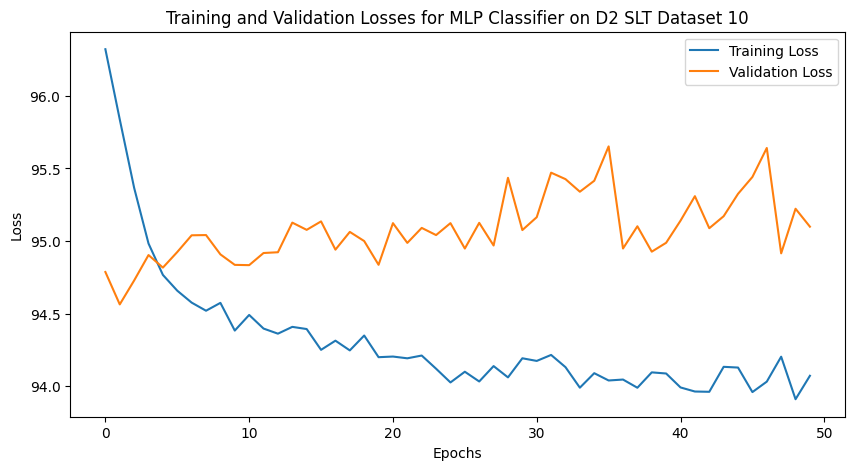

Test Loss: 80.4389, Test Accuracy: 0.6850, AUROC: 0.5726
Training on D2 SLT Dataset 11/33
Epoch 1/50, Training Loss: 96.1368, Validation Loss: 94.5148, Training Accuracy: 0.4056
Epoch 10/50, Training Loss: 94.3011, Validation Loss: 95.0924, Training Accuracy: 0.9382
Epoch 20/50, Training Loss: 94.1047, Validation Loss: 95.0763, Training Accuracy: 0.9542
Epoch 30/50, Training Loss: 93.9452, Validation Loss: 95.1309, Training Accuracy: 0.9632
Epoch 40/50, Training Loss: 93.8164, Validation Loss: 95.3091, Training Accuracy: 0.9729
Epoch 50/50, Training Loss: 93.7942, Validation Loss: 95.4229, Training Accuracy: 0.9785


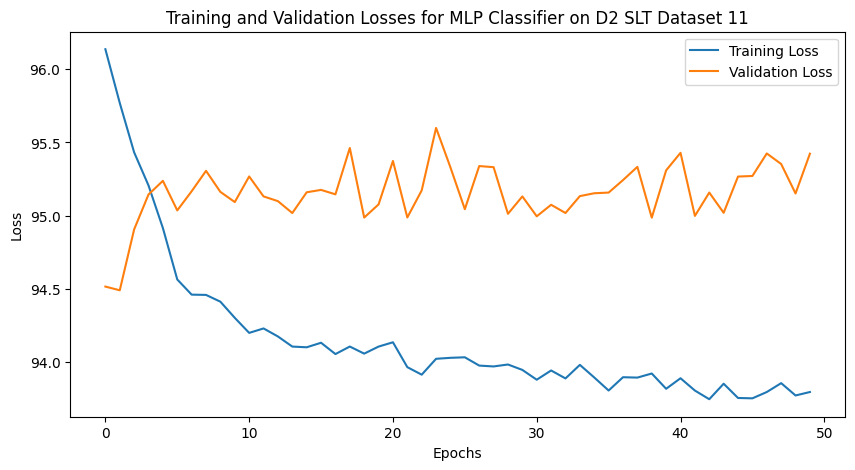

Test Loss: 79.6993, Test Accuracy: 0.7600, AUROC: 0.6562
Training on D2 SLT Dataset 12/33
Epoch 1/50, Training Loss: 96.1637, Validation Loss: 94.5229, Training Accuracy: 0.5840
Epoch 10/50, Training Loss: 94.2760, Validation Loss: 95.3363, Training Accuracy: 0.9479
Epoch 20/50, Training Loss: 93.9472, Validation Loss: 94.7554, Training Accuracy: 0.9653
Epoch 30/50, Training Loss: 93.7833, Validation Loss: 95.0085, Training Accuracy: 0.9757
Epoch 40/50, Training Loss: 93.7997, Validation Loss: 94.9185, Training Accuracy: 0.9778
Epoch 50/50, Training Loss: 93.6921, Validation Loss: 94.7495, Training Accuracy: 0.9854


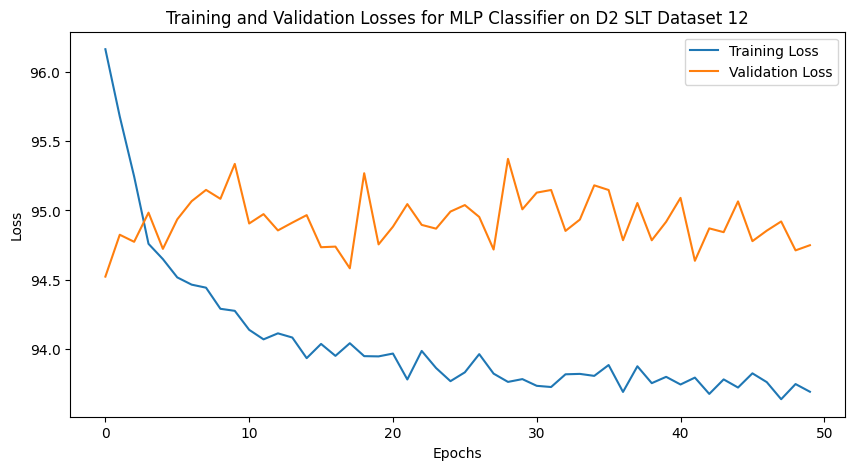

Test Loss: 79.5467, Test Accuracy: 0.7700, AUROC: 0.6170
Training on D2 SLT Dataset 13/33
Epoch 1/50, Training Loss: 96.1253, Validation Loss: 94.4741, Training Accuracy: 0.6354
Epoch 10/50, Training Loss: 94.1375, Validation Loss: 94.8771, Training Accuracy: 0.9479
Epoch 20/50, Training Loss: 93.8231, Validation Loss: 94.8824, Training Accuracy: 0.9778
Epoch 30/50, Training Loss: 93.8522, Validation Loss: 94.6973, Training Accuracy: 0.9736
Epoch 40/50, Training Loss: 93.7647, Validation Loss: 95.0690, Training Accuracy: 0.9792
Epoch 50/50, Training Loss: 93.6946, Validation Loss: 94.7515, Training Accuracy: 0.9840


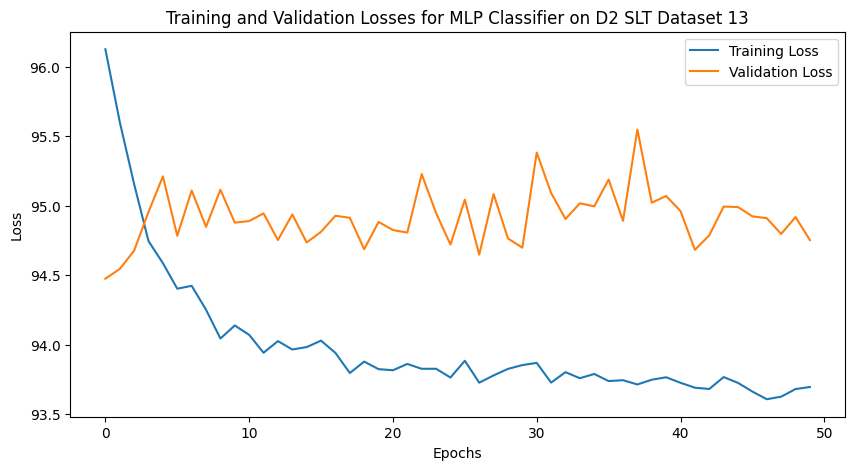

Test Loss: 79.5898, Test Accuracy: 0.7700, AUROC: 0.6847
Training on D2 SLT Dataset 14/33
Epoch 1/50, Training Loss: 96.1059, Validation Loss: 94.7091, Training Accuracy: 0.6854
Epoch 10/50, Training Loss: 93.9093, Validation Loss: 95.0478, Training Accuracy: 0.9701
Epoch 20/50, Training Loss: 93.7481, Validation Loss: 94.7445, Training Accuracy: 0.9792
Epoch 30/50, Training Loss: 93.6854, Validation Loss: 95.0803, Training Accuracy: 0.9840
Epoch 40/50, Training Loss: 93.6877, Validation Loss: 94.6944, Training Accuracy: 0.9833
Epoch 50/50, Training Loss: 93.7091, Validation Loss: 94.7202, Training Accuracy: 0.9833


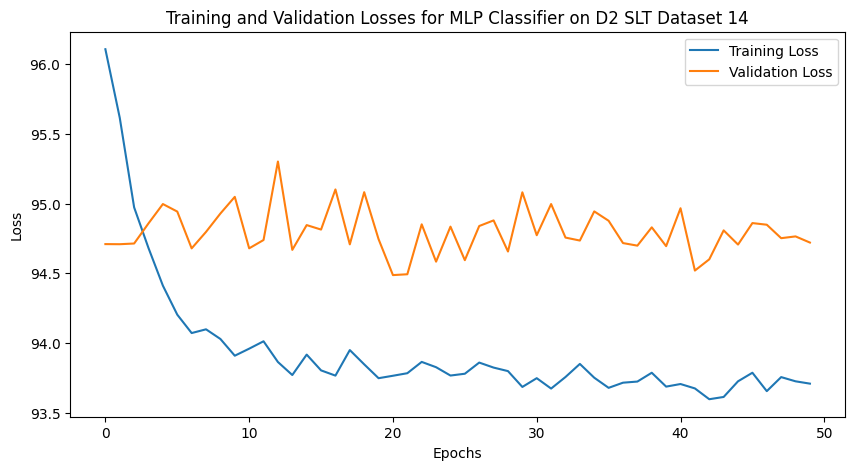

Test Loss: 79.5474, Test Accuracy: 0.7600, AUROC: 0.6447
Training on D2 SLT Dataset 15/33
Epoch 1/50, Training Loss: 96.1422, Validation Loss: 94.4299, Training Accuracy: 0.6125
Epoch 10/50, Training Loss: 94.0838, Validation Loss: 94.7683, Training Accuracy: 0.9632
Epoch 20/50, Training Loss: 93.7776, Validation Loss: 94.6323, Training Accuracy: 0.9785
Epoch 30/50, Training Loss: 93.7670, Validation Loss: 94.9578, Training Accuracy: 0.9792
Epoch 40/50, Training Loss: 93.6395, Validation Loss: 94.7557, Training Accuracy: 0.9861
Epoch 50/50, Training Loss: 93.6834, Validation Loss: 94.7054, Training Accuracy: 0.9840


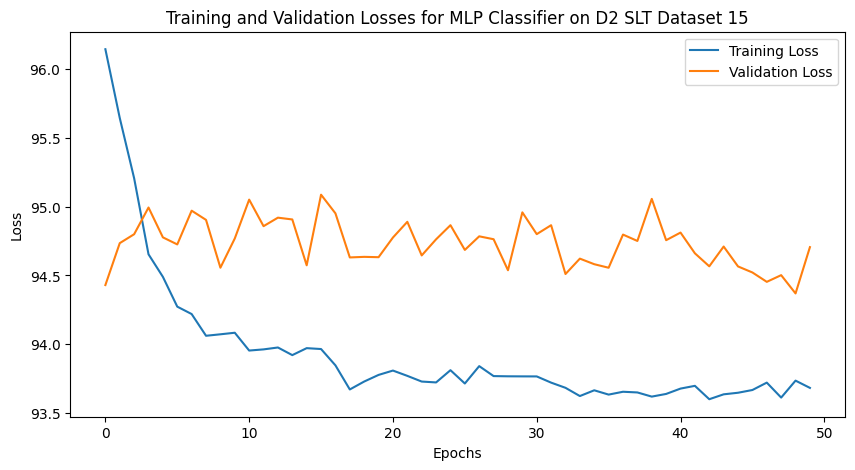

Test Loss: 79.6397, Test Accuracy: 0.7650, AUROC: 0.6416
Training on D2 SLT Dataset 16/33
Epoch 1/50, Training Loss: 96.1903, Validation Loss: 94.7407, Training Accuracy: 0.5368
Epoch 10/50, Training Loss: 93.9289, Validation Loss: 94.7538, Training Accuracy: 0.9701
Epoch 20/50, Training Loss: 93.7775, Validation Loss: 94.9410, Training Accuracy: 0.9771
Epoch 30/50, Training Loss: 93.7034, Validation Loss: 94.9289, Training Accuracy: 0.9806
Epoch 40/50, Training Loss: 93.6206, Validation Loss: 94.6086, Training Accuracy: 0.9875
Epoch 50/50, Training Loss: 93.5924, Validation Loss: 94.8637, Training Accuracy: 0.9910


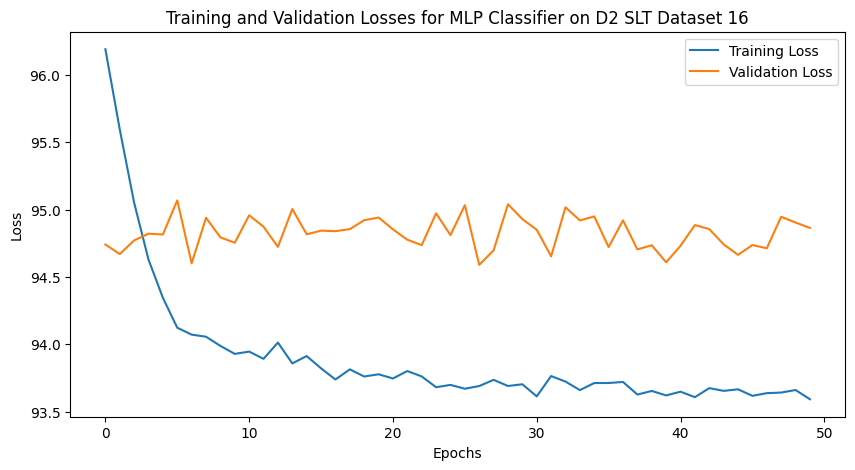

Test Loss: 79.6487, Test Accuracy: 0.7650, AUROC: 0.6628
Training on D2 SLT Dataset 17/33
Epoch 1/50, Training Loss: 96.1852, Validation Loss: 94.8283, Training Accuracy: 0.5729
Epoch 10/50, Training Loss: 93.9788, Validation Loss: 94.9455, Training Accuracy: 0.9597
Epoch 20/50, Training Loss: 93.7463, Validation Loss: 94.8354, Training Accuracy: 0.9806
Epoch 30/50, Training Loss: 93.7433, Validation Loss: 94.8279, Training Accuracy: 0.9819
Epoch 40/50, Training Loss: 93.6393, Validation Loss: 94.7760, Training Accuracy: 0.9868
Epoch 50/50, Training Loss: 93.6363, Validation Loss: 94.6504, Training Accuracy: 0.9875


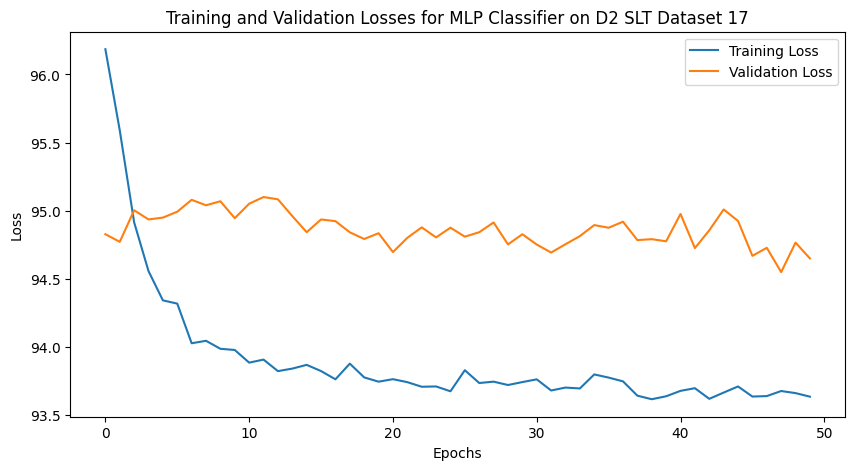

Test Loss: 79.6247, Test Accuracy: 0.7700, AUROC: 0.6398
Training on D2 SLT Dataset 18/33
Epoch 1/50, Training Loss: 96.2085, Validation Loss: 94.5198, Training Accuracy: 0.4444
Epoch 10/50, Training Loss: 93.9191, Validation Loss: 95.0570, Training Accuracy: 0.9694
Epoch 20/50, Training Loss: 93.7733, Validation Loss: 95.0412, Training Accuracy: 0.9764
Epoch 30/50, Training Loss: 93.6551, Validation Loss: 94.6750, Training Accuracy: 0.9868
Epoch 40/50, Training Loss: 93.6318, Validation Loss: 94.7393, Training Accuracy: 0.9868
Epoch 50/50, Training Loss: 93.5556, Validation Loss: 94.7586, Training Accuracy: 0.9938


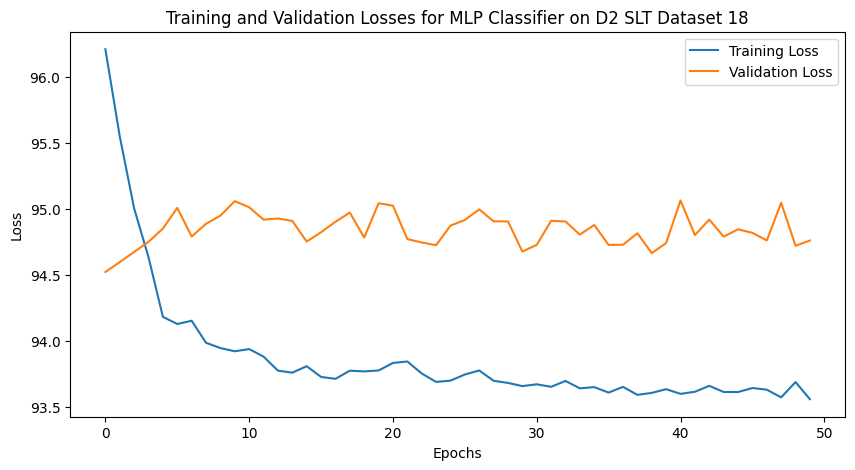

Test Loss: 79.4983, Test Accuracy: 0.7850, AUROC: 0.6333
Training on D2 SLT Dataset 19/33
Epoch 1/50, Training Loss: 96.2630, Validation Loss: 94.9198, Training Accuracy: 0.5319
Epoch 10/50, Training Loss: 93.9692, Validation Loss: 94.6797, Training Accuracy: 0.9625
Epoch 20/50, Training Loss: 93.7740, Validation Loss: 95.0586, Training Accuracy: 0.9792
Epoch 30/50, Training Loss: 93.6318, Validation Loss: 94.6885, Training Accuracy: 0.9882
Epoch 40/50, Training Loss: 93.5707, Validation Loss: 95.0550, Training Accuracy: 0.9917
Epoch 50/50, Training Loss: 93.5927, Validation Loss: 95.1876, Training Accuracy: 0.9910


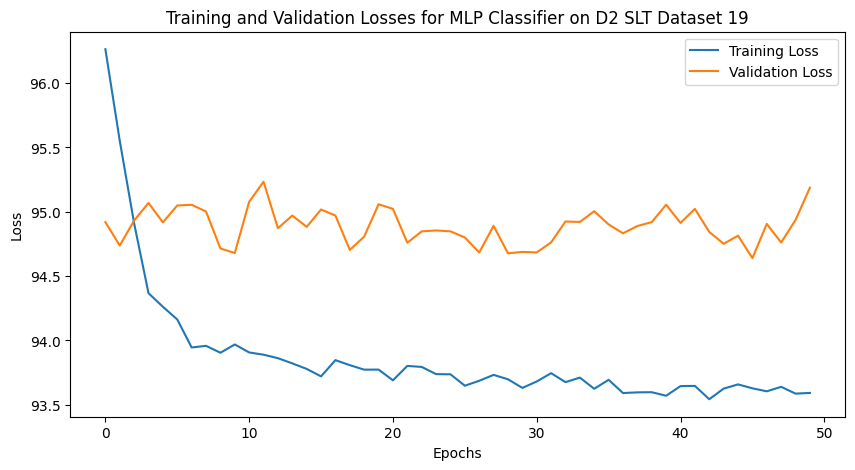

Test Loss: 79.7583, Test Accuracy: 0.7500, AUROC: 0.6681
Training on D2 SLT Dataset 20/33
Epoch 1/50, Training Loss: 96.2790, Validation Loss: 94.7007, Training Accuracy: 0.4924
Epoch 10/50, Training Loss: 93.9336, Validation Loss: 94.8501, Training Accuracy: 0.9688
Epoch 20/50, Training Loss: 93.6641, Validation Loss: 95.0995, Training Accuracy: 0.9861
Epoch 30/50, Training Loss: 93.6736, Validation Loss: 95.0716, Training Accuracy: 0.9868
Epoch 40/50, Training Loss: 93.6241, Validation Loss: 94.9542, Training Accuracy: 0.9903
Epoch 50/50, Training Loss: 93.6515, Validation Loss: 94.9279, Training Accuracy: 0.9875


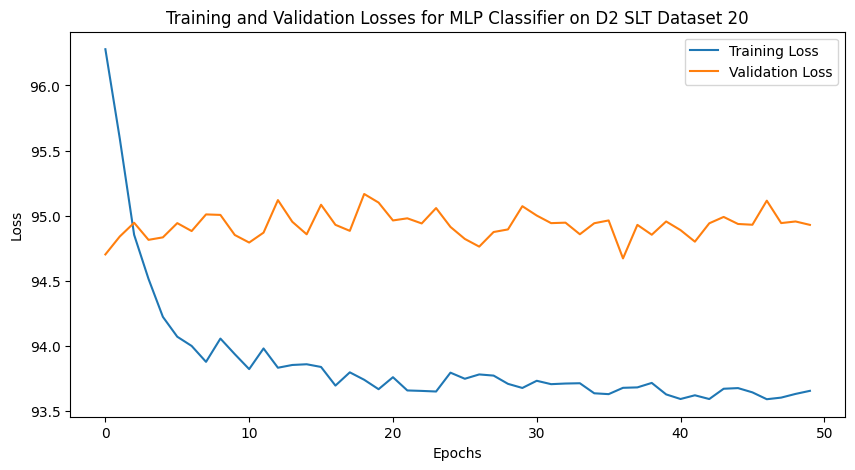

Test Loss: 79.4861, Test Accuracy: 0.7850, AUROC: 0.6134
Training on D2 SLT Dataset 21/33
Epoch 1/50, Training Loss: 96.1189, Validation Loss: 95.0057, Training Accuracy: 0.6687
Epoch 10/50, Training Loss: 93.8923, Validation Loss: 94.8729, Training Accuracy: 0.9701
Epoch 20/50, Training Loss: 93.7494, Validation Loss: 94.9966, Training Accuracy: 0.9819
Epoch 30/50, Training Loss: 93.6690, Validation Loss: 94.8659, Training Accuracy: 0.9868
Epoch 40/50, Training Loss: 93.6489, Validation Loss: 94.9390, Training Accuracy: 0.9854
Epoch 50/50, Training Loss: 93.6625, Validation Loss: 94.8174, Training Accuracy: 0.9882


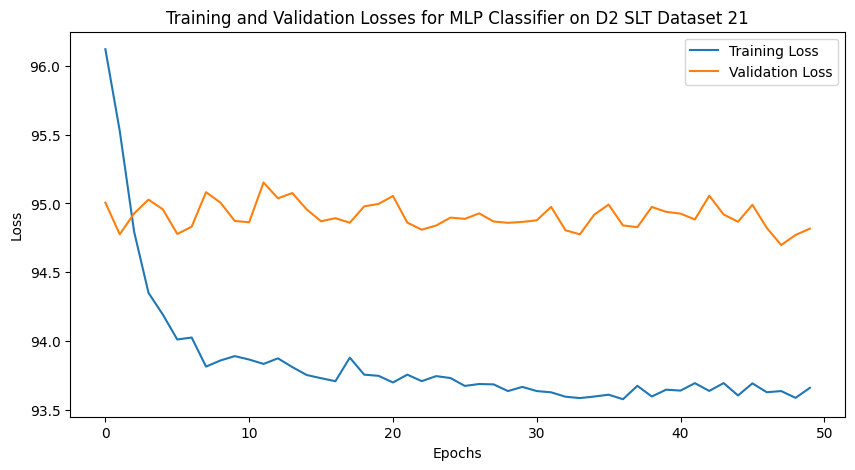

Test Loss: 79.6514, Test Accuracy: 0.7550, AUROC: 0.6446
Training on D2 SLT Dataset 22/33
Epoch 1/50, Training Loss: 96.3125, Validation Loss: 94.7182, Training Accuracy: 0.5903
Epoch 10/50, Training Loss: 93.8753, Validation Loss: 94.7497, Training Accuracy: 0.9701
Epoch 20/50, Training Loss: 93.7203, Validation Loss: 94.8316, Training Accuracy: 0.9819
Epoch 30/50, Training Loss: 93.6765, Validation Loss: 94.9099, Training Accuracy: 0.9868
Epoch 40/50, Training Loss: 93.7489, Validation Loss: 94.8881, Training Accuracy: 0.9812
Epoch 50/50, Training Loss: 93.6245, Validation Loss: 94.7911, Training Accuracy: 0.9896


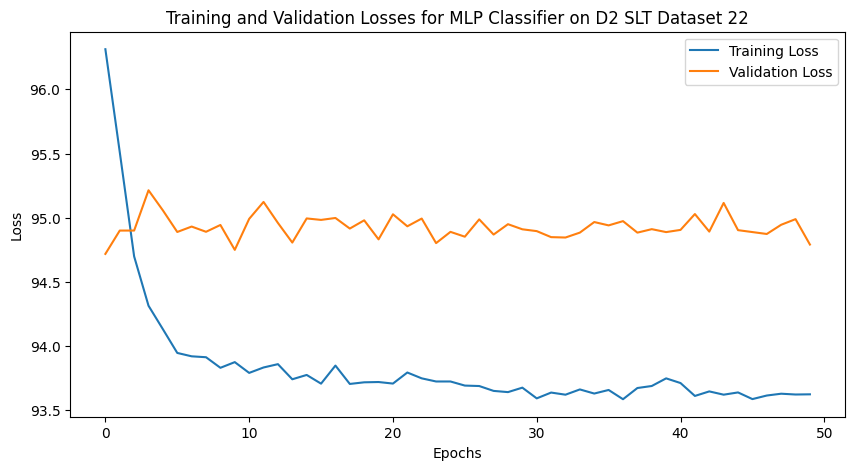

Test Loss: 79.5823, Test Accuracy: 0.7650, AUROC: 0.6642
Training on D2 SLT Dataset 23/33
Epoch 1/50, Training Loss: 96.2822, Validation Loss: 94.7584, Training Accuracy: 0.4285
Epoch 10/50, Training Loss: 93.8498, Validation Loss: 94.9969, Training Accuracy: 0.9736
Epoch 20/50, Training Loss: 93.7448, Validation Loss: 95.0199, Training Accuracy: 0.9812
Epoch 30/50, Training Loss: 93.7062, Validation Loss: 94.8161, Training Accuracy: 0.9799
Epoch 40/50, Training Loss: 93.5767, Validation Loss: 95.0055, Training Accuracy: 0.9924
Epoch 50/50, Training Loss: 93.5883, Validation Loss: 94.8585, Training Accuracy: 0.9910


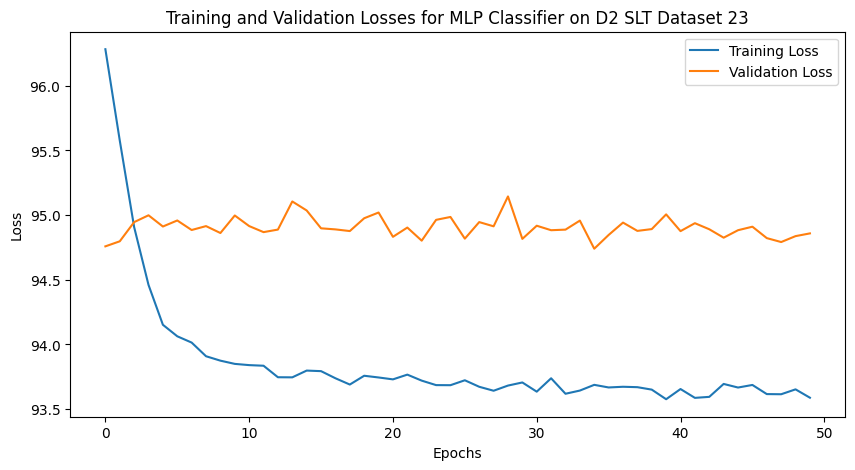

Test Loss: 79.4063, Test Accuracy: 0.7900, AUROC: 0.6500
Training on D2 SLT Dataset 24/33
Epoch 1/50, Training Loss: 96.1893, Validation Loss: 94.7404, Training Accuracy: 0.5424
Epoch 10/50, Training Loss: 93.8480, Validation Loss: 94.8455, Training Accuracy: 0.9757
Epoch 20/50, Training Loss: 93.7403, Validation Loss: 94.7901, Training Accuracy: 0.9812
Epoch 30/50, Training Loss: 93.6383, Validation Loss: 94.8200, Training Accuracy: 0.9889
Epoch 40/50, Training Loss: 93.6714, Validation Loss: 94.8269, Training Accuracy: 0.9854
Epoch 50/50, Training Loss: 93.7505, Validation Loss: 94.7726, Training Accuracy: 0.9778


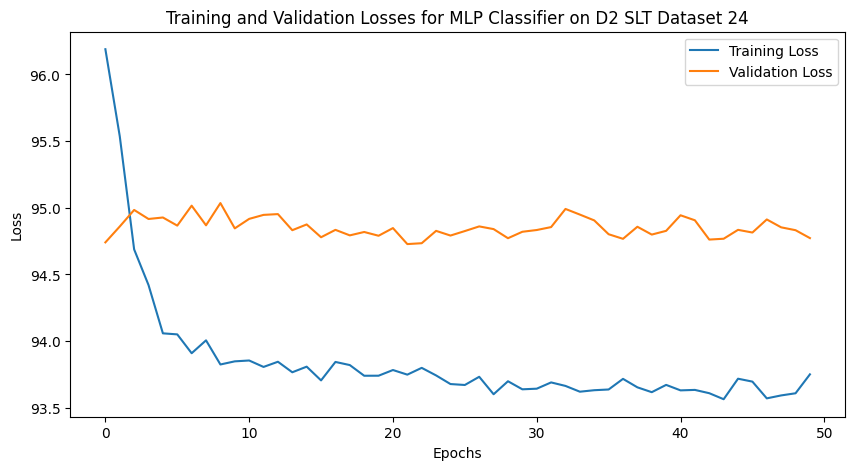

Test Loss: 79.7129, Test Accuracy: 0.7650, AUROC: 0.6852
Training on D2 SLT Dataset 25/33
Epoch 1/50, Training Loss: 96.2449, Validation Loss: 94.7355, Training Accuracy: 0.4868
Epoch 10/50, Training Loss: 93.7896, Validation Loss: 94.9835, Training Accuracy: 0.9778
Epoch 20/50, Training Loss: 93.6827, Validation Loss: 94.8887, Training Accuracy: 0.9854
Epoch 30/50, Training Loss: 93.6837, Validation Loss: 94.9520, Training Accuracy: 0.9854
Epoch 40/50, Training Loss: 93.6016, Validation Loss: 95.0086, Training Accuracy: 0.9882
Epoch 50/50, Training Loss: 93.6164, Validation Loss: 94.9027, Training Accuracy: 0.9882


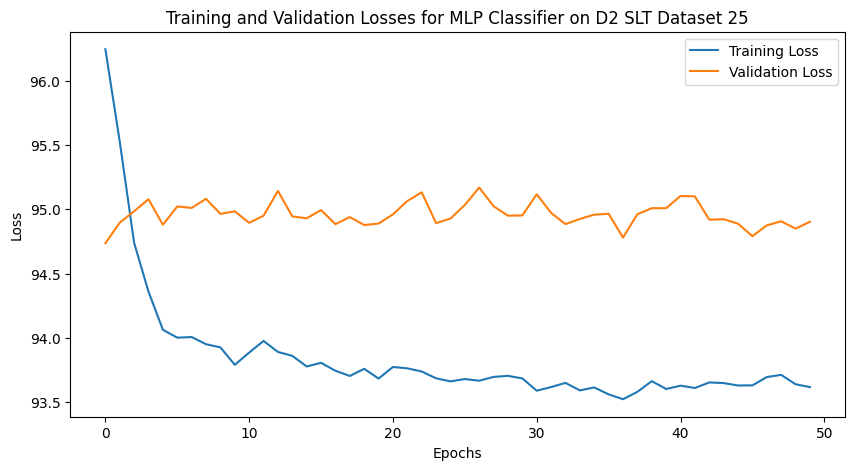

Test Loss: 79.4506, Test Accuracy: 0.7750, AUROC: 0.6746
Training on D2 SLT Dataset 26/33
Epoch 1/50, Training Loss: 96.1890, Validation Loss: 94.6317, Training Accuracy: 0.6750
Epoch 10/50, Training Loss: 93.8226, Validation Loss: 94.9246, Training Accuracy: 0.9729
Epoch 20/50, Training Loss: 93.6825, Validation Loss: 94.8329, Training Accuracy: 0.9826
Epoch 30/50, Training Loss: 93.5804, Validation Loss: 94.7449, Training Accuracy: 0.9910
Epoch 40/50, Training Loss: 93.5840, Validation Loss: 94.8666, Training Accuracy: 0.9924
Epoch 50/50, Training Loss: 93.6106, Validation Loss: 94.9950, Training Accuracy: 0.9889


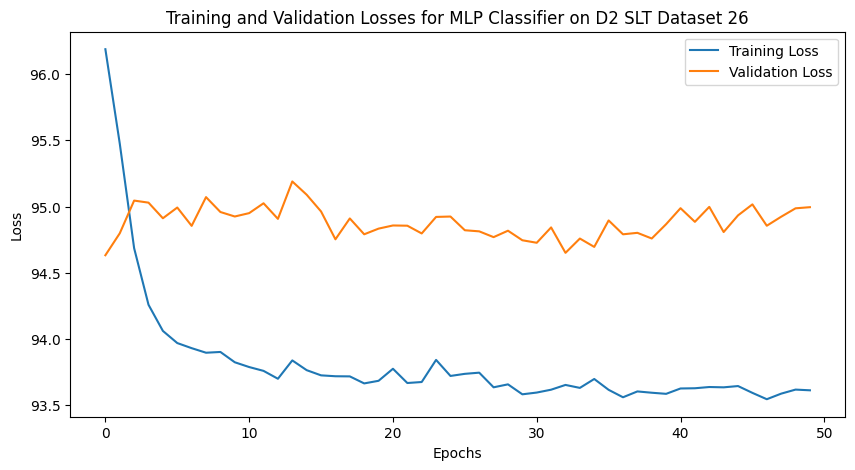

Test Loss: 79.2813, Test Accuracy: 0.7900, AUROC: 0.6425
Training on D2 SLT Dataset 27/33
Epoch 1/50, Training Loss: 96.2767, Validation Loss: 94.6672, Training Accuracy: 0.3715
Epoch 10/50, Training Loss: 93.8685, Validation Loss: 94.9049, Training Accuracy: 0.9757
Epoch 20/50, Training Loss: 93.7711, Validation Loss: 94.6720, Training Accuracy: 0.9743
Epoch 30/50, Training Loss: 93.6492, Validation Loss: 95.0575, Training Accuracy: 0.9854
Epoch 40/50, Training Loss: 93.6698, Validation Loss: 94.9442, Training Accuracy: 0.9833
Epoch 50/50, Training Loss: 93.5945, Validation Loss: 94.8515, Training Accuracy: 0.9896


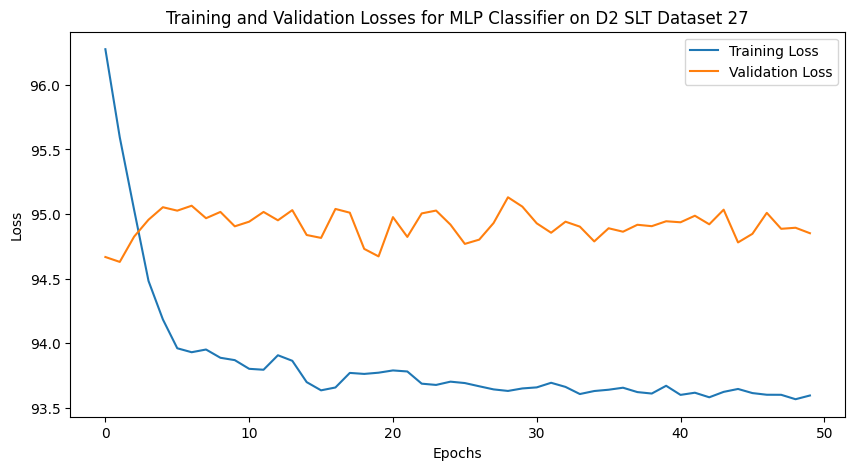

Test Loss: 79.5742, Test Accuracy: 0.7700, AUROC: 0.6231
Training on D2 SLT Dataset 28/33
Epoch 1/50, Training Loss: 96.1509, Validation Loss: 94.5753, Training Accuracy: 0.7438
Epoch 10/50, Training Loss: 93.8256, Validation Loss: 95.1643, Training Accuracy: 0.9764
Epoch 20/50, Training Loss: 93.6422, Validation Loss: 94.8929, Training Accuracy: 0.9861
Epoch 30/50, Training Loss: 93.7121, Validation Loss: 94.9532, Training Accuracy: 0.9833
Epoch 40/50, Training Loss: 93.6683, Validation Loss: 94.9765, Training Accuracy: 0.9889
Epoch 50/50, Training Loss: 93.6266, Validation Loss: 94.8915, Training Accuracy: 0.9882


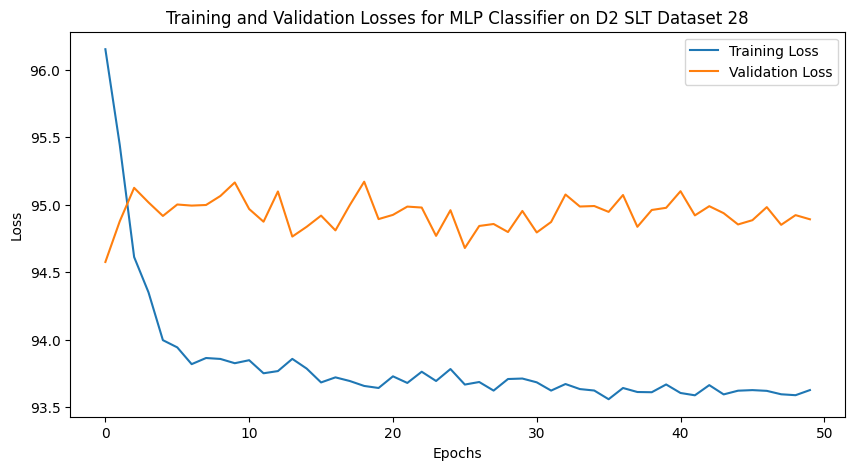

Test Loss: 79.5606, Test Accuracy: 0.7750, AUROC: 0.6194
Training on D2 SLT Dataset 29/33
Epoch 1/50, Training Loss: 96.3264, Validation Loss: 94.4761, Training Accuracy: 0.5167
Epoch 10/50, Training Loss: 93.8526, Validation Loss: 94.9039, Training Accuracy: 0.9729
Epoch 20/50, Training Loss: 93.7076, Validation Loss: 94.8311, Training Accuracy: 0.9812
Epoch 30/50, Training Loss: 93.6467, Validation Loss: 94.8365, Training Accuracy: 0.9875
Epoch 40/50, Training Loss: 93.5804, Validation Loss: 94.9873, Training Accuracy: 0.9910
Epoch 50/50, Training Loss: 93.6171, Validation Loss: 94.9020, Training Accuracy: 0.9910


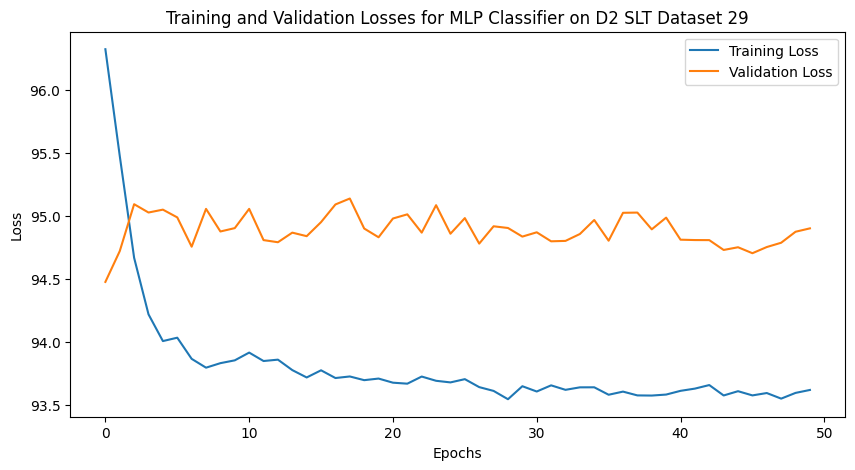

Test Loss: 79.8052, Test Accuracy: 0.7450, AUROC: 0.6180
Training on D2 SLT Dataset 30/33
Epoch 1/50, Training Loss: 96.2395, Validation Loss: 94.7429, Training Accuracy: 0.5632
Epoch 10/50, Training Loss: 93.7500, Validation Loss: 94.9079, Training Accuracy: 0.9771
Epoch 20/50, Training Loss: 93.6702, Validation Loss: 94.7996, Training Accuracy: 0.9826
Epoch 30/50, Training Loss: 93.6370, Validation Loss: 94.8989, Training Accuracy: 0.9861
Epoch 40/50, Training Loss: 93.6455, Validation Loss: 94.8686, Training Accuracy: 0.9868
Epoch 50/50, Training Loss: 93.5295, Validation Loss: 94.7530, Training Accuracy: 0.9958


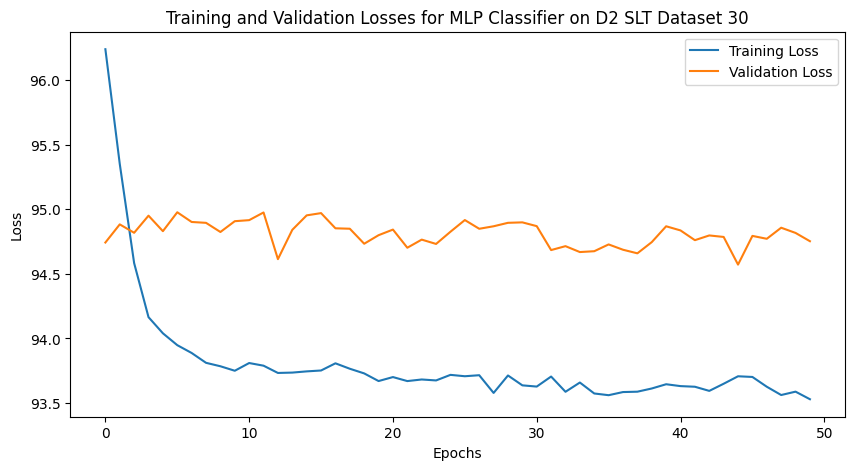

Test Loss: 79.4249, Test Accuracy: 0.7900, AUROC: 0.5595
Training on D2 SLT Dataset 31/33
Epoch 1/50, Training Loss: 96.2176, Validation Loss: 94.9985, Training Accuracy: 0.5299
Epoch 10/50, Training Loss: 93.8194, Validation Loss: 94.8981, Training Accuracy: 0.9729
Epoch 20/50, Training Loss: 93.7331, Validation Loss: 94.9748, Training Accuracy: 0.9833
Epoch 30/50, Training Loss: 93.6230, Validation Loss: 94.8733, Training Accuracy: 0.9875
Epoch 40/50, Training Loss: 93.6230, Validation Loss: 95.0058, Training Accuracy: 0.9896
Epoch 50/50, Training Loss: 93.5887, Validation Loss: 94.8075, Training Accuracy: 0.9931


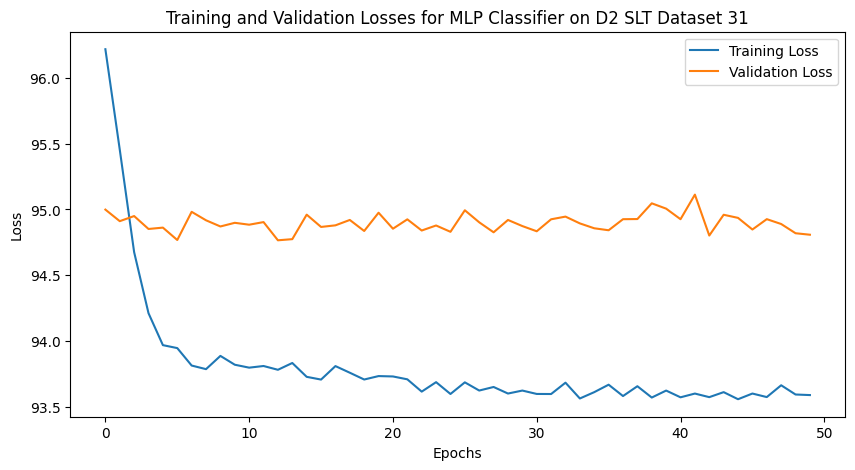

Test Loss: 79.5319, Test Accuracy: 0.7800, AUROC: 0.6150
Training on D2 SLT Dataset 32/33
Epoch 1/50, Training Loss: 96.1695, Validation Loss: 94.7773, Training Accuracy: 0.5590
Epoch 10/50, Training Loss: 93.8342, Validation Loss: 94.9393, Training Accuracy: 0.9743
Epoch 20/50, Training Loss: 93.7523, Validation Loss: 94.9816, Training Accuracy: 0.9812
Epoch 30/50, Training Loss: 93.6096, Validation Loss: 94.8985, Training Accuracy: 0.9889
Epoch 40/50, Training Loss: 93.5875, Validation Loss: 94.9217, Training Accuracy: 0.9924
Epoch 50/50, Training Loss: 93.6434, Validation Loss: 94.9884, Training Accuracy: 0.9896


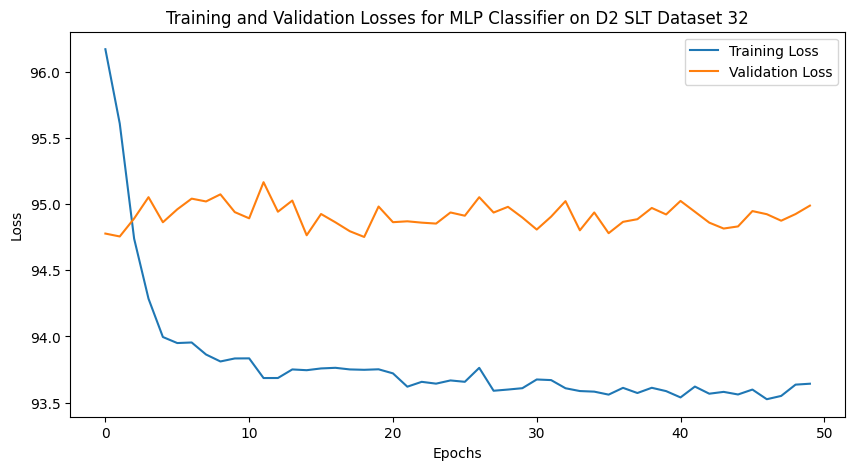

Test Loss: 79.4224, Test Accuracy: 0.7900, AUROC: 0.6062
Training on D2 SLT Dataset 33/33
Epoch 1/50, Training Loss: 96.1318, Validation Loss: 94.5465, Training Accuracy: 0.5396
Epoch 10/50, Training Loss: 93.9319, Validation Loss: 95.2843, Training Accuracy: 0.9646
Epoch 20/50, Training Loss: 93.7530, Validation Loss: 95.0057, Training Accuracy: 0.9785
Epoch 30/50, Training Loss: 93.6334, Validation Loss: 94.9006, Training Accuracy: 0.9889
Epoch 40/50, Training Loss: 93.6138, Validation Loss: 94.9924, Training Accuracy: 0.9910
Epoch 50/50, Training Loss: 93.6038, Validation Loss: 95.0918, Training Accuracy: 0.9903


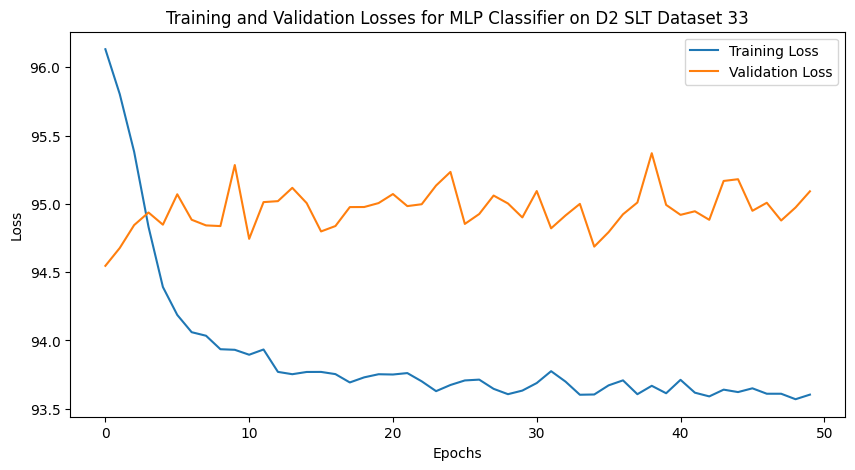

Test Loss: 80.0070, Test Accuracy: 0.7400, AUROC: 0.5259


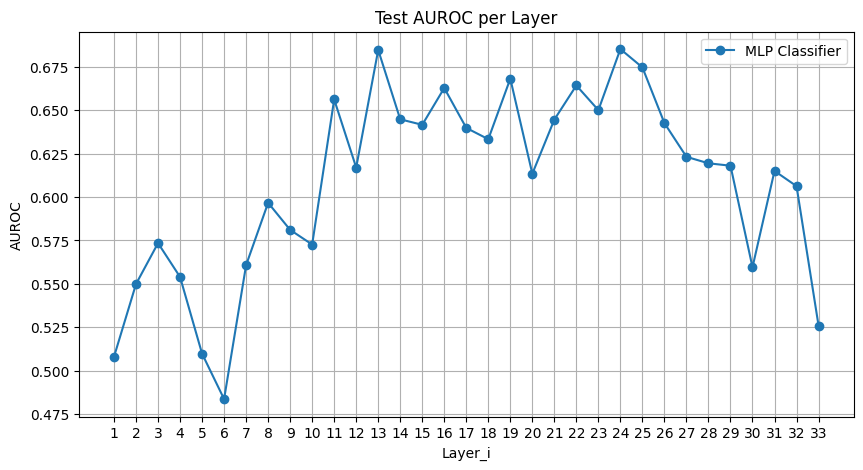

In [175]:
# Training with MLP.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4096   # Token embedding dimensions
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50
tmlpa_test_accs = []
tmlpa_test_aucs = []

for i, (train_loader, valid_loader, test_loader) in enumerate(zip(d2a_tbg_train_dataloaders, d2a_tbg_valid_dataloaders, d2a_tbg_test_dataloaders)):
    print(f"Training on D2 TBG Dataset {i+1}/{len(d2a_tbg_train_dataloaders)}")
    model = MLPClassifier(in_dim, hid_dims, dropout)
    train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on D2 TBG Dataset {i+1}", silent=False)
    test_loss, test_acc, test_auc = evaluate_on_test(model, test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tmlpa_test_accs.append(test_acc)
    tmlpa_test_aucs.append(test_auc)

# plot_1d_metrics([tmlpa_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([tmlpa_test_aucs], ['MLP Classifier'], 'AUROC')

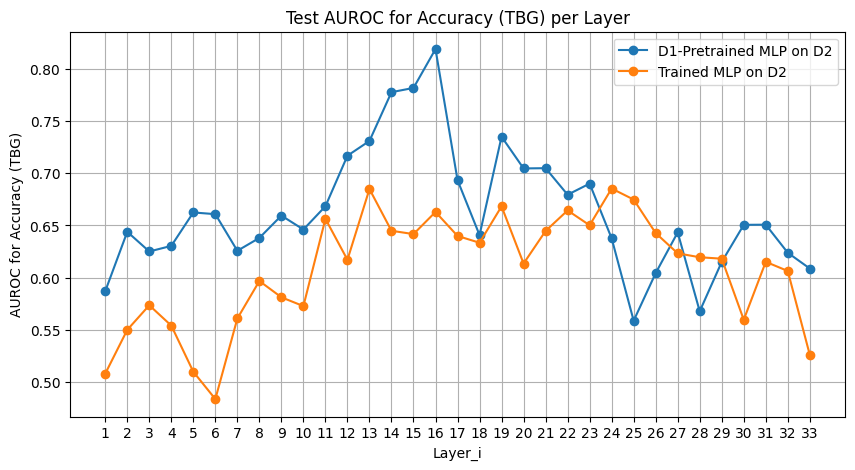

In [183]:
# Comparison with using pretrained model on D1 for prediction on D2
plot_1d_metrics([tmlp2a_test_aucs, tmlpa_test_aucs], ['D1-Pretrained MLP on D2', 'Trained MLP on D2'], 'AUROC for Accuracy (TBG)')

#### SLT Tokens

In [83]:
# Prepare all data sets from D2.
d2a_slt_train_dataloaders, d2a_slt_valid_dataloaders, d2a_slt_test_dataloaders = create_dataloaders(d2_slt_layered_datasets, d2_r_accuracies, total_size, batch_size, set_seed=True)
d2b_slt_train_dataloaders, d2b_slt_valid_dataloaders, d2b_slt_test_dataloaders = create_dataloaders(d2_slt_layered_datasets, d2_bca_entropy, total_size, batch_size, set_seed=True)

d2a_X_trains, d2a_X_vals, d2a_X_tests, d2a_y_trains, d2a_y_vals, d2a_y_tests = create_Xs_and_ys(d2_slt_layered_datasets, d2_r_accuracies, total_size)
d2b_X_trains, d2b_X_vals, d2b_X_tests, d2b_y_trains, d2b_y_vals, d2b_y_tests = create_Xs_and_ys(d2_slt_layered_datasets, d2_bca_entropy, total_size)

Training on D2 SLT Dataset 1/32
Validation Accuracy: 0.6138, AUROC: 0.5276
Training Loss: 0.6624, Validation Loss: 0.6657
Test Loss: 0.6727, Test Accuracy: 0.5983, AUROC: 0.5539
Training on D2 SLT Dataset 2/32
Validation Accuracy: 0.6138, AUROC: 0.5364
Training Loss: 0.6613, Validation Loss: 0.6652
Test Loss: 0.6719, Test Accuracy: 0.5983, AUROC: 0.5603
Training on D2 SLT Dataset 3/32
Validation Accuracy: 0.6138, AUROC: 0.5508
Training Loss: 0.6560, Validation Loss: 0.6635
Test Loss: 0.6693, Test Accuracy: 0.5983, AUROC: 0.5711
Training on D2 SLT Dataset 4/32
Validation Accuracy: 0.6138, AUROC: 0.5710
Training Loss: 0.6477, Validation Loss: 0.6608
Test Loss: 0.6703, Test Accuracy: 0.5983, AUROC: 0.5631
Training on D2 SLT Dataset 5/32
Validation Accuracy: 0.6369, AUROC: 0.5884
Training Loss: 0.6213, Validation Loss: 0.6553
Test Loss: 0.6692, Test Accuracy: 0.5873, AUROC: 0.5796
Training on D2 SLT Dataset 6/32
Validation Accuracy: 0.6277, AUROC: 0.5953
Training Loss: 0.5961, Validation L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6031, AUROC: 0.5906
Training Loss: 0.5450, Validation Loss: 0.6813
Test Loss: 0.6843, Test Accuracy: 0.6066, AUROC: 0.6130
Training on D2 SLT Dataset 8/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6092, AUROC: 0.6190
Training Loss: 0.5074, Validation Loss: 0.6699
Test Loss: 0.6733, Test Accuracy: 0.6399, AUROC: 0.6319
Training on D2 SLT Dataset 9/32


...

Validation Accuracy: 0.6600, AUROC: 0.6721
Training Loss: 0.0029, Validation Loss: 2.5194
Test Loss: 2.9603, Test Accuracy: 0.5596, AUROC: 0.5910
Training on D2 SLT Dataset 31/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6569, AUROC: 0.6874
Training Loss: 0.0025, Validation Loss: 2.3434
Test Loss: 2.7468, Test Accuracy: 0.5706, AUROC: 0.6145
Training on D2 SLT Dataset 32/32


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6615, AUROC: 0.6803
Training Loss: 0.0057, Validation Loss: 2.6351
Test Loss: 3.1044, Test Accuracy: 0.5789, AUROC: 0.6150


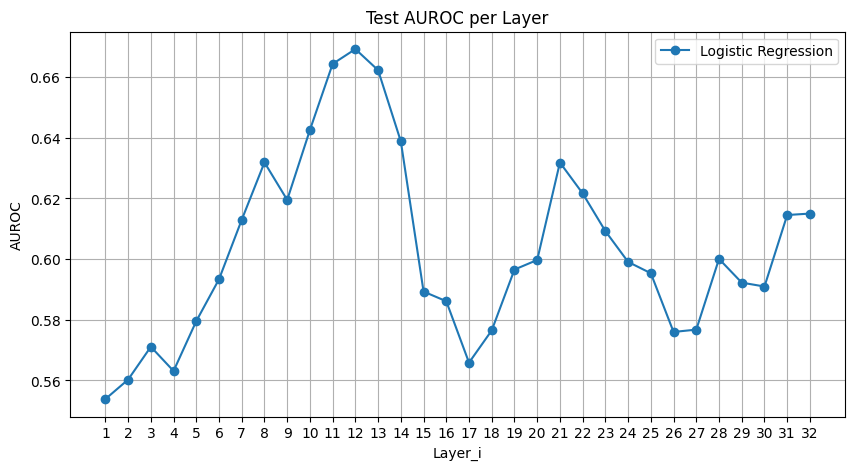

In [84]:
# Training Loops (LR)
slra_test_accs = []
slra_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(d2a_X_trains, d2a_X_vals, d2a_X_tests, d2a_y_trains, d2a_y_vals, d2a_y_tests)):
    print(f"Training on D2 SLT Dataset {i+1}/{len(d2a_X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on D2 SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    slra_test_accs.append(test_acc)
    slra_test_aucs.append(test_auc)

# plot_1d_metrics([slra_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([slra_test_aucs], ['Logistic Regression'], 'AUROC')

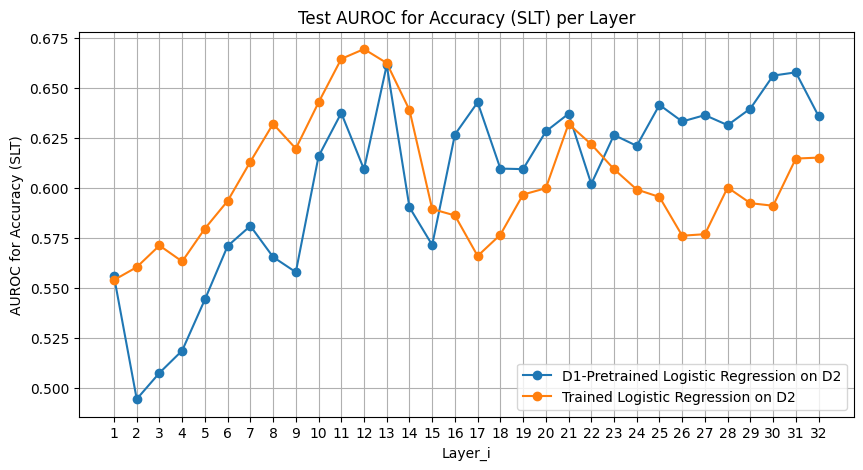

SLT: max AUROC for LR trained on D1's Binary SE, tested on D2's Accuracy: 0.6612 at 13 layer
SLT: max AUROC for LR trained on D2's Accuracy, tested on D2's Accuracy: 0.6692 at 12 layer


In [88]:
# Comparison with using pretrained model on D1 for prediction on D2
plot_1d_metrics([slr2a_test_aucs, slra_test_aucs], ['D1-Pretrained Logistic Regression on D2', 'Trained Logistic Regression on D2'], 'AUROC for Accuracy (SLT)')
print(f"SLT: max AUROC for LR trained on D1's Binary SE, tested on D2's Accuracy: {max(slr2a_test_aucs):.4f} at {np.argmax(slr2a_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on D2's Accuracy, tested on D2's Accuracy: {max(slra_test_aucs):.4f} at {np.argmax(slra_test_aucs)+1} layer")

Training on D2 SLT-SE Dataset 1/33
Validation Accuracy: 0.5846, AUROC: 0.5615
Training Loss: 0.6804, Validation Loss: 0.6773
Test Loss: 0.6787, Test Accuracy: 0.5651, AUROC: 0.6063
Training on D2 SLT-SE Dataset 2/33
Validation Accuracy: 0.5908, AUROC: 0.5608
Training Loss: 0.6774, Validation Loss: 0.6761
Test Loss: 0.6764, Test Accuracy: 0.5845, AUROC: 0.6013
Training on D2 SLT-SE Dataset 3/33
Validation Accuracy: 0.5800, AUROC: 0.5719
Training Loss: 0.6681, Validation Loss: 0.6729
Test Loss: 0.6668, Test Accuracy: 0.5956, AUROC: 0.6280
Training on D2 SLT-SE Dataset 4/33
Validation Accuracy: 0.5985, AUROC: 0.5974
Training Loss: 0.6544, Validation Loss: 0.6679
Test Loss: 0.6549, Test Accuracy: 0.6150, AUROC: 0.6568
Training on D2 SLT-SE Dataset 5/33
Validation Accuracy: 0.6231, AUROC: 0.6520
Training Loss: 0.6174, Validation Loss: 0.6481
Test Loss: 0.6370, Test Accuracy: 0.6233, AUROC: 0.6811
Training on D2 SLT-SE Dataset 6/33
Validation Accuracy: 0.6569, AUROC: 0.6987
Training Loss: 0.

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6954, AUROC: 0.7308
Training Loss: 0.5221, Validation Loss: 0.6058
Test Loss: 0.6107, Test Accuracy: 0.6759, AUROC: 0.7213
Training on D2 SLT-SE Dataset 8/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6877, AUROC: 0.7309
Training Loss: 0.4764, Validation Loss: 0.6119
Test Loss: 0.6095, Test Accuracy: 0.6704, AUROC: 0.7288
Training on D2 SLT-SE Dataset 9/33


...

Validation Accuracy: 0.7123, AUROC: 0.7901
Training Loss: 0.0023, Validation Loss: 1.5861
Test Loss: 1.7238, Test Accuracy: 0.7119, AUROC: 0.7783
Training on D2 SLT-SE Dataset 30/33
Validation Accuracy: 0.7077, AUROC: 0.7926
Training Loss: 0.0019, Validation Loss: 1.6407
Test Loss: 1.7268, Test Accuracy: 0.7258, AUROC: 0.7809
Training on D2 SLT-SE Dataset 31/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7338, AUROC: 0.8054
Training Loss: 0.0018, Validation Loss: 1.6383
Test Loss: 1.7118, Test Accuracy: 0.7091, AUROC: 0.7850
Training on D2 SLT-SE Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7092, AUROC: 0.7895
Training Loss: 0.0036, Validation Loss: 1.8275
Test Loss: 2.0869, Test Accuracy: 0.6870, AUROC: 0.7488


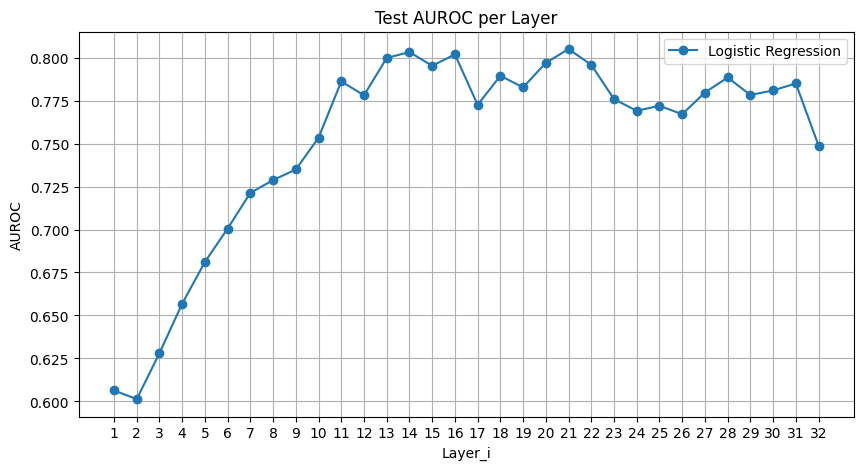

In [89]:
# Training Loops (LR)
slrb_test_accs = []
slrb_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(d2b_X_trains, d2b_X_vals, d2b_X_tests, d2b_y_trains, d2b_y_vals, d2b_y_tests)):
    print(f"Training on D2 SLT-SE Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on D2 SLT-SE Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    slrb_test_accs.append(test_acc)
    slrb_test_aucs.append(test_auc)

# plot_1d_metrics([slrb_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([slrb_test_aucs], ['Logistic Regression'], 'AUROC')

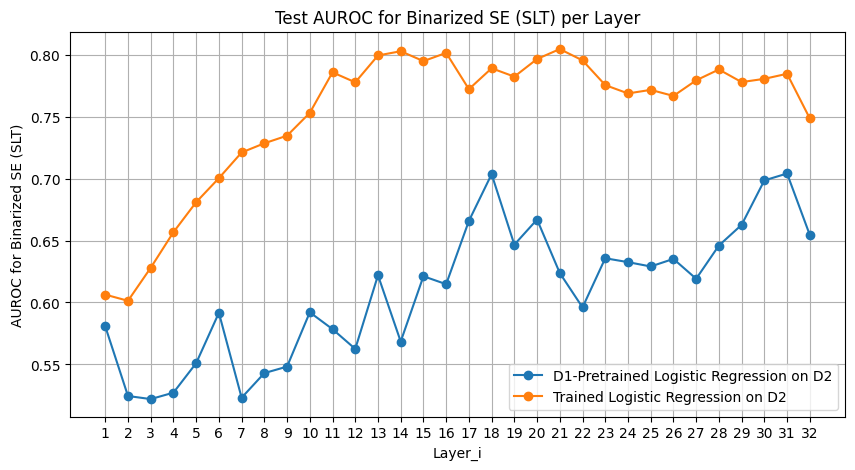

SLT: max AUROC for LR trained on D1's Binary SE, tested on D2's Binary SE: 0.7043 at 31 layer
SLT: max AUROC for LR both trained and tested on D2's Binary SE: 0.8050 at 21 layer


In [92]:
# Comparison with using pretrained model on D1 for prediction on D2
plot_1d_metrics([slr2b_test_aucs, slrb_test_aucs], ['D1-Pretrained Logistic Regression on D2', 'Trained Logistic Regression on D2'], 'AUROC for Binarized SE (SLT)')
print(f"SLT: max AUROC for LR trained on D1's Binary SE, tested on D2's Binary SE: {max(slr2b_test_aucs):.4f} at {np.argmax(slr2b_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR both trained and tested on D2's Binary SE: {max(slrb_test_aucs):.4f} at {np.argmax(slrb_test_aucs)+1} layer")

Using device: cuda
Training on D2 SLT Dataset 1/32
Epoch 1/50, Training Loss: 96.2043, Validation Loss: 94.3815, Training Accuracy: 0.6813
Epoch 10/50, Training Loss: 95.4355, Validation Loss: 94.9113, Training Accuracy: 0.8764
Epoch 20/50, Training Loss: 94.8803, Validation Loss: 94.6024, Training Accuracy: 0.9069
Epoch 30/50, Training Loss: 94.6191, Validation Loss: 95.7280, Training Accuracy: 0.9222
Epoch 40/50, Training Loss: 94.3440, Validation Loss: 94.8689, Training Accuracy: 0.9444
Epoch 50/50, Training Loss: 94.2355, Validation Loss: 94.9200, Training Accuracy: 0.9431


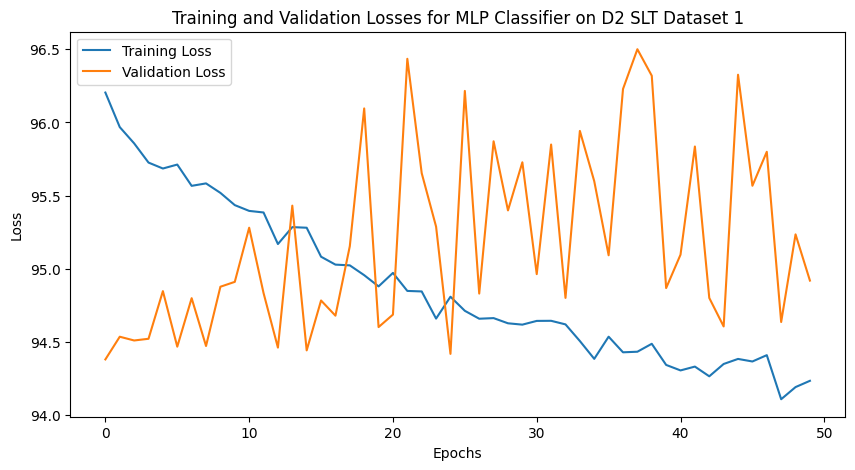

Test Loss: 79.5312, Test Accuracy: 0.7800, AUROC: 0.6357
Training on D2 SLT Dataset 2/32
Epoch 1/50, Training Loss: 96.1695, Validation Loss: 94.4025, Training Accuracy: 0.6493
Epoch 10/50, Training Loss: 95.4447, Validation Loss: 95.2064, Training Accuracy: 0.8701
Epoch 20/50, Training Loss: 94.8350, Validation Loss: 95.0267, Training Accuracy: 0.9083
Epoch 30/50, Training Loss: 94.5264, Validation Loss: 96.3014, Training Accuracy: 0.9278
Epoch 40/50, Training Loss: 94.2980, Validation Loss: 94.5787, Training Accuracy: 0.9451
Epoch 50/50, Training Loss: 94.1399, Validation Loss: 96.4054, Training Accuracy: 0.9542


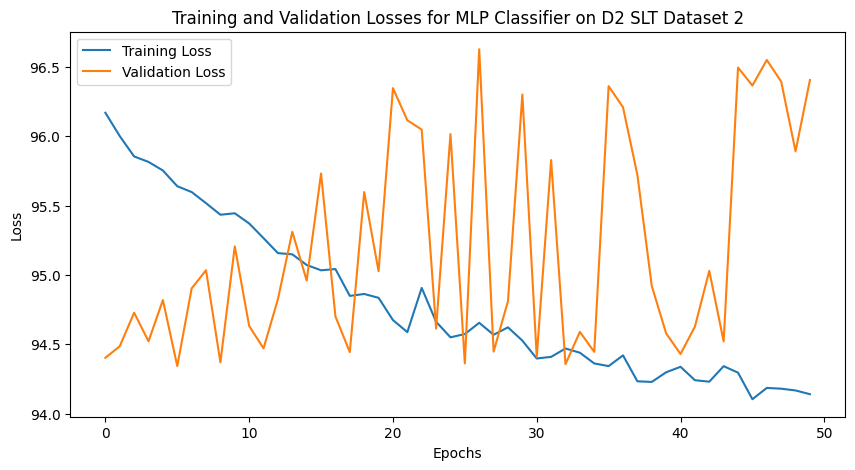

Test Loss: 80.4503, Test Accuracy: 0.5400, AUROC: 0.6392
Training on D2 SLT Dataset 3/32
Epoch 1/50, Training Loss: 96.1000, Validation Loss: 94.4336, Training Accuracy: 0.4924
Epoch 10/50, Training Loss: 95.4955, Validation Loss: 94.5917, Training Accuracy: 0.8139
Epoch 20/50, Training Loss: 94.6367, Validation Loss: 96.2929, Training Accuracy: 0.9181
Epoch 30/50, Training Loss: 94.2223, Validation Loss: 94.3731, Training Accuracy: 0.9465
Epoch 40/50, Training Loss: 94.1349, Validation Loss: 94.4923, Training Accuracy: 0.9528
Epoch 50/50, Training Loss: 94.1183, Validation Loss: 94.3825, Training Accuracy: 0.9583


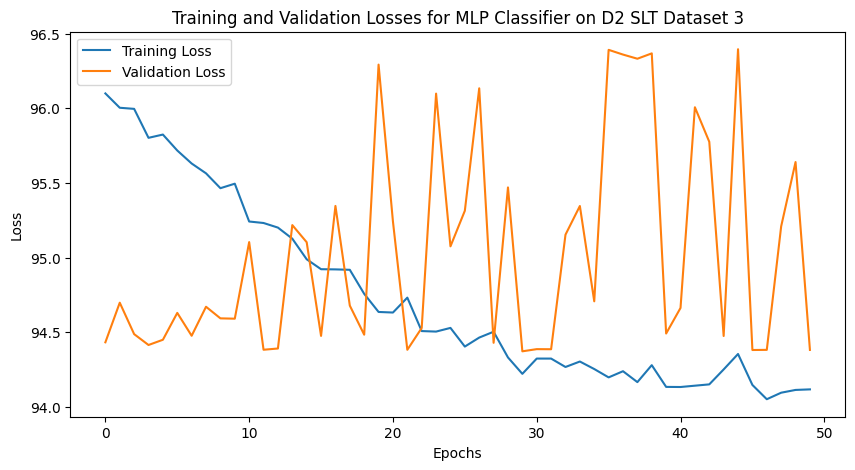

Test Loss: 79.2191, Test Accuracy: 0.8100, AUROC: 0.5258
Training on D2 SLT Dataset 4/32
Epoch 1/50, Training Loss: 96.1257, Validation Loss: 94.3646, Training Accuracy: 0.5208
Epoch 10/50, Training Loss: 95.1619, Validation Loss: 95.0994, Training Accuracy: 0.8806
Epoch 20/50, Training Loss: 94.4346, Validation Loss: 96.1765, Training Accuracy: 0.9347
Epoch 30/50, Training Loss: 94.2814, Validation Loss: 94.3831, Training Accuracy: 0.9479
Epoch 40/50, Training Loss: 94.0220, Validation Loss: 94.4333, Training Accuracy: 0.9639
Epoch 50/50, Training Loss: 93.9359, Validation Loss: 95.9838, Training Accuracy: 0.9639


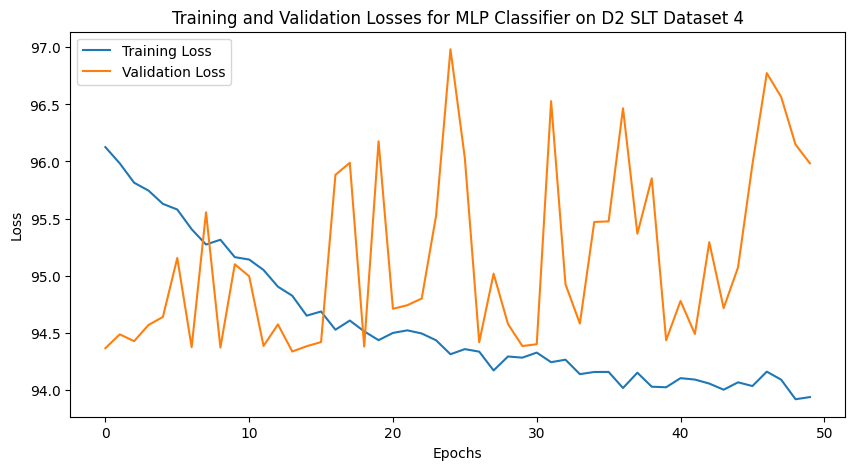

Test Loss: 80.2660, Test Accuracy: 0.6700, AUROC: 0.6372
Training on D2 SLT Dataset 5/32
Epoch 1/50, Training Loss: 96.1634, Validation Loss: 94.3841, Training Accuracy: 0.5208
Epoch 10/50, Training Loss: 94.6797, Validation Loss: 95.7834, Training Accuracy: 0.9160
Epoch 20/50, Training Loss: 94.0990, Validation Loss: 96.4410, Training Accuracy: 0.9590
Epoch 30/50, Training Loss: 93.8546, Validation Loss: 95.0998, Training Accuracy: 0.9743
Epoch 40/50, Training Loss: 93.8679, Validation Loss: 96.2566, Training Accuracy: 0.9743
Epoch 50/50, Training Loss: 93.8843, Validation Loss: 94.6210, Training Accuracy: 0.9701


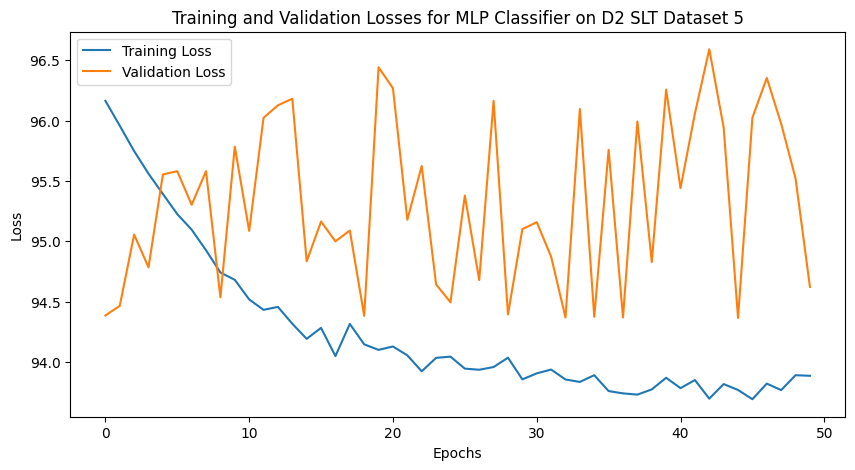

Test Loss: 79.1414, Test Accuracy: 0.8000, AUROC: 0.6276
Training on D2 SLT Dataset 6/32
Epoch 1/50, Training Loss: 96.2046, Validation Loss: 94.3435, Training Accuracy: 0.6431
Epoch 10/50, Training Loss: 94.5548, Validation Loss: 95.9728, Training Accuracy: 0.9264
Epoch 20/50, Training Loss: 93.9821, Validation Loss: 94.9599, Training Accuracy: 0.9618
Epoch 30/50, Training Loss: 93.9049, Validation Loss: 95.1127, Training Accuracy: 0.9688
Epoch 40/50, Training Loss: 93.7154, Validation Loss: 94.8757, Training Accuracy: 0.9826
Epoch 50/50, Training Loss: 93.7061, Validation Loss: 95.3458, Training Accuracy: 0.9826


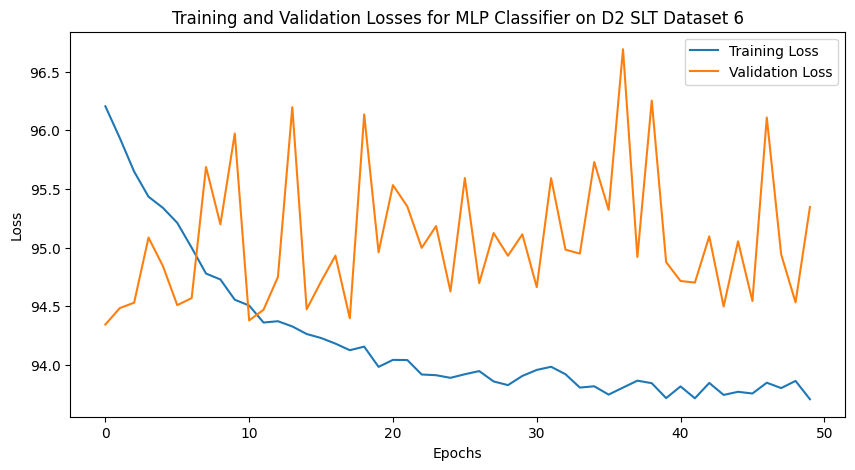

Test Loss: 79.7981, Test Accuracy: 0.7250, AUROC: 0.6232
Training on D2 SLT Dataset 7/32
Epoch 1/50, Training Loss: 96.0068, Validation Loss: 94.5001, Training Accuracy: 0.4167
Epoch 10/50, Training Loss: 94.7644, Validation Loss: 94.7315, Training Accuracy: 0.9028
Epoch 20/50, Training Loss: 94.0976, Validation Loss: 95.0025, Training Accuracy: 0.9535
Epoch 30/50, Training Loss: 93.8875, Validation Loss: 94.8422, Training Accuracy: 0.9729
Epoch 40/50, Training Loss: 93.9738, Validation Loss: 95.0100, Training Accuracy: 0.9625
Epoch 50/50, Training Loss: 93.7131, Validation Loss: 95.0559, Training Accuracy: 0.9812


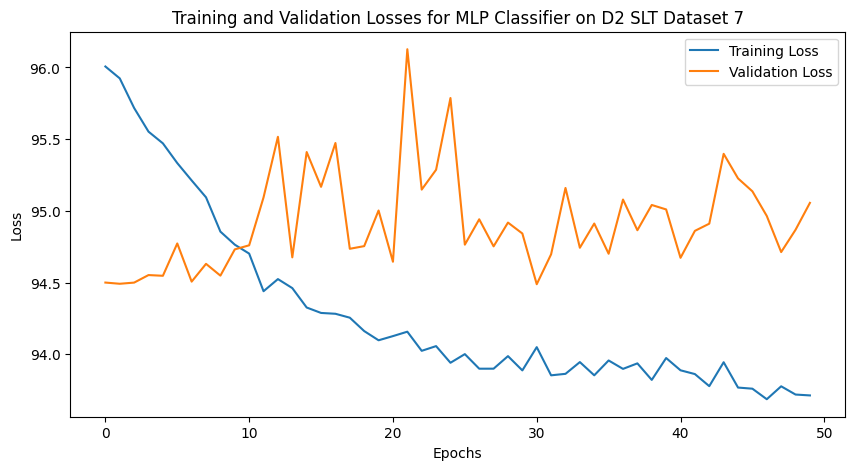

Test Loss: 79.8231, Test Accuracy: 0.7350, AUROC: 0.6891
Training on D2 SLT Dataset 8/32
Epoch 1/50, Training Loss: 96.0811, Validation Loss: 94.5451, Training Accuracy: 0.4736
Epoch 10/50, Training Loss: 94.7154, Validation Loss: 94.9155, Training Accuracy: 0.9090
Epoch 20/50, Training Loss: 93.9931, Validation Loss: 95.3029, Training Accuracy: 0.9632
Epoch 30/50, Training Loss: 93.9154, Validation Loss: 94.5700, Training Accuracy: 0.9667
Epoch 40/50, Training Loss: 93.8677, Validation Loss: 95.4840, Training Accuracy: 0.9708
Epoch 50/50, Training Loss: 93.8822, Validation Loss: 95.4088, Training Accuracy: 0.9701


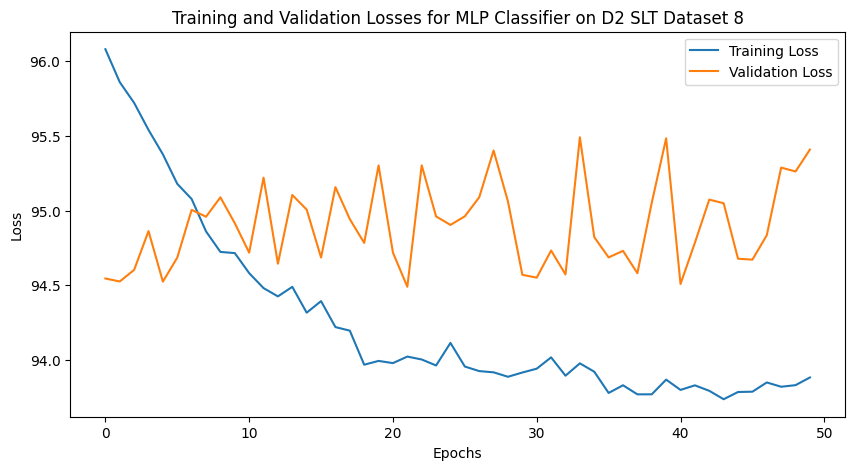

Test Loss: 79.7460, Test Accuracy: 0.7400, AUROC: 0.6715
Training on D2 SLT Dataset 9/32
Epoch 1/50, Training Loss: 96.1707, Validation Loss: 94.4981, Training Accuracy: 0.3750
Epoch 10/50, Training Loss: 94.8414, Validation Loss: 94.6016, Training Accuracy: 0.8951
Epoch 20/50, Training Loss: 94.1113, Validation Loss: 94.5537, Training Accuracy: 0.9556
Epoch 30/50, Training Loss: 93.8684, Validation Loss: 95.0733, Training Accuracy: 0.9722
Epoch 40/50, Training Loss: 93.7222, Validation Loss: 94.9860, Training Accuracy: 0.9799
Epoch 50/50, Training Loss: 93.7265, Validation Loss: 94.8534, Training Accuracy: 0.9826


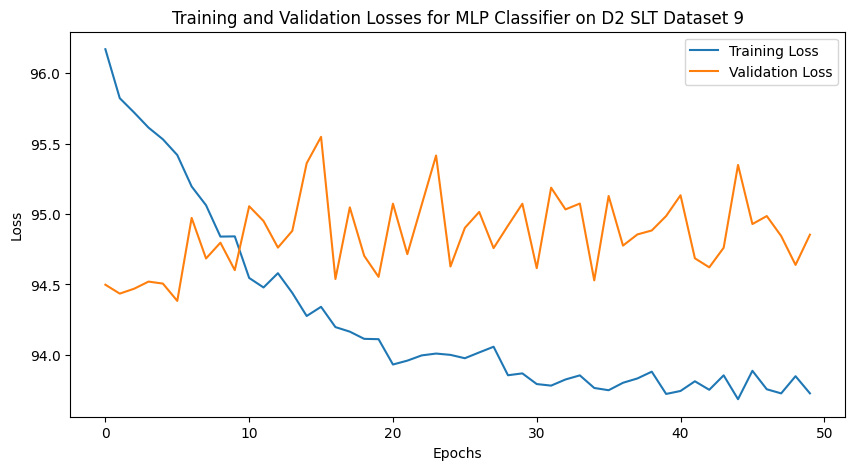

Test Loss: 79.5924, Test Accuracy: 0.7550, AUROC: 0.6739
Training on D2 SLT Dataset 10/32
Epoch 1/50, Training Loss: 96.1475, Validation Loss: 94.5703, Training Accuracy: 0.5708
Epoch 10/50, Training Loss: 94.5899, Validation Loss: 94.9046, Training Accuracy: 0.9167
Epoch 20/50, Training Loss: 94.0380, Validation Loss: 94.6945, Training Accuracy: 0.9597
Epoch 30/50, Training Loss: 93.9607, Validation Loss: 94.9599, Training Accuracy: 0.9639
Epoch 40/50, Training Loss: 93.8169, Validation Loss: 95.2710, Training Accuracy: 0.9743
Epoch 50/50, Training Loss: 93.6835, Validation Loss: 95.0687, Training Accuracy: 0.9847


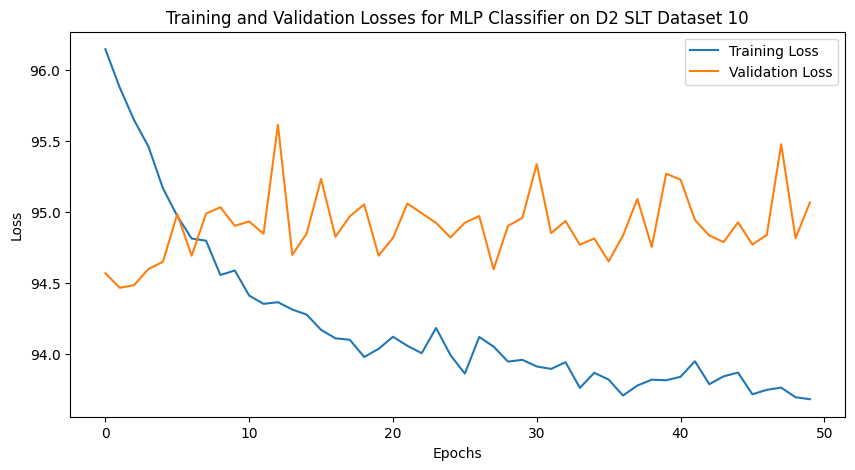

Test Loss: 79.1730, Test Accuracy: 0.7950, AUROC: 0.6949
Training on D2 SLT Dataset 11/32
Epoch 1/50, Training Loss: 96.1369, Validation Loss: 94.6911, Training Accuracy: 0.4181
Epoch 10/50, Training Loss: 94.5137, Validation Loss: 95.0598, Training Accuracy: 0.9243
Epoch 20/50, Training Loss: 94.1785, Validation Loss: 95.0975, Training Accuracy: 0.9403
Epoch 30/50, Training Loss: 93.8185, Validation Loss: 94.9055, Training Accuracy: 0.9785
Epoch 40/50, Training Loss: 93.8330, Validation Loss: 94.8112, Training Accuracy: 0.9736
Epoch 50/50, Training Loss: 93.7705, Validation Loss: 95.1141, Training Accuracy: 0.9778


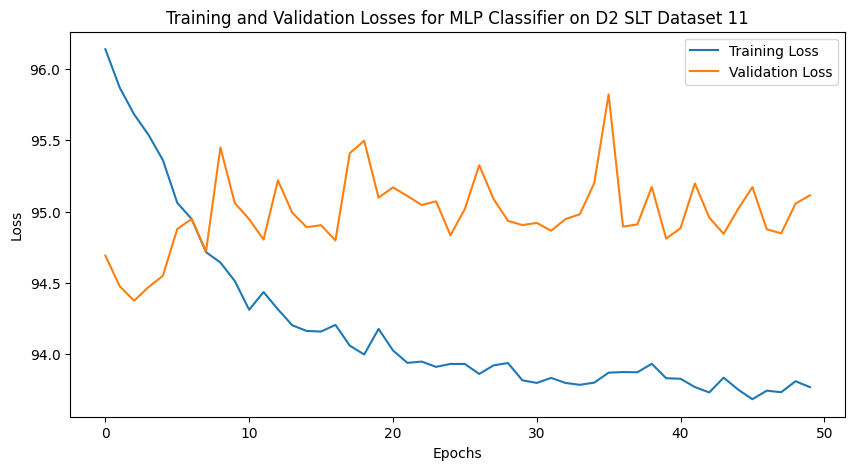

Test Loss: 78.9189, Test Accuracy: 0.8150, AUROC: 0.7740
Training on D2 SLT Dataset 12/32
Epoch 1/50, Training Loss: 96.1064, Validation Loss: 94.6336, Training Accuracy: 0.6042
Epoch 10/50, Training Loss: 94.3431, Validation Loss: 94.6016, Training Accuracy: 0.9472
Epoch 20/50, Training Loss: 94.1018, Validation Loss: 94.8473, Training Accuracy: 0.9625
Epoch 30/50, Training Loss: 93.7680, Validation Loss: 94.7708, Training Accuracy: 0.9771
Epoch 40/50, Training Loss: 93.8151, Validation Loss: 94.7081, Training Accuracy: 0.9764
Epoch 50/50, Training Loss: 93.6539, Validation Loss: 94.8616, Training Accuracy: 0.9854


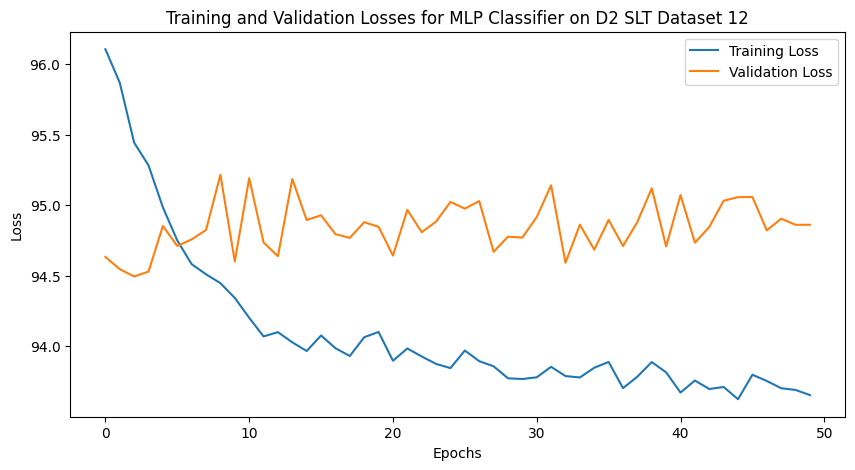

Test Loss: 79.2008, Test Accuracy: 0.8000, AUROC: 0.6949
Training on D2 SLT Dataset 13/32
Epoch 1/50, Training Loss: 96.0486, Validation Loss: 94.5196, Training Accuracy: 0.6368
Epoch 10/50, Training Loss: 94.2326, Validation Loss: 94.9454, Training Accuracy: 0.9458
Epoch 20/50, Training Loss: 93.9388, Validation Loss: 94.9832, Training Accuracy: 0.9639
Epoch 30/50, Training Loss: 93.9047, Validation Loss: 94.7809, Training Accuracy: 0.9694
Epoch 40/50, Training Loss: 93.8270, Validation Loss: 94.9773, Training Accuracy: 0.9715
Epoch 50/50, Training Loss: 93.7162, Validation Loss: 95.1749, Training Accuracy: 0.9792


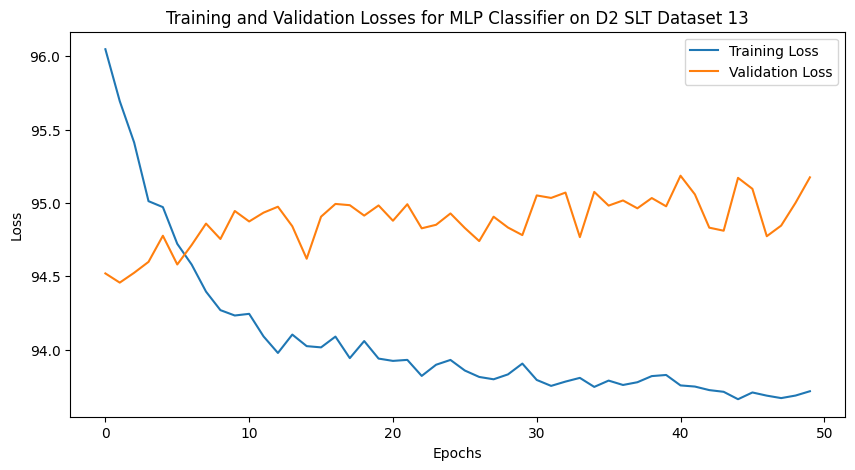

Test Loss: 79.4953, Test Accuracy: 0.7600, AUROC: 0.6977
Training on D2 SLT Dataset 14/32
Epoch 1/50, Training Loss: 96.0336, Validation Loss: 94.4161, Training Accuracy: 0.7021
Epoch 10/50, Training Loss: 94.2264, Validation Loss: 94.8753, Training Accuracy: 0.9444
Epoch 20/50, Training Loss: 93.9414, Validation Loss: 95.0193, Training Accuracy: 0.9653
Epoch 30/50, Training Loss: 93.7894, Validation Loss: 94.6666, Training Accuracy: 0.9750
Epoch 40/50, Training Loss: 93.6739, Validation Loss: 94.6747, Training Accuracy: 0.9882
Epoch 50/50, Training Loss: 93.7617, Validation Loss: 94.6832, Training Accuracy: 0.9812


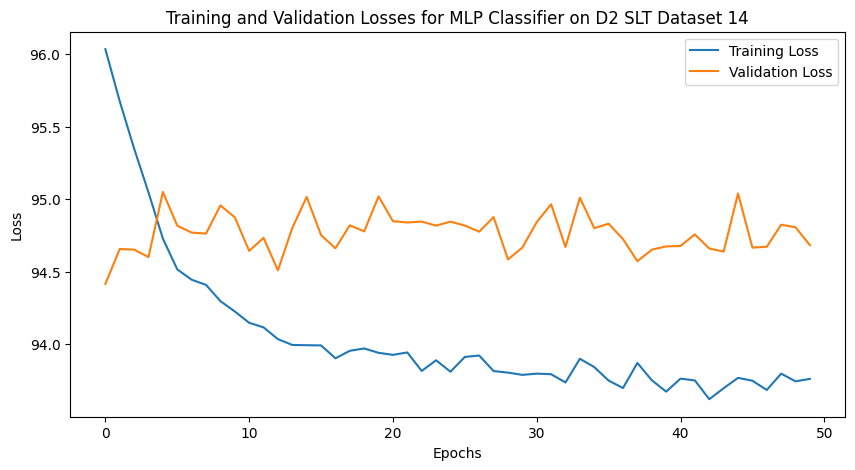

Test Loss: 79.0973, Test Accuracy: 0.8000, AUROC: 0.7247
Training on D2 SLT Dataset 15/32
Epoch 1/50, Training Loss: 96.1507, Validation Loss: 94.5691, Training Accuracy: 0.6139
Epoch 10/50, Training Loss: 94.1648, Validation Loss: 94.7452, Training Accuracy: 0.9465
Epoch 20/50, Training Loss: 93.8462, Validation Loss: 95.0209, Training Accuracy: 0.9708
Epoch 30/50, Training Loss: 93.7587, Validation Loss: 94.8883, Training Accuracy: 0.9812
Epoch 40/50, Training Loss: 93.7323, Validation Loss: 94.6119, Training Accuracy: 0.9792
Epoch 50/50, Training Loss: 93.7106, Validation Loss: 95.0011, Training Accuracy: 0.9812


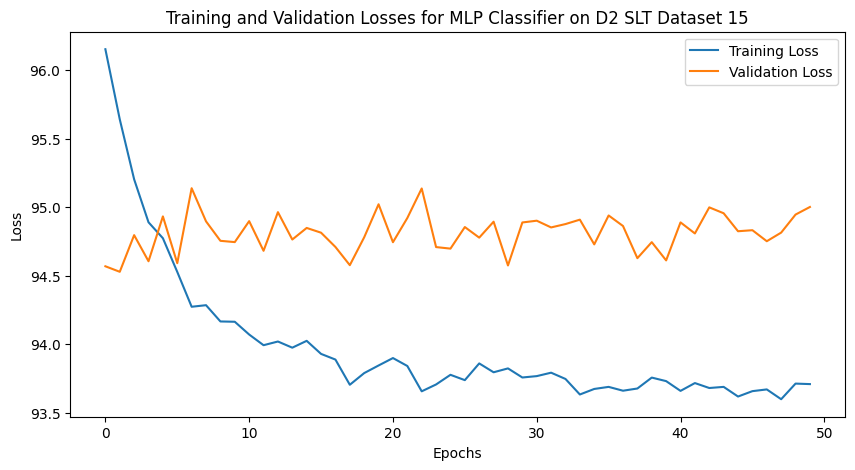

Test Loss: 79.2574, Test Accuracy: 0.7850, AUROC: 0.7178
Training on D2 SLT Dataset 16/32
Epoch 1/50, Training Loss: 96.0782, Validation Loss: 94.4559, Training Accuracy: 0.5340
Epoch 10/50, Training Loss: 94.1376, Validation Loss: 94.8565, Training Accuracy: 0.9521
Epoch 20/50, Training Loss: 93.7635, Validation Loss: 95.1095, Training Accuracy: 0.9812
Epoch 30/50, Training Loss: 93.6512, Validation Loss: 94.7274, Training Accuracy: 0.9882
Epoch 40/50, Training Loss: 93.6593, Validation Loss: 94.5809, Training Accuracy: 0.9854
Epoch 50/50, Training Loss: 93.6042, Validation Loss: 94.6735, Training Accuracy: 0.9910


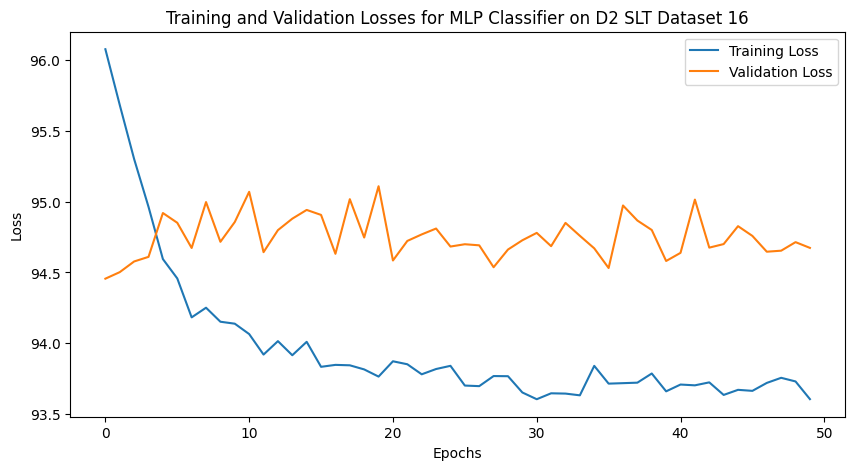

Test Loss: 79.4480, Test Accuracy: 0.7650, AUROC: 0.7101
Training on D2 SLT Dataset 17/32
Epoch 1/50, Training Loss: 96.1317, Validation Loss: 94.8219, Training Accuracy: 0.6069
Epoch 10/50, Training Loss: 93.9502, Validation Loss: 94.8049, Training Accuracy: 0.9632
Epoch 20/50, Training Loss: 93.8226, Validation Loss: 94.8709, Training Accuracy: 0.9729
Epoch 30/50, Training Loss: 93.6972, Validation Loss: 94.7967, Training Accuracy: 0.9826
Epoch 40/50, Training Loss: 93.6653, Validation Loss: 94.7174, Training Accuracy: 0.9868
Epoch 50/50, Training Loss: 93.6685, Validation Loss: 94.6525, Training Accuracy: 0.9840


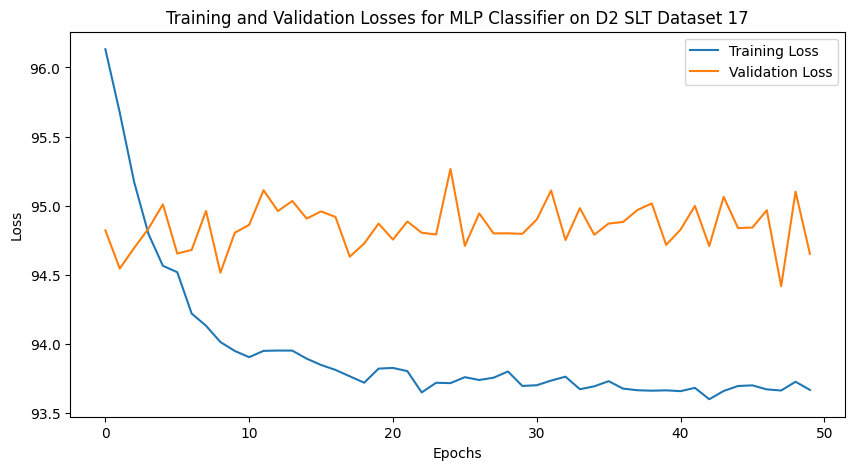

Test Loss: 79.1705, Test Accuracy: 0.7900, AUROC: 0.7460
Training on D2 SLT Dataset 18/32
Epoch 1/50, Training Loss: 96.1949, Validation Loss: 94.5000, Training Accuracy: 0.4750
Epoch 10/50, Training Loss: 94.0830, Validation Loss: 94.9072, Training Accuracy: 0.9549
Epoch 20/50, Training Loss: 93.8168, Validation Loss: 94.8538, Training Accuracy: 0.9736
Epoch 30/50, Training Loss: 93.6330, Validation Loss: 94.6412, Training Accuracy: 0.9854
Epoch 40/50, Training Loss: 93.6025, Validation Loss: 95.1189, Training Accuracy: 0.9896
Epoch 50/50, Training Loss: 93.6161, Validation Loss: 94.7204, Training Accuracy: 0.9882


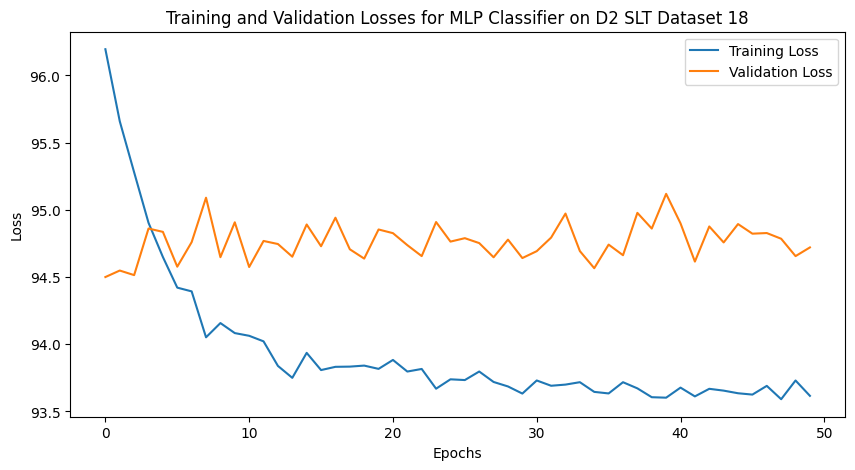

Test Loss: 79.4003, Test Accuracy: 0.7800, AUROC: 0.6873
Training on D2 SLT Dataset 19/32
Epoch 1/50, Training Loss: 96.1515, Validation Loss: 94.6000, Training Accuracy: 0.5535
Epoch 10/50, Training Loss: 94.0980, Validation Loss: 94.7278, Training Accuracy: 0.9507
Epoch 20/50, Training Loss: 93.8388, Validation Loss: 94.8939, Training Accuracy: 0.9729
Epoch 30/50, Training Loss: 93.6457, Validation Loss: 95.2445, Training Accuracy: 0.9854
Epoch 40/50, Training Loss: 93.6201, Validation Loss: 94.9707, Training Accuracy: 0.9882
Epoch 50/50, Training Loss: 93.6453, Validation Loss: 94.8998, Training Accuracy: 0.9854


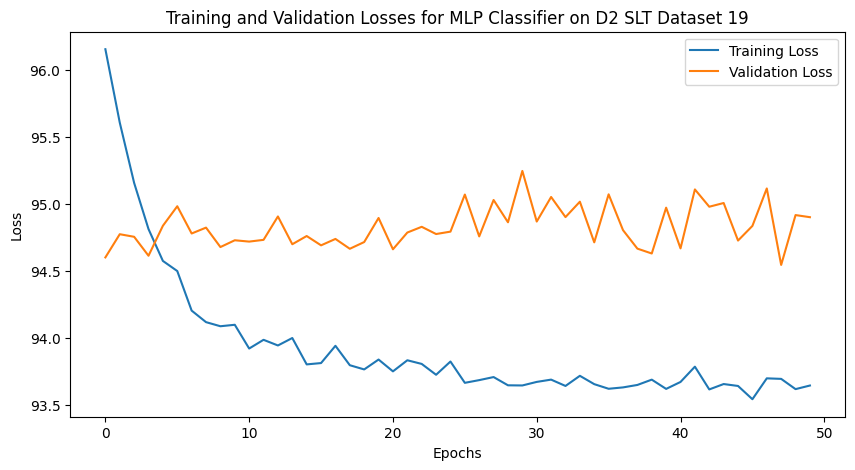

Test Loss: 79.2985, Test Accuracy: 0.7750, AUROC: 0.6902
Training on D2 SLT Dataset 20/32
Epoch 1/50, Training Loss: 96.1215, Validation Loss: 94.5667, Training Accuracy: 0.5062
Epoch 10/50, Training Loss: 94.1217, Validation Loss: 94.7766, Training Accuracy: 0.9556
Epoch 20/50, Training Loss: 93.8803, Validation Loss: 94.6346, Training Accuracy: 0.9708
Epoch 30/50, Training Loss: 93.6886, Validation Loss: 94.8363, Training Accuracy: 0.9847
Epoch 40/50, Training Loss: 93.7263, Validation Loss: 94.7985, Training Accuracy: 0.9812
Epoch 50/50, Training Loss: 93.6484, Validation Loss: 95.1158, Training Accuracy: 0.9889


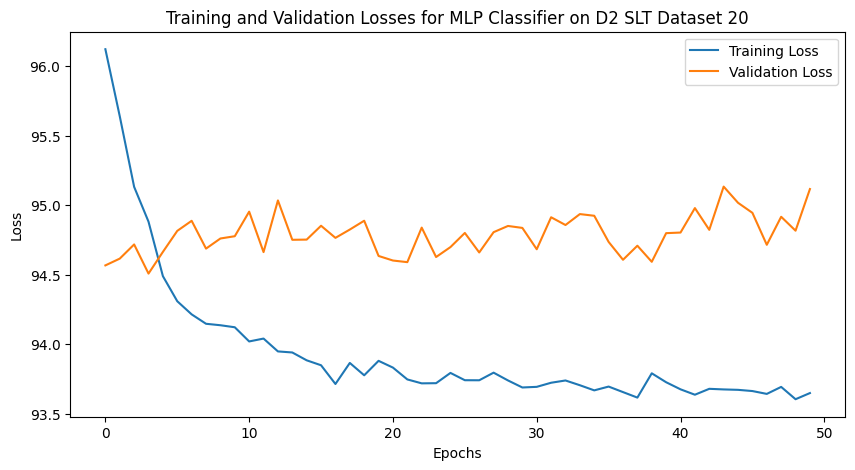

Test Loss: 79.3099, Test Accuracy: 0.7850, AUROC: 0.6984
Training on D2 SLT Dataset 21/32
Epoch 1/50, Training Loss: 96.1063, Validation Loss: 94.7996, Training Accuracy: 0.6715
Epoch 10/50, Training Loss: 94.1517, Validation Loss: 95.0740, Training Accuracy: 0.9500
Epoch 20/50, Training Loss: 93.9013, Validation Loss: 94.6635, Training Accuracy: 0.9694
Epoch 30/50, Training Loss: 93.7172, Validation Loss: 94.5002, Training Accuracy: 0.9826
Epoch 40/50, Training Loss: 93.7061, Validation Loss: 94.7076, Training Accuracy: 0.9806
Epoch 50/50, Training Loss: 93.6776, Validation Loss: 94.7168, Training Accuracy: 0.9854


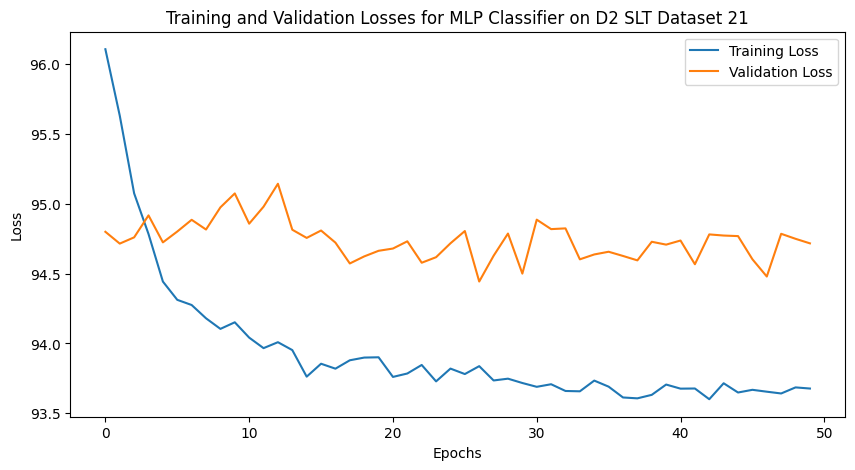

Test Loss: 79.3959, Test Accuracy: 0.7800, AUROC: 0.6986
Training on D2 SLT Dataset 22/32
Epoch 1/50, Training Loss: 96.2158, Validation Loss: 94.6767, Training Accuracy: 0.6278
Epoch 10/50, Training Loss: 93.9150, Validation Loss: 94.5716, Training Accuracy: 0.9674
Epoch 20/50, Training Loss: 93.8153, Validation Loss: 94.7736, Training Accuracy: 0.9715
Epoch 30/50, Training Loss: 93.8032, Validation Loss: 94.6071, Training Accuracy: 0.9792
Epoch 40/50, Training Loss: 93.7072, Validation Loss: 94.6344, Training Accuracy: 0.9812
Epoch 50/50, Training Loss: 93.6741, Validation Loss: 94.8840, Training Accuracy: 0.9833


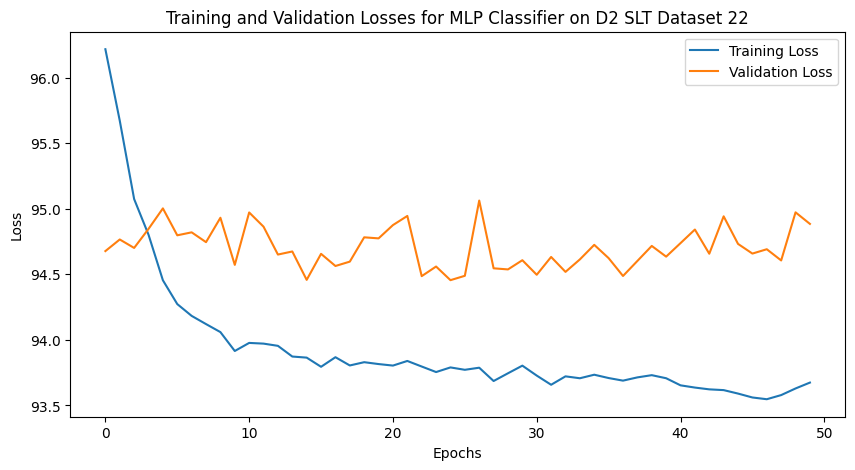

Test Loss: 79.5244, Test Accuracy: 0.7700, AUROC: 0.6645
Training on D2 SLT Dataset 23/32
Epoch 1/50, Training Loss: 96.2080, Validation Loss: 94.5848, Training Accuracy: 0.4764
Epoch 10/50, Training Loss: 93.9498, Validation Loss: 94.7436, Training Accuracy: 0.9646
Epoch 20/50, Training Loss: 93.8412, Validation Loss: 94.7909, Training Accuracy: 0.9701
Epoch 30/50, Training Loss: 93.7369, Validation Loss: 94.6066, Training Accuracy: 0.9799
Epoch 40/50, Training Loss: 93.6417, Validation Loss: 94.7689, Training Accuracy: 0.9861
Epoch 50/50, Training Loss: 93.6803, Validation Loss: 94.6397, Training Accuracy: 0.9833


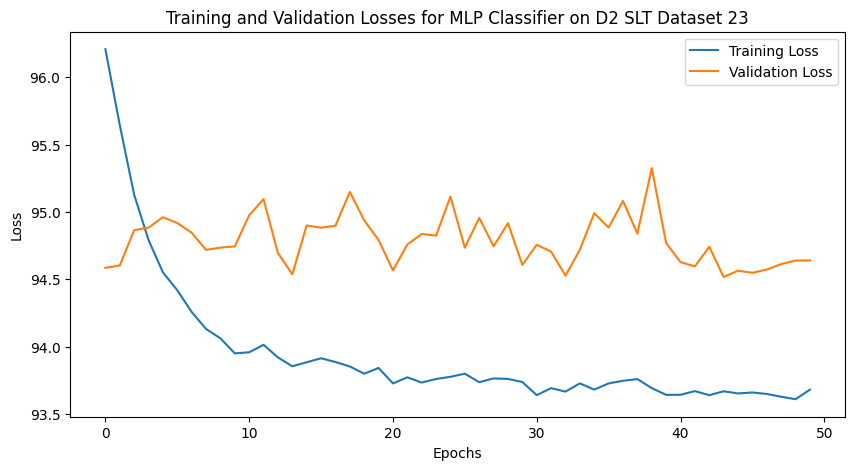

Test Loss: 79.3959, Test Accuracy: 0.7900, AUROC: 0.6855
Training on D2 SLT Dataset 24/32
Epoch 1/50, Training Loss: 96.0947, Validation Loss: 94.6441, Training Accuracy: 0.5771
Epoch 10/50, Training Loss: 94.0348, Validation Loss: 94.7035, Training Accuracy: 0.9583
Epoch 20/50, Training Loss: 93.8117, Validation Loss: 94.8485, Training Accuracy: 0.9715
Epoch 30/50, Training Loss: 93.7139, Validation Loss: 94.6102, Training Accuracy: 0.9792
Epoch 40/50, Training Loss: 93.6550, Validation Loss: 94.6904, Training Accuracy: 0.9875
Epoch 50/50, Training Loss: 93.6642, Validation Loss: 94.8828, Training Accuracy: 0.9882


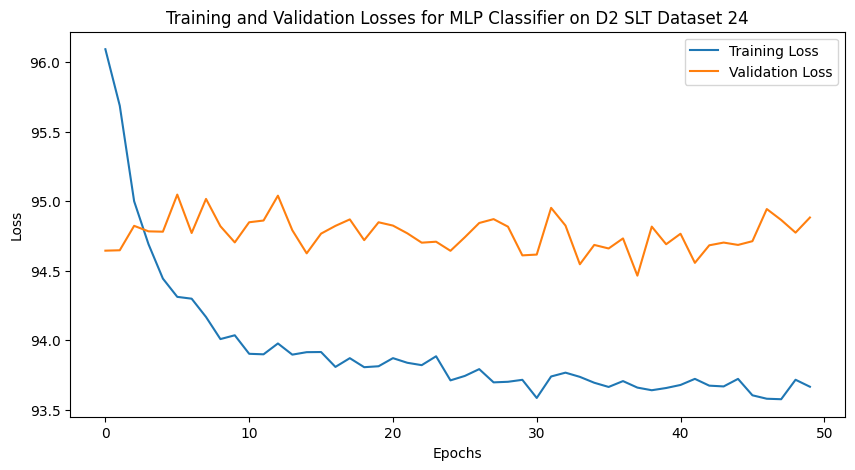

Test Loss: 79.3740, Test Accuracy: 0.7900, AUROC: 0.6776
Training on D2 SLT Dataset 25/32
Epoch 1/50, Training Loss: 96.1374, Validation Loss: 94.7010, Training Accuracy: 0.5257
Epoch 10/50, Training Loss: 94.0111, Validation Loss: 94.8229, Training Accuracy: 0.9639
Epoch 20/50, Training Loss: 93.7861, Validation Loss: 94.8266, Training Accuracy: 0.9778
Epoch 30/50, Training Loss: 93.7421, Validation Loss: 94.7026, Training Accuracy: 0.9826
Epoch 40/50, Training Loss: 93.6904, Validation Loss: 94.8700, Training Accuracy: 0.9826
Epoch 50/50, Training Loss: 93.5530, Validation Loss: 94.7344, Training Accuracy: 0.9931


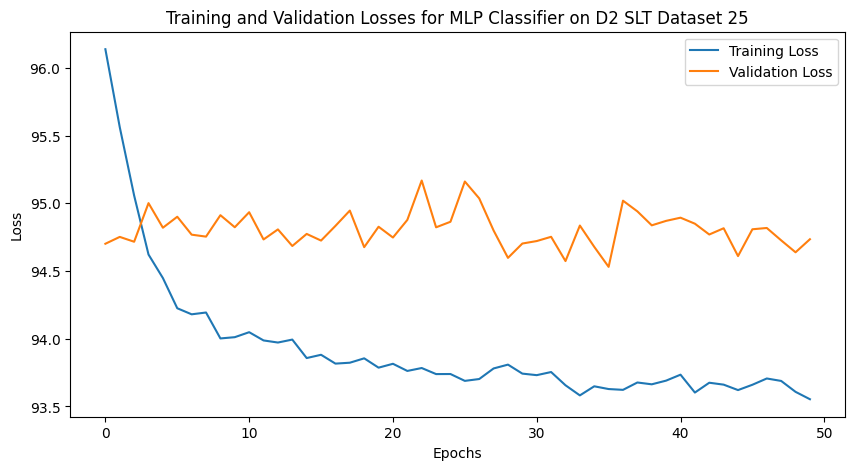

Test Loss: 79.3808, Test Accuracy: 0.7750, AUROC: 0.7383
Training on D2 SLT Dataset 26/32
Epoch 1/50, Training Loss: 96.0761, Validation Loss: 94.5406, Training Accuracy: 0.6854
Epoch 10/50, Training Loss: 94.1045, Validation Loss: 94.5847, Training Accuracy: 0.9528
Epoch 20/50, Training Loss: 93.7231, Validation Loss: 94.6605, Training Accuracy: 0.9778
Epoch 30/50, Training Loss: 93.6338, Validation Loss: 94.9109, Training Accuracy: 0.9868
Epoch 40/50, Training Loss: 93.7024, Validation Loss: 94.6907, Training Accuracy: 0.9812
Epoch 50/50, Training Loss: 93.6091, Validation Loss: 95.0067, Training Accuracy: 0.9903


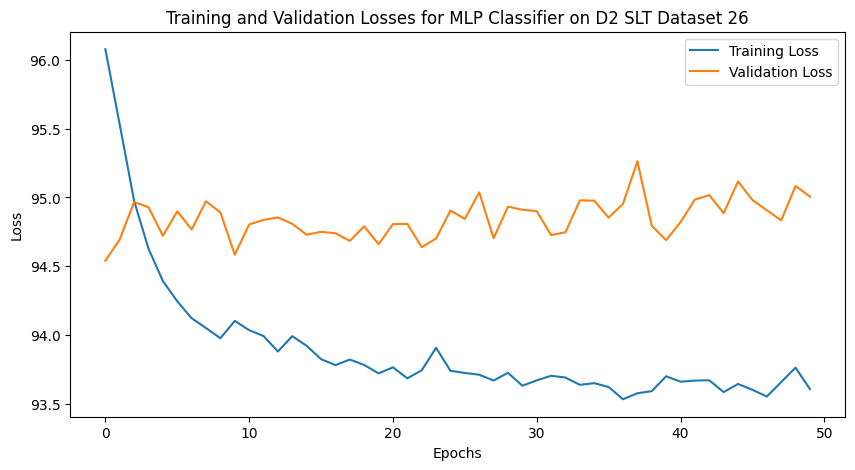

Test Loss: 79.5948, Test Accuracy: 0.7650, AUROC: 0.6624
Training on D2 SLT Dataset 27/32
Epoch 1/50, Training Loss: 96.1358, Validation Loss: 94.5004, Training Accuracy: 0.4028
Epoch 10/50, Training Loss: 93.9944, Validation Loss: 94.5904, Training Accuracy: 0.9639
Epoch 20/50, Training Loss: 93.7200, Validation Loss: 94.9590, Training Accuracy: 0.9785
Epoch 30/50, Training Loss: 93.8234, Validation Loss: 94.8541, Training Accuracy: 0.9743
Epoch 40/50, Training Loss: 93.6286, Validation Loss: 94.8219, Training Accuracy: 0.9889
Epoch 50/50, Training Loss: 93.6215, Validation Loss: 94.7191, Training Accuracy: 0.9882


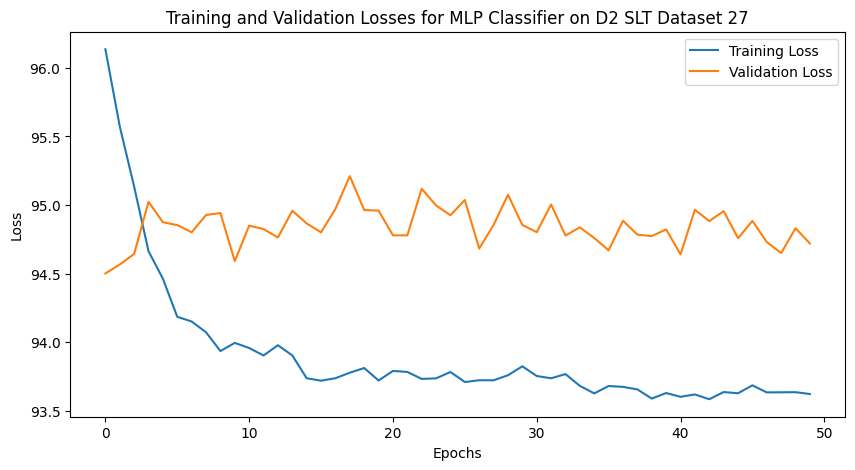

Test Loss: 79.6841, Test Accuracy: 0.7600, AUROC: 0.6407
Training on D2 SLT Dataset 28/32
Epoch 1/50, Training Loss: 96.1062, Validation Loss: 94.5537, Training Accuracy: 0.7278
Epoch 10/50, Training Loss: 94.0141, Validation Loss: 94.6292, Training Accuracy: 0.9597
Epoch 20/50, Training Loss: 93.7654, Validation Loss: 94.7213, Training Accuracy: 0.9750
Epoch 30/50, Training Loss: 93.6506, Validation Loss: 94.7835, Training Accuracy: 0.9875
Epoch 40/50, Training Loss: 93.6761, Validation Loss: 94.7524, Training Accuracy: 0.9868
Epoch 50/50, Training Loss: 93.6235, Validation Loss: 94.6644, Training Accuracy: 0.9882


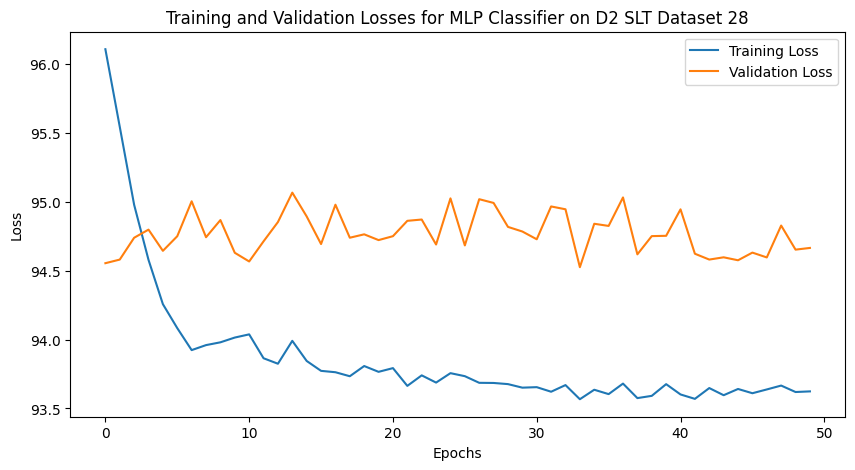

Test Loss: 79.4500, Test Accuracy: 0.7850, AUROC: 0.6664
Training on D2 SLT Dataset 29/32
Epoch 1/50, Training Loss: 96.1990, Validation Loss: 94.5102, Training Accuracy: 0.5736
Epoch 10/50, Training Loss: 93.9335, Validation Loss: 94.7433, Training Accuracy: 0.9632
Epoch 20/50, Training Loss: 93.6739, Validation Loss: 94.7198, Training Accuracy: 0.9854
Epoch 30/50, Training Loss: 93.7041, Validation Loss: 94.7444, Training Accuracy: 0.9854
Epoch 40/50, Training Loss: 93.6536, Validation Loss: 94.8630, Training Accuracy: 0.9868
Epoch 50/50, Training Loss: 93.6326, Validation Loss: 94.8079, Training Accuracy: 0.9882


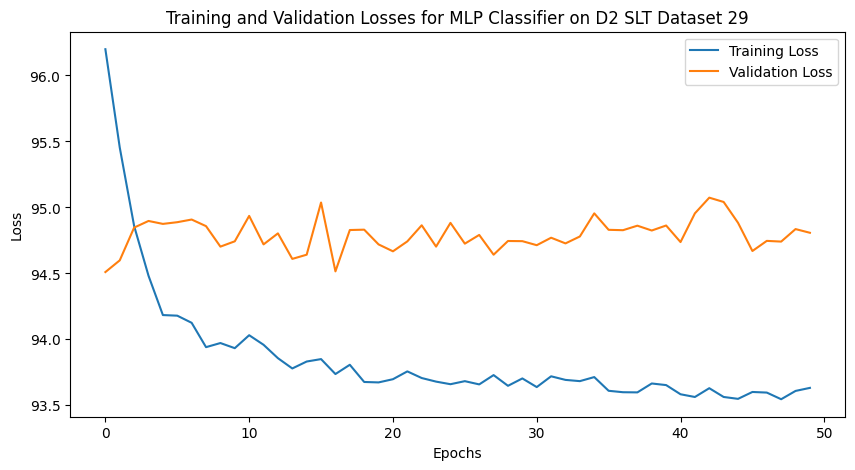

Test Loss: 79.3622, Test Accuracy: 0.7900, AUROC: 0.6767
Training on D2 SLT Dataset 30/32
Epoch 1/50, Training Loss: 96.1436, Validation Loss: 94.7751, Training Accuracy: 0.5611
Epoch 10/50, Training Loss: 93.9100, Validation Loss: 94.7588, Training Accuracy: 0.9674
Epoch 20/50, Training Loss: 93.7677, Validation Loss: 94.6576, Training Accuracy: 0.9750
Epoch 30/50, Training Loss: 93.6883, Validation Loss: 94.8158, Training Accuracy: 0.9819
Epoch 40/50, Training Loss: 93.6070, Validation Loss: 94.6157, Training Accuracy: 0.9924
Epoch 50/50, Training Loss: 93.5723, Validation Loss: 94.6876, Training Accuracy: 0.9917


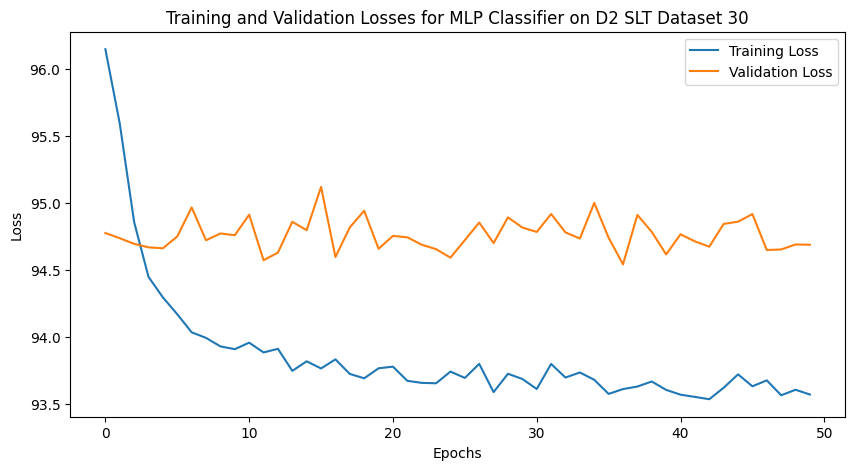

Test Loss: 79.5489, Test Accuracy: 0.7700, AUROC: 0.6451
Training on D2 SLT Dataset 31/32
Epoch 1/50, Training Loss: 96.1113, Validation Loss: 94.6430, Training Accuracy: 0.5674
Epoch 10/50, Training Loss: 93.9596, Validation Loss: 95.1860, Training Accuracy: 0.9646
Epoch 20/50, Training Loss: 93.7387, Validation Loss: 94.8202, Training Accuracy: 0.9812
Epoch 30/50, Training Loss: 93.6773, Validation Loss: 95.0092, Training Accuracy: 0.9840
Epoch 40/50, Training Loss: 93.6139, Validation Loss: 94.7451, Training Accuracy: 0.9889
Epoch 50/50, Training Loss: 93.5823, Validation Loss: 94.9297, Training Accuracy: 0.9903


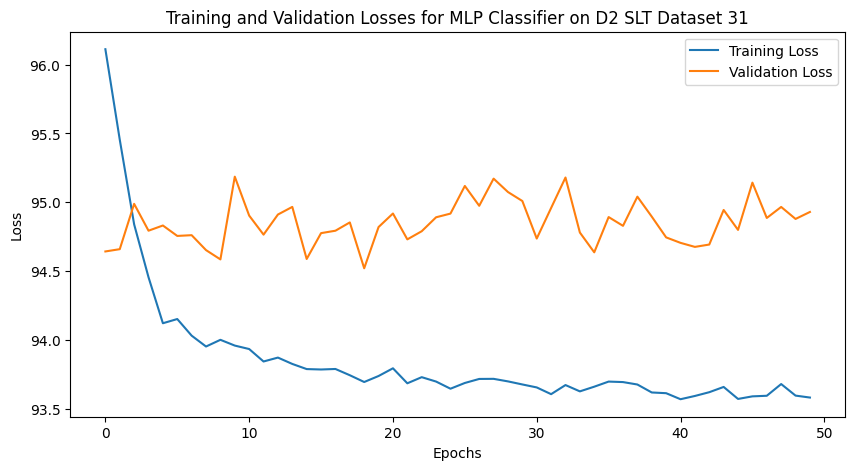

Test Loss: 79.2363, Test Accuracy: 0.7950, AUROC: 0.6138
Training on D2 SLT Dataset 32/32
Epoch 1/50, Training Loss: 96.0188, Validation Loss: 94.6536, Training Accuracy: 0.6139
Epoch 10/50, Training Loss: 94.1526, Validation Loss: 94.6575, Training Accuracy: 0.9521
Epoch 20/50, Training Loss: 93.8121, Validation Loss: 94.9587, Training Accuracy: 0.9771
Epoch 30/50, Training Loss: 93.6003, Validation Loss: 94.8725, Training Accuracy: 0.9917
Epoch 40/50, Training Loss: 93.7303, Validation Loss: 94.8958, Training Accuracy: 0.9799
Epoch 50/50, Training Loss: 93.6075, Validation Loss: 94.8207, Training Accuracy: 0.9896


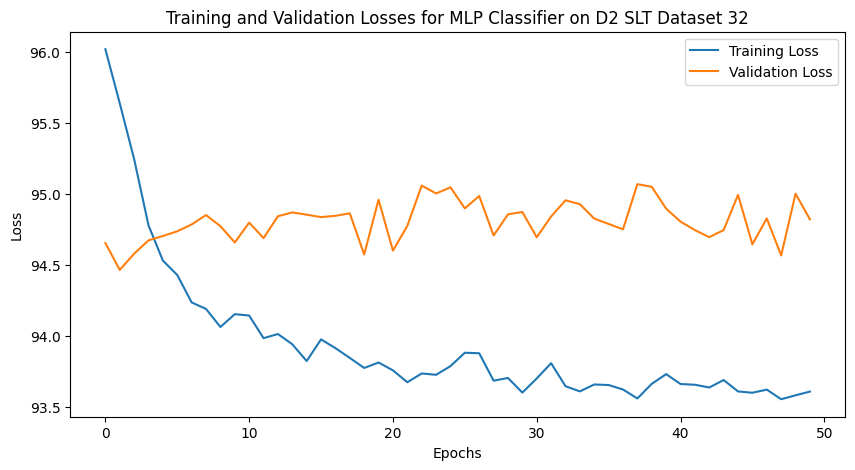

Test Loss: 79.3473, Test Accuracy: 0.7950, AUROC: 0.6647


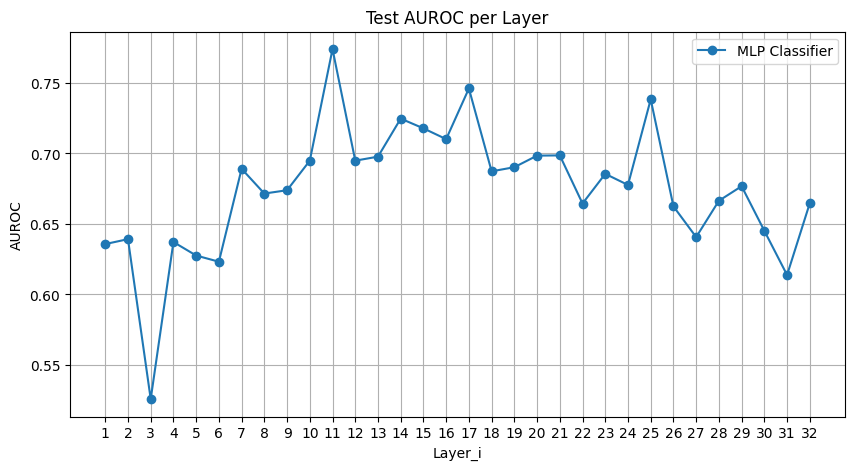

In [185]:
# Training with MLP.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4096   # Token embedding dimensions
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50
smlpa_test_accs = []
smlpa_test_aucs = []

for i, (train_loader, valid_loader, test_loader) in enumerate(zip(d2a_slt_train_dataloaders, d2a_slt_valid_dataloaders, d2a_slt_test_dataloaders)):
    print(f"Training on D2 SLT Dataset {i+1}/{len(d2a_slt_train_dataloaders)}")
    model = MLPClassifier(in_dim, hid_dims, dropout)
    train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on D2 SLT Dataset {i+1}", silent=False)
    test_loss, test_acc, test_auc = evaluate_on_test(model, test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    smlpa_test_accs.append(test_acc)
    smlpa_test_aucs.append(test_auc)

# plot_1d_metrics([smlpa_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([smlpa_test_aucs], ['MLP Classifier'], 'AUROC')

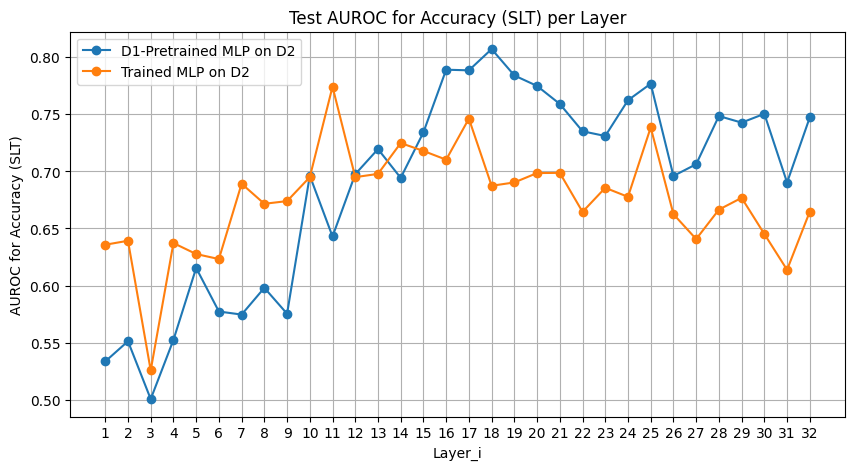

In [186]:
# Comparison with using pretrained model on D1 for prediction on D2
plot_1d_metrics([smlp2a_test_aucs, smlpa_test_aucs], ['D1-Pretrained MLP on D2', 'Trained MLP on D2'], 'AUROC for Accuracy (SLT)')

### Use model trained on [D1, D2] to predict D3

We will load another dataset D3 and continually train our models on D2 binarized SE values, before testing on D3 accuracy scores.

<!-- We choose LLaMA-2-7B's generations on NQ dataset (2k samples) as D3. -->

D3 is temporarily defined as generations by LLaMA-2-7B on svamp dataset (only 300 samples).

In [273]:
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb/run-20240423_174253-i6ivr4oy/files')  # path for llama2-7b on svamp (300)
# os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb/run-20240423_194941-rl1zb0ly/files')  # path for llama2-7b on med_qa (400)  # not really useful - semantic entropy scores are mostly zero
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
d3_generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
d3_measures = pickle.load(g)
g.close()

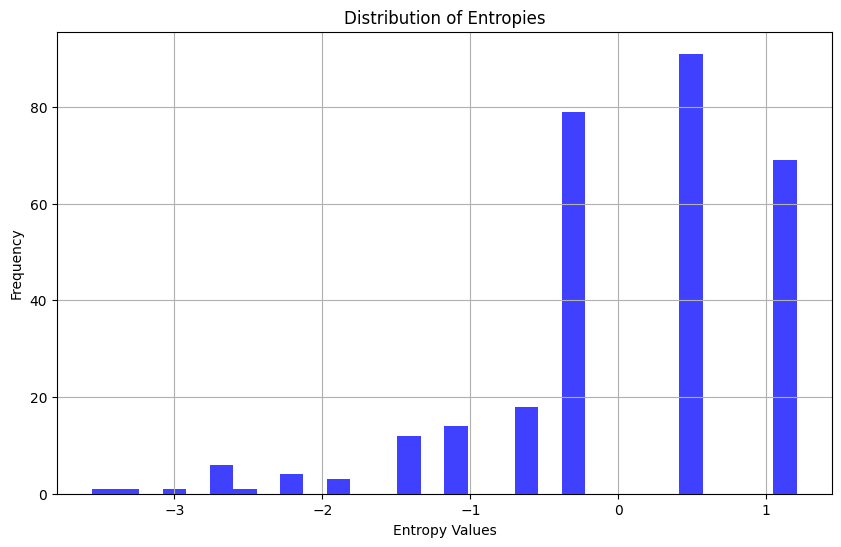

Dummy entropy: 0.5333
Dummy accuracy: 0.9733


In [274]:
# Data extraction and preprocessing.
d3_entropy = torch.tensor(d3_measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)
d3_tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in d3_generations.values()]).squeeze(-2).to(torch.float32)
d3_ca_entropy = d3_entropy.to(torch.float32)
mean = d3_ca_entropy.mean()
std = d3_ca_entropy.std()
d3_ca_entropy = (d3_ca_entropy - mean) / std

d3_tok_bef_gen_layered_datasets = d3_tok_bef_gen_dataset.transpose(0, 1)
plot_entropy_distribution(d3_ca_entropy)
d3_bca_entropy = binarize_entropy(d3_ca_entropy, 0.0)
print(f"Dummy entropy: {sum(d3_bca_entropy)/len(d3_bca_entropy):.4f}")

d3_sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in d3_generations.values()]).squeeze(-2).to(torch.float32)
d3_slt_layered_datasets = d3_sec_last_tok_dataset.transpose(0, 1)[1:]
d3_accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in d3_generations.values()])
print(f"Dummy accuracy: {max(torch.mean(d3_accuracies), 1-torch.mean(d3_accuracies)):.4f}")

We can see that it has very high dummy accuracy, or LLM has made very accurate responses to the questions from svamp.

In [234]:
d2b_tbg_train_dataloaders, d2b_tbg_valid_dataloaders, d2b_tbg_test_dataloaders = create_dataloaders(d2_tok_bef_gen_layered_datasets, d2_bca_entropy, total_size, batch_size, set_seed=True)
d2b_X_trains, d2b_X_vals, d2b_X_tests, d2b_y_trains, d2b_y_vals, d2b_y_tests = create_Xs_and_ys(d2_tok_bef_gen_layered_datasets, d2_bca_entropy, total_size)

Training on D2 TBG Dataset 1/33
Validation Accuracy: 0.6472, AUROC: 0.6191
Training Loss: 0.5547, Validation Loss: 0.6255
Test Loss: 0.6625, Test Accuracy: 0.5800, AUROC: 0.6055
Training on D2 TBG Dataset 2/33
Validation Accuracy: 0.6472, AUROC: 0.6584
Training Loss: 0.5011, Validation Loss: 0.6107
Test Loss: 0.6606, Test Accuracy: 0.5950, AUROC: 0.6221
Training on D2 TBG Dataset 3/33
Validation Accuracy: 0.6556, AUROC: 0.6893
Training Loss: 0.4177, Validation Loss: 0.5960
Test Loss: 0.6568, Test Accuracy: 0.6250, AUROC: 0.6732
Training on D2 TBG Dataset 4/33
Validation Accuracy: 0.6722, AUROC: 0.7095
Training Loss: 0.3494, Validation Loss: 0.6008
Test Loss: 0.6768, Test Accuracy: 0.6400, AUROC: 0.6832
Training on D2 TBG Dataset 5/33
Validation Accuracy: 0.7111, AUROC: 0.7215
Training Loss: 0.3013, Validation Loss: 0.6347
Test Loss: 0.6743, Test Accuracy: 0.6500, AUROC: 0.7064
Training on D2 TBG Dataset 6/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6556, AUROC: 0.6999
Training Loss: 0.2509, Validation Loss: 0.6728
Test Loss: 0.7029, Test Accuracy: 0.6700, AUROC: 0.7100
Training on D2 TBG Dataset 7/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7000, AUROC: 0.7251
Training Loss: 0.1931, Validation Loss: 0.6772
Test Loss: 0.7653, Test Accuracy: 0.6700, AUROC: 0.7079
Training on D2 TBG Dataset 8/33


...

Validation Accuracy: 0.6833, AUROC: 0.7343
Training Loss: 0.0025, Validation Loss: 1.4717
Test Loss: 1.7245, Test Accuracy: 0.5700, AUROC: 0.6654
Training on D2 TBG Dataset 32/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6917, AUROC: 0.7437
Training Loss: 0.0022, Validation Loss: 1.4900
Test Loss: 1.7057, Test Accuracy: 0.6050, AUROC: 0.6825
Training on D2 TBG Dataset 33/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6806, AUROC: 0.7425
Training Loss: 0.0018, Validation Loss: 1.4220
Test Loss: 1.5336, Test Accuracy: 0.6250, AUROC: 0.6912


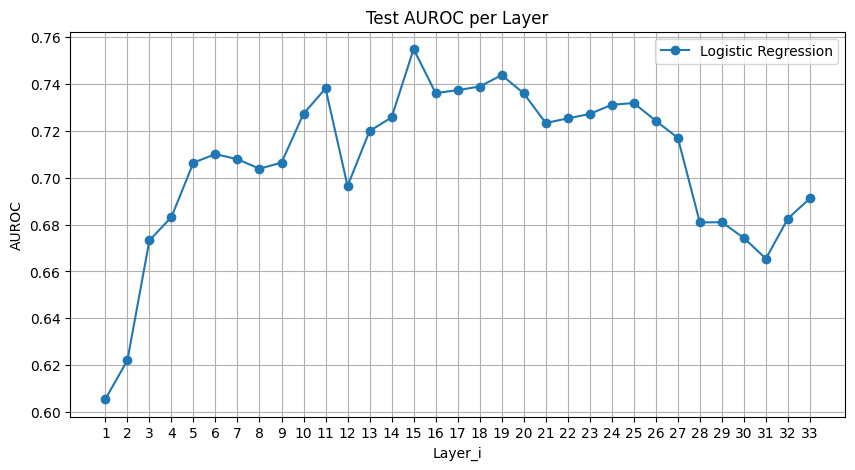

In [235]:
# Continual Training Loops (LR)
from sklearn.base import clone

tablr2_test_accs = []
tablr2_test_aucs = []
tablr2_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(d2b_X_trains, d2b_X_vals, d2b_X_tests, d2b_y_trains, d2b_y_vals, d2b_y_tests)):
    print(f"Training on D2 TBG Dataset {i+1}/{len(X_trains)}")
    model = clone(tablr_trained_models[i])
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on D2 TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tablr2_test_accs.append(test_acc)
    tablr2_test_aucs.append(test_auc)
    tablr2_trained_models.append(model)

# plot_1d_metrics([tablr2_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tablr2_test_aucs], ['Logistic Regression'], 'AUROC')

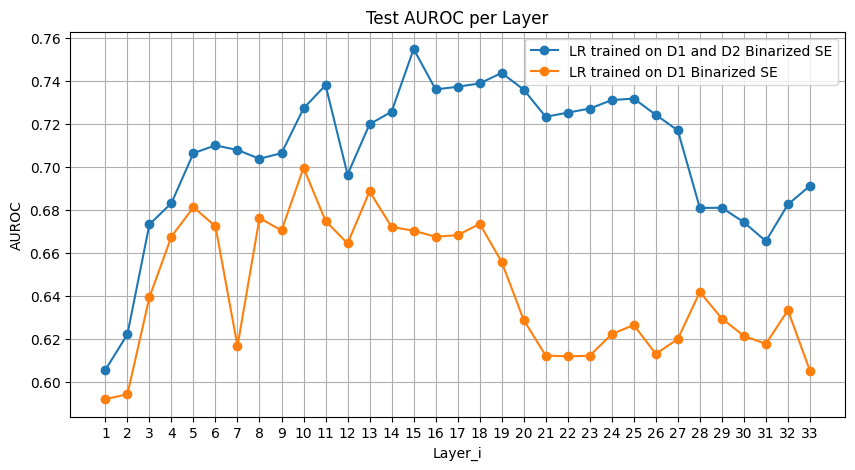

In [260]:
plot_1d_metrics([tablr2_test_aucs, tlr2b_test_aucs], ['LR trained on D1 and D2 Binarized SE', 'LR trained on D1 Binarized SE'], 'AUROC')

Using device: cuda
Training on D2 TBG Dataset 1/33
Epoch 1/50, Training Loss: 70.2028, Validation Loss: 72.2516, Training Accuracy: 0.5597
Epoch 10/50, Training Loss: 67.0249, Validation Loss: 71.1413, Training Accuracy: 0.7889
Epoch 20/50, Training Loss: 66.8524, Validation Loss: 71.1430, Training Accuracy: 0.7910
Epoch 30/50, Training Loss: 66.8601, Validation Loss: 71.1237, Training Accuracy: 0.8021
Epoch 40/50, Training Loss: 66.9424, Validation Loss: 71.4095, Training Accuracy: 0.7917
Epoch 50/50, Training Loss: 66.7906, Validation Loss: 71.0391, Training Accuracy: 0.8042


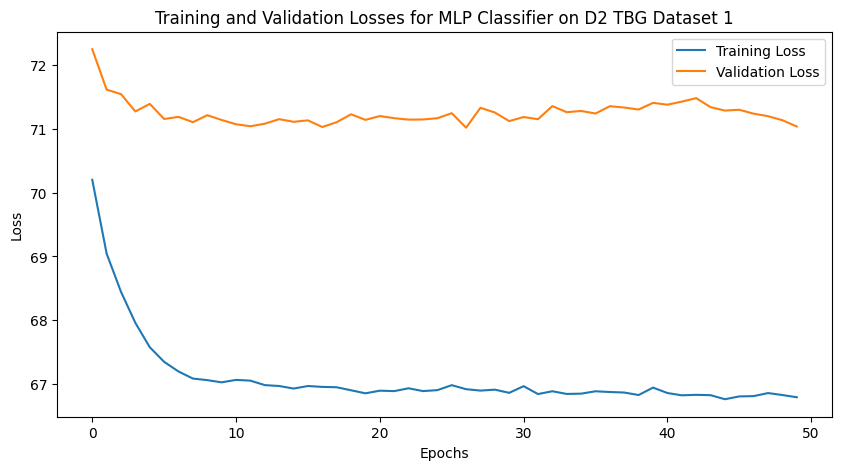

Test Loss: 57.5204, Test Accuracy: 0.5950, AUROC: 0.5309
Training on D2 TBG Dataset 2/33
Epoch 1/50, Training Loss: 70.1582, Validation Loss: 71.6325, Training Accuracy: 0.5750
Epoch 10/50, Training Loss: 67.1142, Validation Loss: 70.7493, Training Accuracy: 0.7792
Epoch 20/50, Training Loss: 66.8748, Validation Loss: 70.7766, Training Accuracy: 0.7931
Epoch 30/50, Training Loss: 66.7934, Validation Loss: 70.8320, Training Accuracy: 0.7993
Epoch 40/50, Training Loss: 66.7774, Validation Loss: 70.5696, Training Accuracy: 0.7972
Epoch 50/50, Training Loss: 66.7894, Validation Loss: 70.6764, Training Accuracy: 0.8007


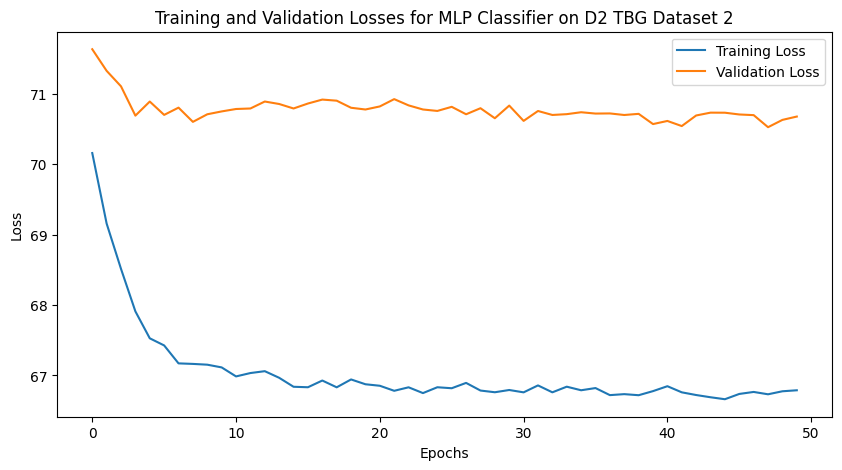

Test Loss: 56.8485, Test Accuracy: 0.6300, AUROC: 0.6570
Training on D2 TBG Dataset 3/33
Epoch 1/50, Training Loss: 70.0582, Validation Loss: 71.3054, Training Accuracy: 0.5826
Epoch 10/50, Training Loss: 66.8004, Validation Loss: 70.5702, Training Accuracy: 0.7979
Epoch 20/50, Training Loss: 66.4131, Validation Loss: 70.4757, Training Accuracy: 0.8278
Epoch 30/50, Training Loss: 66.3613, Validation Loss: 70.5703, Training Accuracy: 0.8299
Epoch 40/50, Training Loss: 66.3187, Validation Loss: 70.4274, Training Accuracy: 0.8354
Epoch 50/50, Training Loss: 66.3885, Validation Loss: 70.3370, Training Accuracy: 0.8271


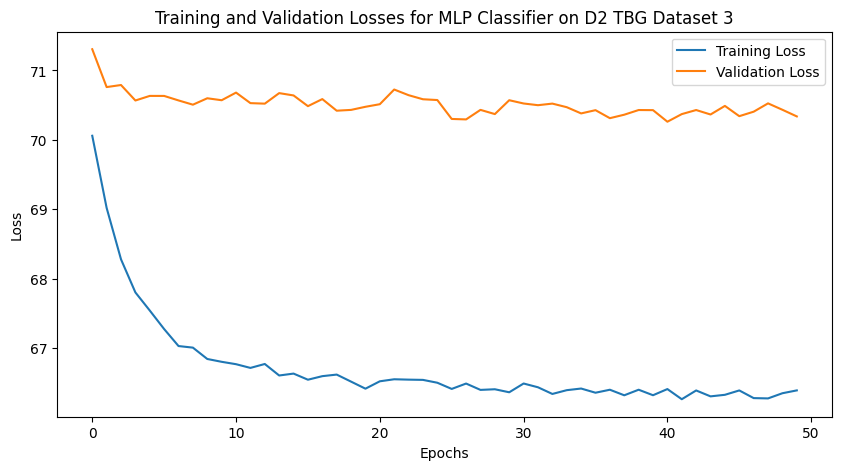

Test Loss: 57.0781, Test Accuracy: 0.6200, AUROC: 0.6214
Training on D2 TBG Dataset 4/33
Epoch 1/50, Training Loss: 70.2447, Validation Loss: 71.5237, Training Accuracy: 0.5500
Epoch 10/50, Training Loss: 66.7122, Validation Loss: 70.5203, Training Accuracy: 0.8097
Epoch 20/50, Training Loss: 66.3743, Validation Loss: 70.6066, Training Accuracy: 0.8264
Epoch 30/50, Training Loss: 66.1801, Validation Loss: 70.7357, Training Accuracy: 0.8403
Epoch 40/50, Training Loss: 66.2681, Validation Loss: 70.5909, Training Accuracy: 0.8410
Epoch 50/50, Training Loss: 66.1451, Validation Loss: 70.6310, Training Accuracy: 0.8451


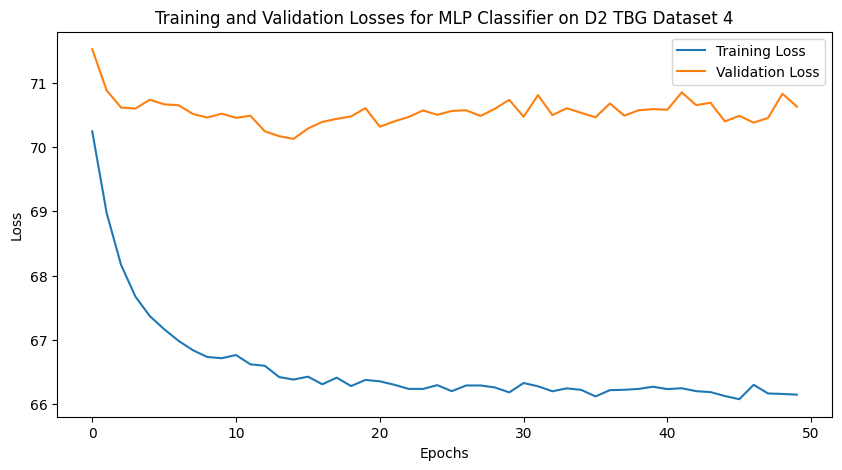

Test Loss: 56.9654, Test Accuracy: 0.6250, AUROC: 0.6326
Training on D2 TBG Dataset 5/33
Epoch 1/50, Training Loss: 69.9332, Validation Loss: 70.7719, Training Accuracy: 0.5840
Epoch 10/50, Training Loss: 66.6430, Validation Loss: 70.9547, Training Accuracy: 0.8160
Epoch 20/50, Training Loss: 66.4602, Validation Loss: 71.0531, Training Accuracy: 0.8229
Epoch 30/50, Training Loss: 66.2170, Validation Loss: 70.5863, Training Accuracy: 0.8313
Epoch 40/50, Training Loss: 66.0966, Validation Loss: 70.8012, Training Accuracy: 0.8417
Epoch 50/50, Training Loss: 66.0980, Validation Loss: 70.6139, Training Accuracy: 0.8472


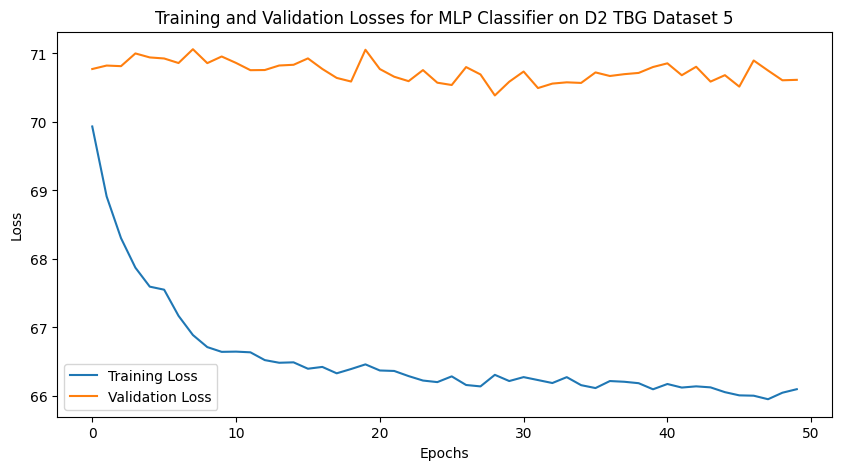

Test Loss: 57.0321, Test Accuracy: 0.6050, AUROC: 0.6658
Training on D2 TBG Dataset 6/33
Epoch 1/50, Training Loss: 70.1952, Validation Loss: 70.6543, Training Accuracy: 0.5785
Epoch 10/50, Training Loss: 66.7038, Validation Loss: 70.8094, Training Accuracy: 0.8118
Epoch 20/50, Training Loss: 66.2417, Validation Loss: 70.6800, Training Accuracy: 0.8389
Epoch 30/50, Training Loss: 65.9899, Validation Loss: 70.7847, Training Accuracy: 0.8583
Epoch 40/50, Training Loss: 65.8293, Validation Loss: 70.6731, Training Accuracy: 0.8674
Epoch 50/50, Training Loss: 65.6784, Validation Loss: 70.8786, Training Accuracy: 0.8861


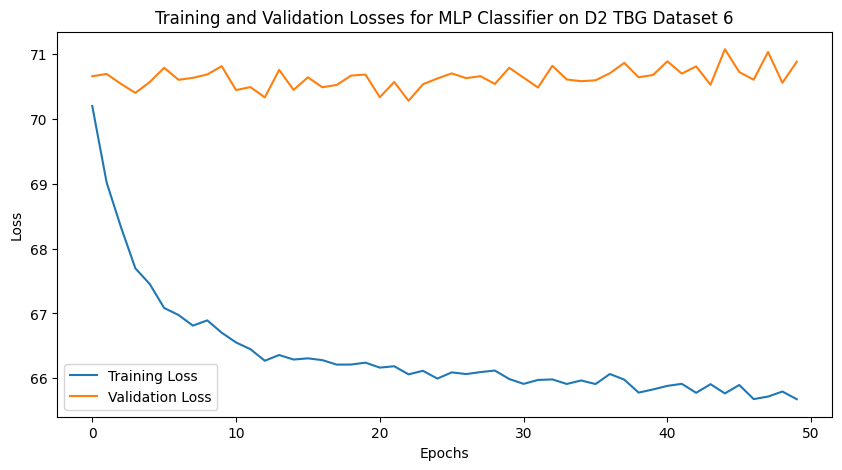

Test Loss: 56.8324, Test Accuracy: 0.6350, AUROC: 0.6501
Training on D2 TBG Dataset 7/33
Epoch 1/50, Training Loss: 69.9737, Validation Loss: 70.8152, Training Accuracy: 0.5972
Epoch 10/50, Training Loss: 66.8601, Validation Loss: 70.5666, Training Accuracy: 0.8049
Epoch 20/50, Training Loss: 66.0874, Validation Loss: 70.3801, Training Accuracy: 0.8542
Epoch 30/50, Training Loss: 65.8905, Validation Loss: 70.0574, Training Accuracy: 0.8722
Epoch 40/50, Training Loss: 65.6169, Validation Loss: 70.1970, Training Accuracy: 0.8910
Epoch 50/50, Training Loss: 65.5676, Validation Loss: 70.3083, Training Accuracy: 0.8979


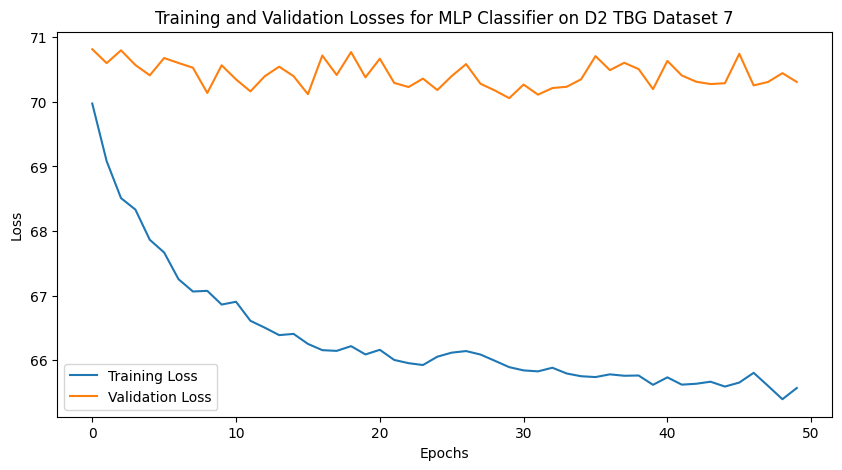

Test Loss: 55.9267, Test Accuracy: 0.7000, AUROC: 0.7063
Training on D2 TBG Dataset 8/33
Epoch 1/50, Training Loss: 69.7269, Validation Loss: 70.8578, Training Accuracy: 0.6125
Epoch 10/50, Training Loss: 67.0878, Validation Loss: 71.1417, Training Accuracy: 0.8014
Epoch 20/50, Training Loss: 66.0208, Validation Loss: 70.3333, Training Accuracy: 0.8604
Epoch 30/50, Training Loss: 65.8133, Validation Loss: 70.3776, Training Accuracy: 0.8854
Epoch 40/50, Training Loss: 65.3524, Validation Loss: 70.2755, Training Accuracy: 0.9097
Epoch 50/50, Training Loss: 65.3272, Validation Loss: 70.5665, Training Accuracy: 0.9132


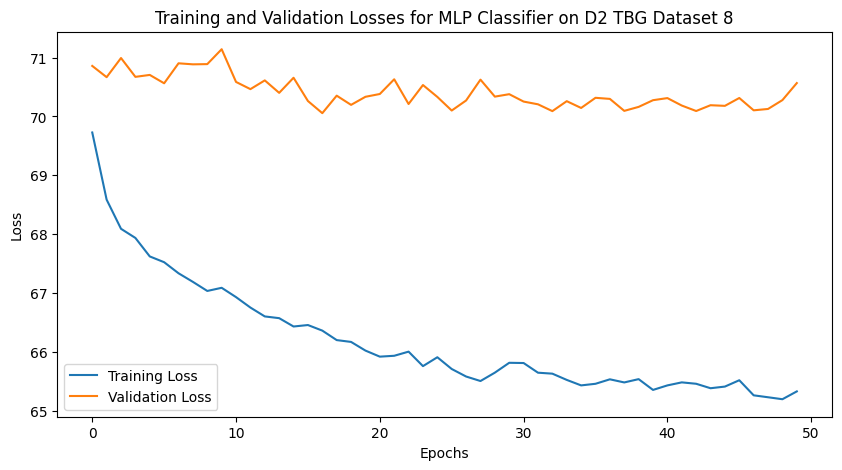

Test Loss: 56.0589, Test Accuracy: 0.7150, AUROC: 0.7207
Training on D2 TBG Dataset 9/33
Epoch 1/50, Training Loss: 69.9956, Validation Loss: 70.8674, Training Accuracy: 0.5861
Epoch 10/50, Training Loss: 66.3611, Validation Loss: 70.3060, Training Accuracy: 0.8375
Epoch 20/50, Training Loss: 65.6203, Validation Loss: 70.1415, Training Accuracy: 0.8889
Epoch 30/50, Training Loss: 65.3568, Validation Loss: 70.4040, Training Accuracy: 0.9069
Epoch 40/50, Training Loss: 65.1382, Validation Loss: 70.4474, Training Accuracy: 0.9243
Epoch 50/50, Training Loss: 64.9692, Validation Loss: 70.2319, Training Accuracy: 0.9333


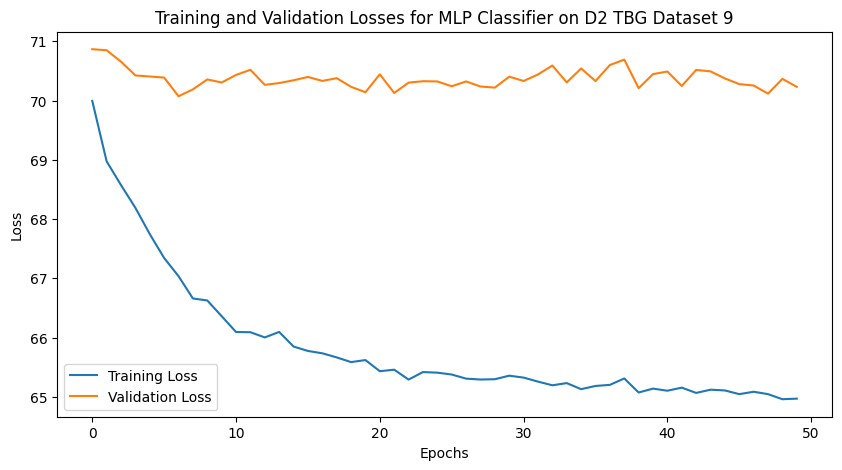

Test Loss: 55.4816, Test Accuracy: 0.7400, AUROC: 0.7806
Training on D2 TBG Dataset 10/33
Epoch 1/50, Training Loss: 69.7243, Validation Loss: 70.5897, Training Accuracy: 0.6139
Epoch 10/50, Training Loss: 66.6576, Validation Loss: 70.2776, Training Accuracy: 0.8222
Epoch 20/50, Training Loss: 65.4331, Validation Loss: 70.3170, Training Accuracy: 0.9035
Epoch 30/50, Training Loss: 65.2912, Validation Loss: 70.2700, Training Accuracy: 0.9118
Epoch 40/50, Training Loss: 65.3045, Validation Loss: 70.5018, Training Accuracy: 0.9181
Epoch 50/50, Training Loss: 65.0731, Validation Loss: 70.0561, Training Accuracy: 0.9326


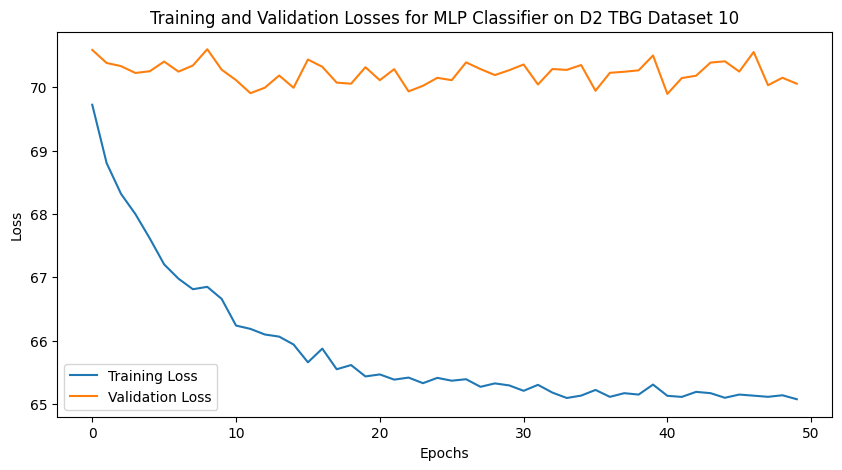

Test Loss: 56.0098, Test Accuracy: 0.7000, AUROC: 0.7430
Training on D2 TBG Dataset 11/33
Epoch 1/50, Training Loss: 69.5749, Validation Loss: 70.7972, Training Accuracy: 0.6181
Epoch 10/50, Training Loss: 66.2063, Validation Loss: 69.9774, Training Accuracy: 0.8597
Epoch 20/50, Training Loss: 65.4039, Validation Loss: 69.6192, Training Accuracy: 0.9062
Epoch 30/50, Training Loss: 65.1621, Validation Loss: 70.1109, Training Accuracy: 0.9250
Epoch 40/50, Training Loss: 64.8930, Validation Loss: 70.2738, Training Accuracy: 0.9437
Epoch 50/50, Training Loss: 64.9497, Validation Loss: 70.0023, Training Accuracy: 0.9417


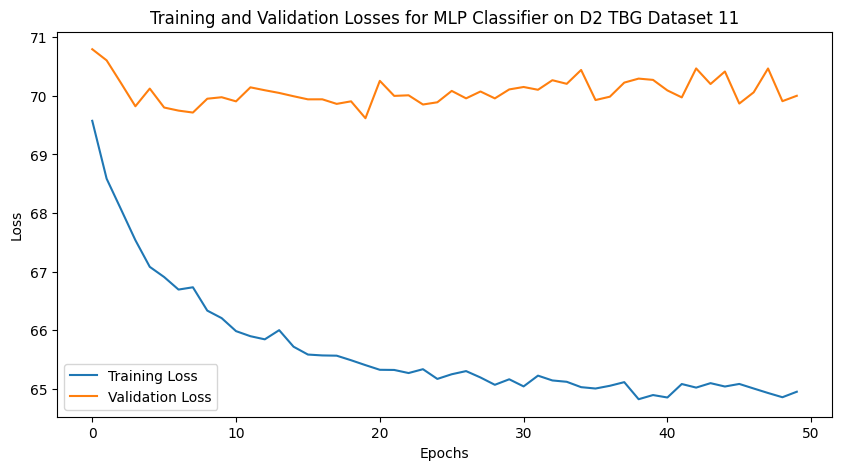

Test Loss: 56.5897, Test Accuracy: 0.6750, AUROC: 0.7172
Training on D2 TBG Dataset 12/33
Epoch 1/50, Training Loss: 69.4380, Validation Loss: 70.2411, Training Accuracy: 0.6271
Epoch 10/50, Training Loss: 66.3879, Validation Loss: 70.0731, Training Accuracy: 0.8396
Epoch 20/50, Training Loss: 65.5249, Validation Loss: 69.9746, Training Accuracy: 0.8986
Epoch 30/50, Training Loss: 65.0146, Validation Loss: 69.9671, Training Accuracy: 0.9333
Epoch 40/50, Training Loss: 65.0399, Validation Loss: 69.8203, Training Accuracy: 0.9299
Epoch 50/50, Training Loss: 64.8417, Validation Loss: 69.9912, Training Accuracy: 0.9431


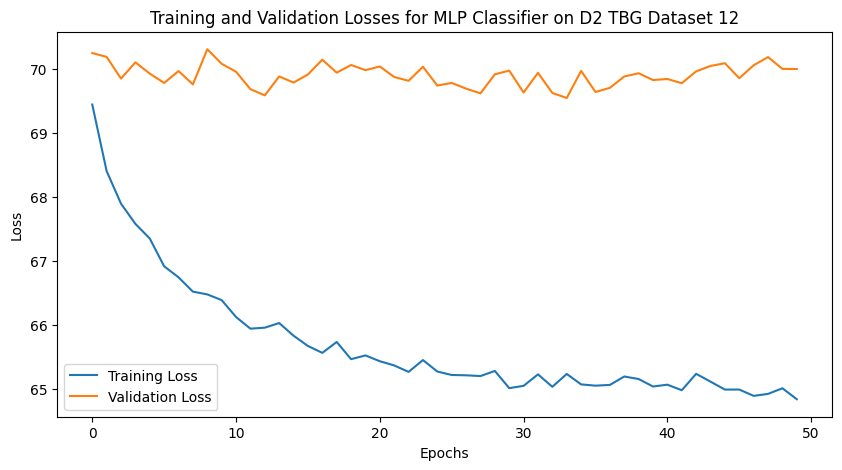

Test Loss: 55.2326, Test Accuracy: 0.7750, AUROC: 0.7869
Training on D2 TBG Dataset 13/33
Epoch 1/50, Training Loss: 69.7825, Validation Loss: 70.5967, Training Accuracy: 0.6125
Epoch 10/50, Training Loss: 65.8445, Validation Loss: 69.7986, Training Accuracy: 0.8792
Epoch 20/50, Training Loss: 65.2526, Validation Loss: 69.6088, Training Accuracy: 0.9201
Epoch 30/50, Training Loss: 64.8433, Validation Loss: 69.3862, Training Accuracy: 0.9458
Epoch 40/50, Training Loss: 64.7738, Validation Loss: 69.5445, Training Accuracy: 0.9514
Epoch 50/50, Training Loss: 64.7384, Validation Loss: 69.6012, Training Accuracy: 0.9528


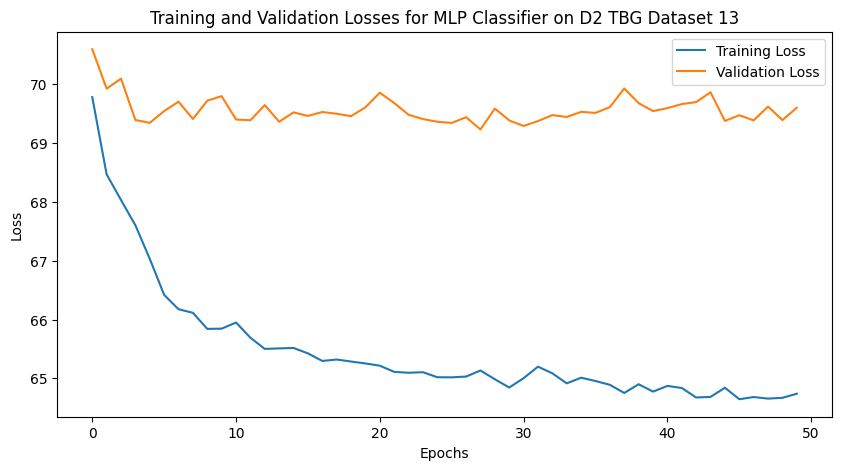

Test Loss: 56.2583, Test Accuracy: 0.6950, AUROC: 0.7783
Training on D2 TBG Dataset 14/33
Epoch 1/50, Training Loss: 69.3038, Validation Loss: 70.3579, Training Accuracy: 0.6444
Epoch 10/50, Training Loss: 65.9615, Validation Loss: 69.9010, Training Accuracy: 0.8722
Epoch 20/50, Training Loss: 65.3155, Validation Loss: 69.8706, Training Accuracy: 0.9167
Epoch 30/50, Training Loss: 64.8761, Validation Loss: 69.7823, Training Accuracy: 0.9424
Epoch 40/50, Training Loss: 64.6854, Validation Loss: 69.5795, Training Accuracy: 0.9549
Epoch 50/50, Training Loss: 64.6339, Validation Loss: 69.7032, Training Accuracy: 0.9590


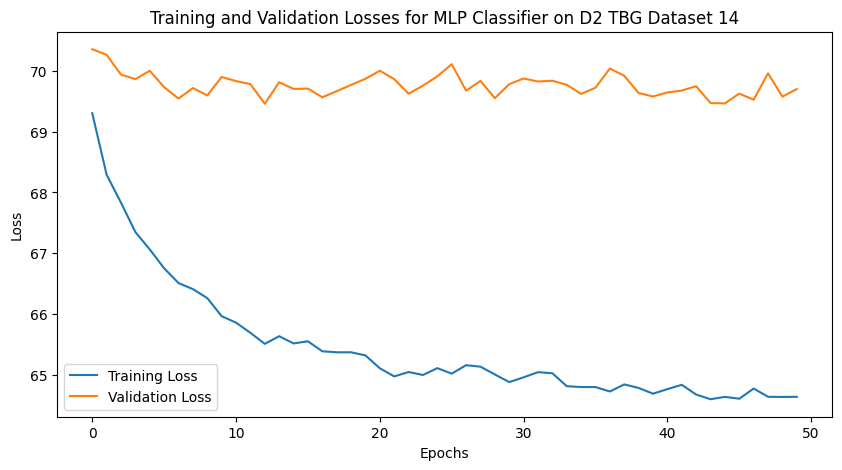

Test Loss: 55.8657, Test Accuracy: 0.7150, AUROC: 0.7447
Training on D2 TBG Dataset 15/33
Epoch 1/50, Training Loss: 69.1907, Validation Loss: 70.5957, Training Accuracy: 0.6528
Epoch 10/50, Training Loss: 65.9472, Validation Loss: 69.6068, Training Accuracy: 0.8750
Epoch 20/50, Training Loss: 65.1829, Validation Loss: 69.3553, Training Accuracy: 0.9257
Epoch 30/50, Training Loss: 64.9687, Validation Loss: 69.3799, Training Accuracy: 0.9375
Epoch 40/50, Training Loss: 64.6605, Validation Loss: 69.8334, Training Accuracy: 0.9604
Epoch 50/50, Training Loss: 64.5799, Validation Loss: 69.9725, Training Accuracy: 0.9632


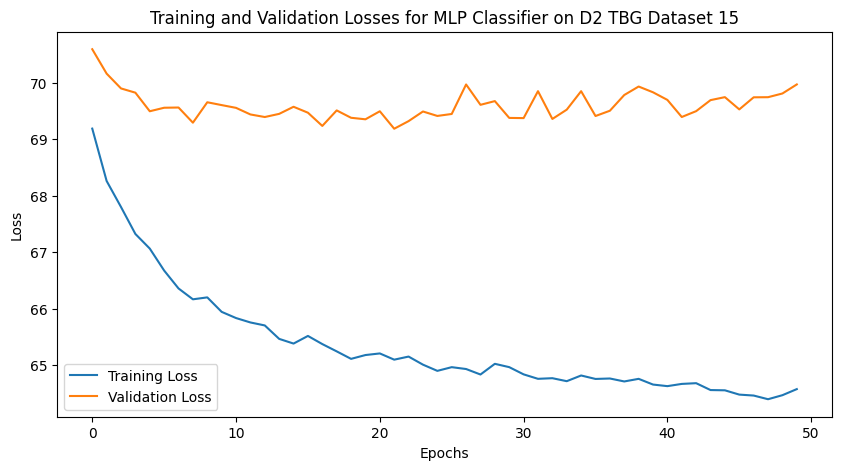

Test Loss: 55.9699, Test Accuracy: 0.7150, AUROC: 0.7621
Training on D2 TBG Dataset 16/33
Epoch 1/50, Training Loss: 69.1977, Validation Loss: 70.3162, Training Accuracy: 0.6493
Epoch 10/50, Training Loss: 65.4598, Validation Loss: 69.8923, Training Accuracy: 0.9069
Epoch 20/50, Training Loss: 65.1830, Validation Loss: 69.9375, Training Accuracy: 0.9271
Epoch 30/50, Training Loss: 64.7743, Validation Loss: 69.6208, Training Accuracy: 0.9521
Epoch 40/50, Training Loss: 64.5867, Validation Loss: 69.6062, Training Accuracy: 0.9625
Epoch 50/50, Training Loss: 64.6456, Validation Loss: 70.0686, Training Accuracy: 0.9590


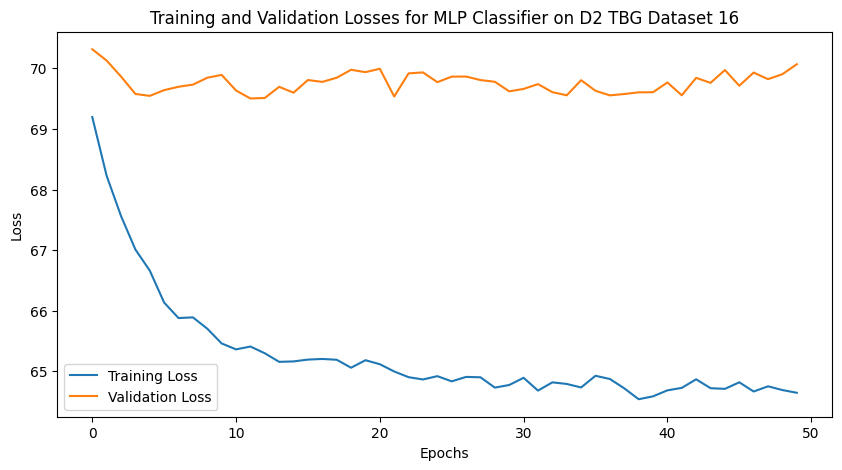

Test Loss: 55.5075, Test Accuracy: 0.7400, AUROC: 0.8049
Training on D2 TBG Dataset 17/33
Epoch 1/50, Training Loss: 69.1140, Validation Loss: 70.4390, Training Accuracy: 0.6597
Epoch 10/50, Training Loss: 65.7945, Validation Loss: 69.7083, Training Accuracy: 0.8833
Epoch 20/50, Training Loss: 65.2228, Validation Loss: 69.7986, Training Accuracy: 0.9215
Epoch 30/50, Training Loss: 64.8015, Validation Loss: 70.0138, Training Accuracy: 0.9472
Epoch 40/50, Training Loss: 64.6609, Validation Loss: 69.7009, Training Accuracy: 0.9618
Epoch 50/50, Training Loss: 64.6270, Validation Loss: 69.6367, Training Accuracy: 0.9618


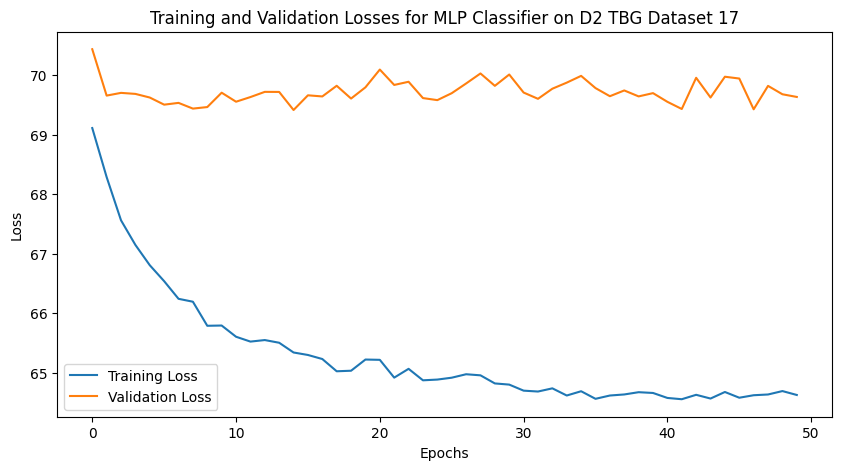

Test Loss: 55.6682, Test Accuracy: 0.7250, AUROC: 0.8056
Training on D2 TBG Dataset 18/33
Epoch 1/50, Training Loss: 69.6951, Validation Loss: 70.6887, Training Accuracy: 0.6076
Epoch 10/50, Training Loss: 65.6731, Validation Loss: 69.4712, Training Accuracy: 0.8917
Epoch 20/50, Training Loss: 65.1625, Validation Loss: 69.6903, Training Accuracy: 0.9285
Epoch 30/50, Training Loss: 65.0613, Validation Loss: 69.5875, Training Accuracy: 0.9361
Epoch 40/50, Training Loss: 64.6257, Validation Loss: 69.4430, Training Accuracy: 0.9590
Epoch 50/50, Training Loss: 64.6107, Validation Loss: 69.5936, Training Accuracy: 0.9625


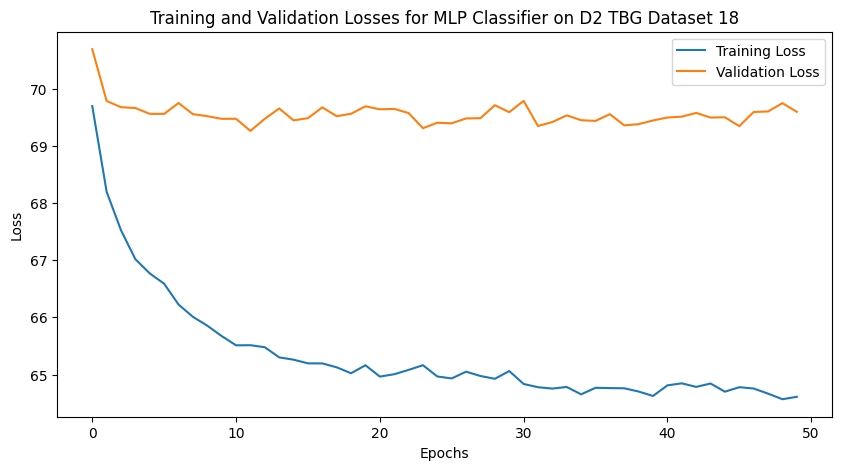

Test Loss: 56.2728, Test Accuracy: 0.6950, AUROC: 0.7581
Training on D2 TBG Dataset 19/33
Epoch 1/50, Training Loss: 69.2441, Validation Loss: 70.5381, Training Accuracy: 0.6486
Epoch 10/50, Training Loss: 65.5161, Validation Loss: 69.9345, Training Accuracy: 0.9021
Epoch 20/50, Training Loss: 65.2114, Validation Loss: 69.9861, Training Accuracy: 0.9222
Epoch 30/50, Training Loss: 64.7491, Validation Loss: 69.7418, Training Accuracy: 0.9507
Epoch 40/50, Training Loss: 64.7051, Validation Loss: 69.5917, Training Accuracy: 0.9563
Epoch 50/50, Training Loss: 64.6518, Validation Loss: 69.5472, Training Accuracy: 0.9604


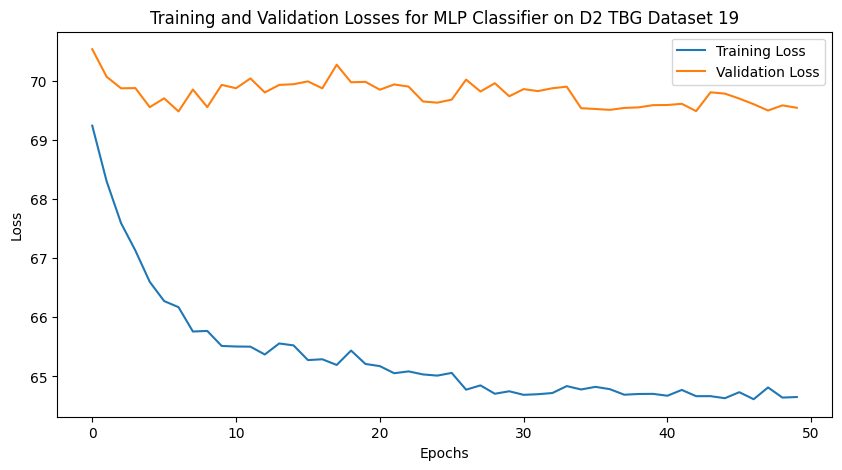

Test Loss: 55.9218, Test Accuracy: 0.7150, AUROC: 0.7597
Training on D2 TBG Dataset 20/33
Epoch 1/50, Training Loss: 69.6232, Validation Loss: 70.4011, Training Accuracy: 0.6257
Epoch 10/50, Training Loss: 65.6593, Validation Loss: 69.6335, Training Accuracy: 0.8931
Epoch 20/50, Training Loss: 65.3466, Validation Loss: 69.7837, Training Accuracy: 0.9153
Epoch 30/50, Training Loss: 64.7481, Validation Loss: 69.5158, Training Accuracy: 0.9535
Epoch 40/50, Training Loss: 64.7838, Validation Loss: 69.5076, Training Accuracy: 0.9535
Epoch 50/50, Training Loss: 64.7261, Validation Loss: 69.6611, Training Accuracy: 0.9528


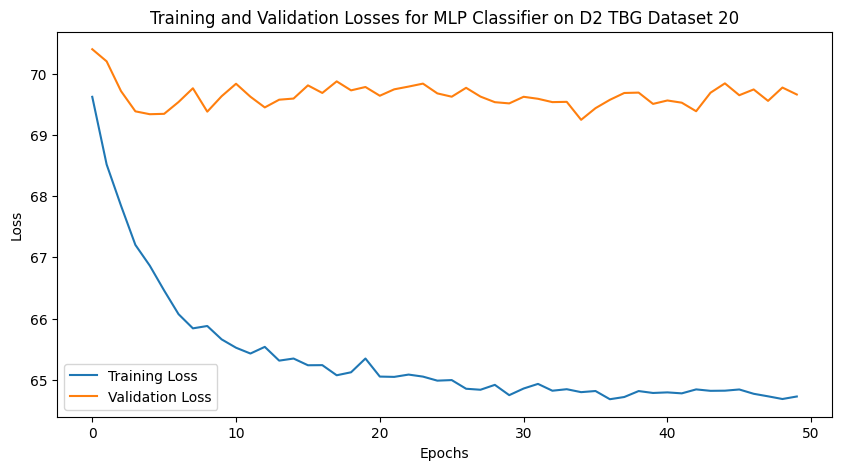

Test Loss: 55.8732, Test Accuracy: 0.7200, AUROC: 0.7600
Training on D2 TBG Dataset 21/33
Epoch 1/50, Training Loss: 69.6855, Validation Loss: 71.3419, Training Accuracy: 0.6153
Epoch 10/50, Training Loss: 65.5469, Validation Loss: 69.6478, Training Accuracy: 0.8986
Epoch 20/50, Training Loss: 65.0088, Validation Loss: 69.8240, Training Accuracy: 0.9347
Epoch 30/50, Training Loss: 64.7879, Validation Loss: 69.0593, Training Accuracy: 0.9514
Epoch 40/50, Training Loss: 64.5767, Validation Loss: 69.6616, Training Accuracy: 0.9618
Epoch 50/50, Training Loss: 64.6656, Validation Loss: 69.6167, Training Accuracy: 0.9611


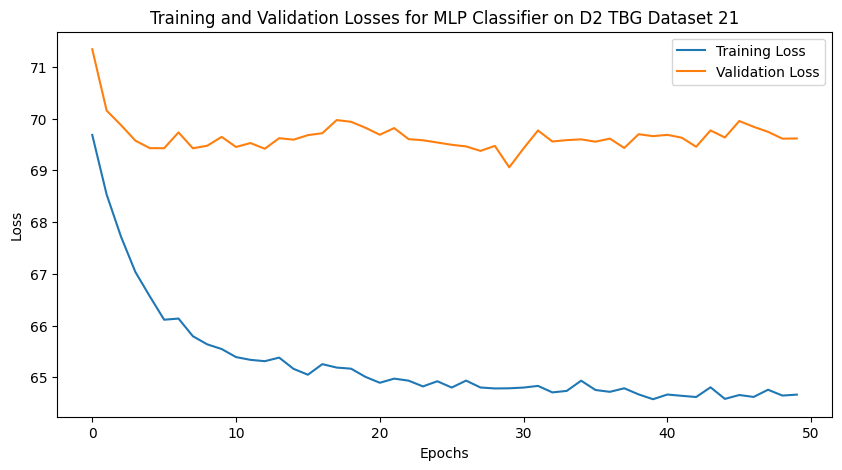

Test Loss: 56.1105, Test Accuracy: 0.7050, AUROC: 0.7492
Training on D2 TBG Dataset 22/33
Epoch 1/50, Training Loss: 69.7312, Validation Loss: 70.5743, Training Accuracy: 0.6167
Epoch 10/50, Training Loss: 65.5751, Validation Loss: 69.4898, Training Accuracy: 0.9000
Epoch 20/50, Training Loss: 64.9890, Validation Loss: 69.2099, Training Accuracy: 0.9368
Epoch 30/50, Training Loss: 64.8178, Validation Loss: 69.4204, Training Accuracy: 0.9507
Epoch 40/50, Training Loss: 64.7341, Validation Loss: 69.6920, Training Accuracy: 0.9549
Epoch 50/50, Training Loss: 64.6241, Validation Loss: 69.6003, Training Accuracy: 0.9611


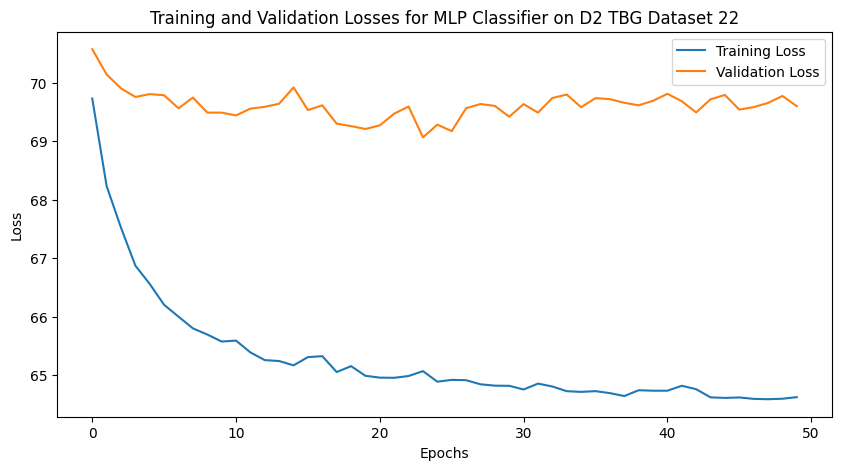

Test Loss: 55.9364, Test Accuracy: 0.7100, AUROC: 0.7688
Training on D2 TBG Dataset 23/33
Epoch 1/50, Training Loss: 69.8849, Validation Loss: 71.3682, Training Accuracy: 0.6000
Epoch 10/50, Training Loss: 65.4060, Validation Loss: 69.6935, Training Accuracy: 0.9097
Epoch 20/50, Training Loss: 65.0215, Validation Loss: 69.7269, Training Accuracy: 0.9361
Epoch 30/50, Training Loss: 64.7191, Validation Loss: 69.5811, Training Accuracy: 0.9535
Epoch 40/50, Training Loss: 64.6750, Validation Loss: 69.5763, Training Accuracy: 0.9604
Epoch 50/50, Training Loss: 64.6429, Validation Loss: 69.9178, Training Accuracy: 0.9611


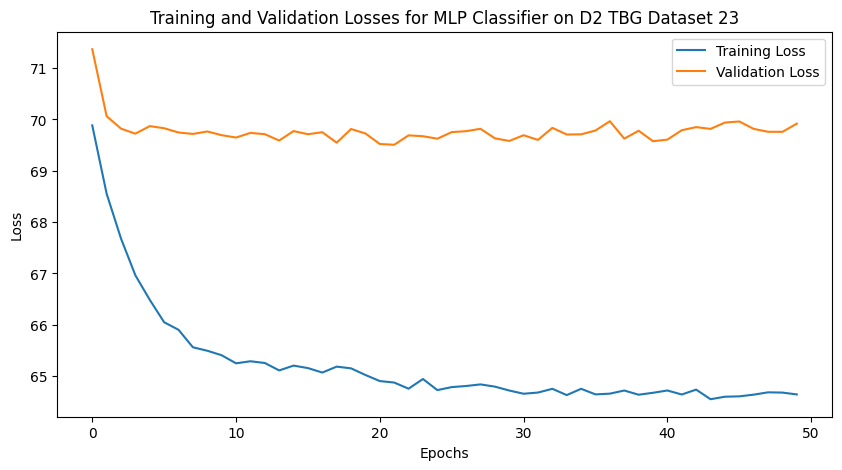

Test Loss: 56.6155, Test Accuracy: 0.6700, AUROC: 0.6959
Training on D2 TBG Dataset 24/33
Epoch 1/50, Training Loss: 70.0802, Validation Loss: 71.4544, Training Accuracy: 0.5854
Epoch 10/50, Training Loss: 65.4322, Validation Loss: 69.6102, Training Accuracy: 0.9090
Epoch 20/50, Training Loss: 65.0376, Validation Loss: 69.6139, Training Accuracy: 0.9375
Epoch 30/50, Training Loss: 64.9867, Validation Loss: 69.7491, Training Accuracy: 0.9410
Epoch 40/50, Training Loss: 64.6836, Validation Loss: 69.8186, Training Accuracy: 0.9597
Epoch 50/50, Training Loss: 64.7993, Validation Loss: 70.1478, Training Accuracy: 0.9528


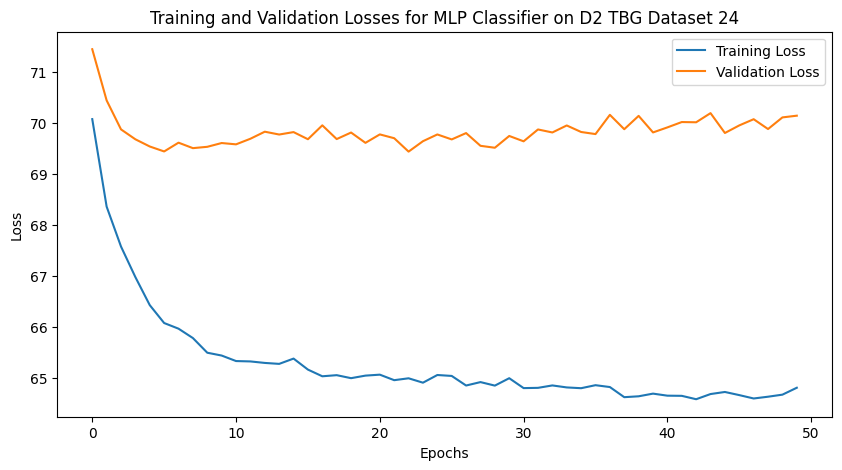

Test Loss: 56.3458, Test Accuracy: 0.6900, AUROC: 0.7000
Training on D2 TBG Dataset 25/33
Epoch 1/50, Training Loss: 69.6150, Validation Loss: 70.3353, Training Accuracy: 0.6167
Epoch 10/50, Training Loss: 65.7158, Validation Loss: 69.6360, Training Accuracy: 0.8917
Epoch 20/50, Training Loss: 65.0898, Validation Loss: 69.5748, Training Accuracy: 0.9285
Epoch 30/50, Training Loss: 64.7368, Validation Loss: 69.4764, Training Accuracy: 0.9521
Epoch 40/50, Training Loss: 64.7366, Validation Loss: 69.7252, Training Accuracy: 0.9535
Epoch 50/50, Training Loss: 64.6809, Validation Loss: 69.5936, Training Accuracy: 0.9549


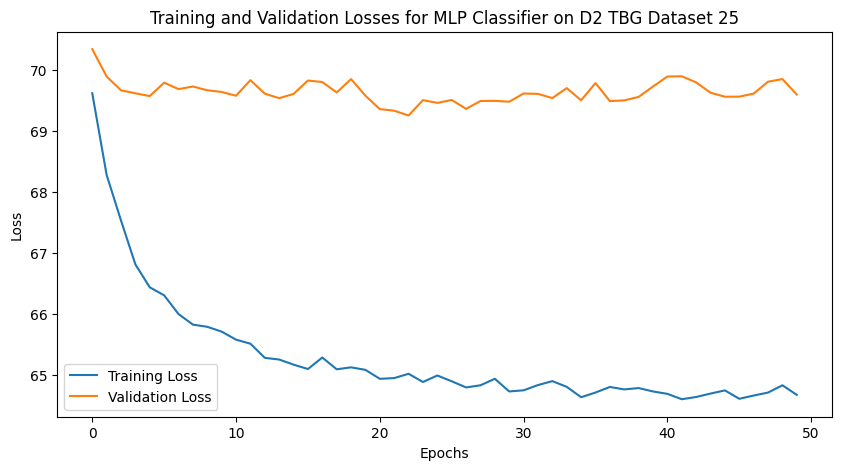

Test Loss: 56.4146, Test Accuracy: 0.6850, AUROC: 0.7100
Training on D2 TBG Dataset 26/33
Epoch 1/50, Training Loss: 69.6210, Validation Loss: 70.4718, Training Accuracy: 0.6285
Epoch 10/50, Training Loss: 65.6149, Validation Loss: 69.7402, Training Accuracy: 0.8979
Epoch 20/50, Training Loss: 65.0222, Validation Loss: 69.7550, Training Accuracy: 0.9389
Epoch 30/50, Training Loss: 64.8020, Validation Loss: 70.2188, Training Accuracy: 0.9507
Epoch 40/50, Training Loss: 64.9446, Validation Loss: 69.9427, Training Accuracy: 0.9382
Epoch 50/50, Training Loss: 64.5965, Validation Loss: 69.8128, Training Accuracy: 0.9632


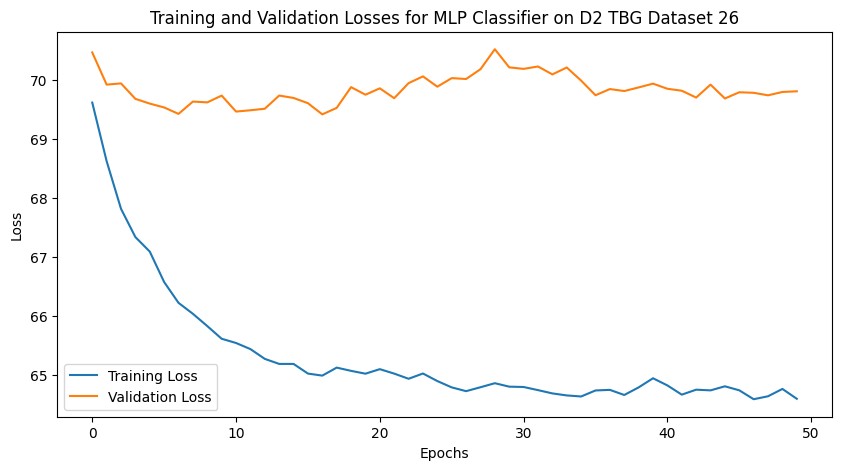

Test Loss: 55.9448, Test Accuracy: 0.7200, AUROC: 0.7432
Training on D2 TBG Dataset 27/33
Epoch 1/50, Training Loss: 69.8193, Validation Loss: 70.2293, Training Accuracy: 0.6146
Epoch 10/50, Training Loss: 65.5707, Validation Loss: 69.4995, Training Accuracy: 0.9056
Epoch 20/50, Training Loss: 65.0505, Validation Loss: 69.3653, Training Accuracy: 0.9333
Epoch 30/50, Training Loss: 64.7456, Validation Loss: 69.6407, Training Accuracy: 0.9549
Epoch 40/50, Training Loss: 64.6564, Validation Loss: 69.9072, Training Accuracy: 0.9576
Epoch 50/50, Training Loss: 64.7142, Validation Loss: 70.0908, Training Accuracy: 0.9549


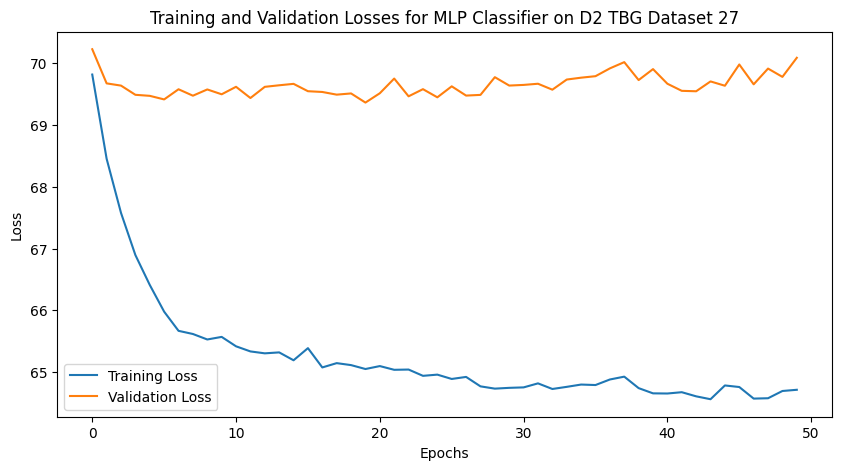

Test Loss: 56.6646, Test Accuracy: 0.6500, AUROC: 0.7099
Training on D2 TBG Dataset 28/33
Epoch 1/50, Training Loss: 69.9216, Validation Loss: 70.9662, Training Accuracy: 0.5979
Epoch 10/50, Training Loss: 65.4068, Validation Loss: 69.3247, Training Accuracy: 0.9132
Epoch 20/50, Training Loss: 64.8517, Validation Loss: 69.7476, Training Accuracy: 0.9444
Epoch 30/50, Training Loss: 64.7643, Validation Loss: 69.8420, Training Accuracy: 0.9535
Epoch 40/50, Training Loss: 64.7693, Validation Loss: 69.8796, Training Accuracy: 0.9556
Epoch 50/50, Training Loss: 64.7730, Validation Loss: 70.0744, Training Accuracy: 0.9528


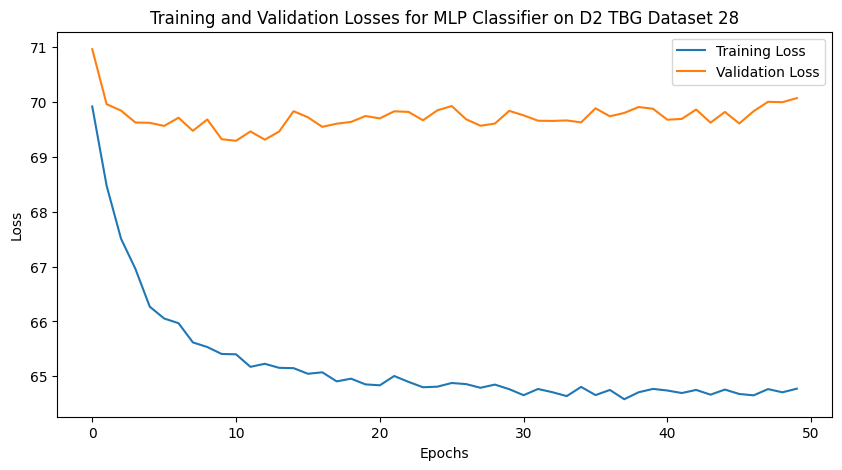

Test Loss: 56.5382, Test Accuracy: 0.6700, AUROC: 0.6997
Training on D2 TBG Dataset 29/33
Epoch 1/50, Training Loss: 69.8033, Validation Loss: 70.7036, Training Accuracy: 0.6181
Epoch 10/50, Training Loss: 65.5900, Validation Loss: 69.8792, Training Accuracy: 0.9000
Epoch 20/50, Training Loss: 64.9596, Validation Loss: 69.9827, Training Accuracy: 0.9410
Epoch 30/50, Training Loss: 64.7797, Validation Loss: 69.5810, Training Accuracy: 0.9486
Epoch 40/50, Training Loss: 64.7248, Validation Loss: 70.0102, Training Accuracy: 0.9549
Epoch 50/50, Training Loss: 64.7908, Validation Loss: 69.5890, Training Accuracy: 0.9521


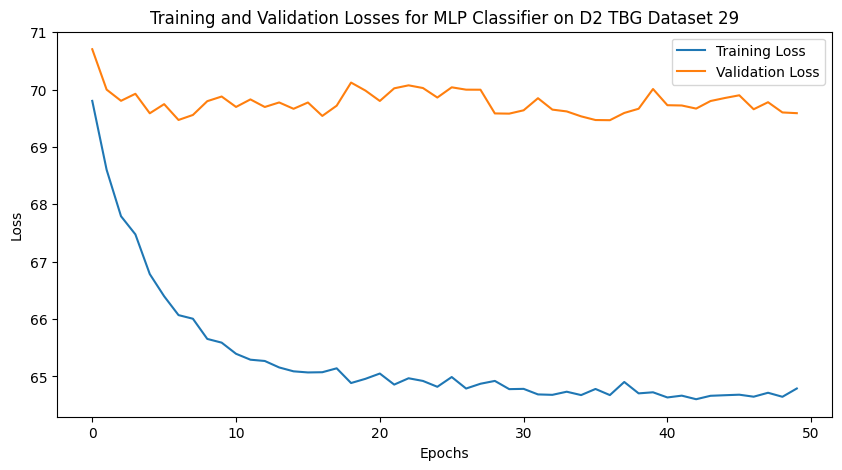

Test Loss: 56.6239, Test Accuracy: 0.6750, AUROC: 0.7203
Training on D2 TBG Dataset 30/33
Epoch 1/50, Training Loss: 69.8627, Validation Loss: 70.6156, Training Accuracy: 0.6049
Epoch 10/50, Training Loss: 65.3358, Validation Loss: 69.8309, Training Accuracy: 0.9111
Epoch 20/50, Training Loss: 64.9110, Validation Loss: 69.9405, Training Accuracy: 0.9424
Epoch 30/50, Training Loss: 64.8090, Validation Loss: 69.9310, Training Accuracy: 0.9493
Epoch 40/50, Training Loss: 64.6423, Validation Loss: 70.1373, Training Accuracy: 0.9611
Epoch 50/50, Training Loss: 64.7100, Validation Loss: 69.9582, Training Accuracy: 0.9576


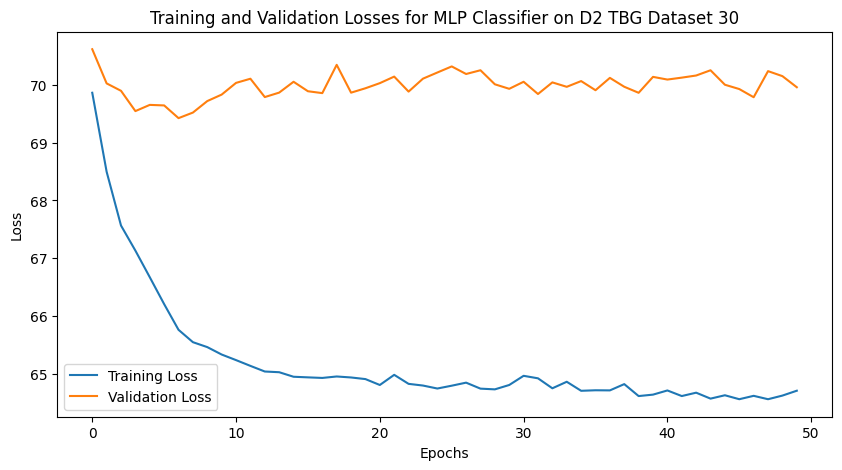

Test Loss: 56.4042, Test Accuracy: 0.6850, AUROC: 0.6978
Training on D2 TBG Dataset 31/33
Epoch 1/50, Training Loss: 69.5120, Validation Loss: 70.5183, Training Accuracy: 0.6181
Epoch 10/50, Training Loss: 65.4285, Validation Loss: 69.7568, Training Accuracy: 0.9076
Epoch 20/50, Training Loss: 64.9204, Validation Loss: 69.8915, Training Accuracy: 0.9437
Epoch 30/50, Training Loss: 64.6092, Validation Loss: 69.8782, Training Accuracy: 0.9625
Epoch 40/50, Training Loss: 64.5622, Validation Loss: 69.9069, Training Accuracy: 0.9681
Epoch 50/50, Training Loss: 64.4266, Validation Loss: 70.1760, Training Accuracy: 0.9743


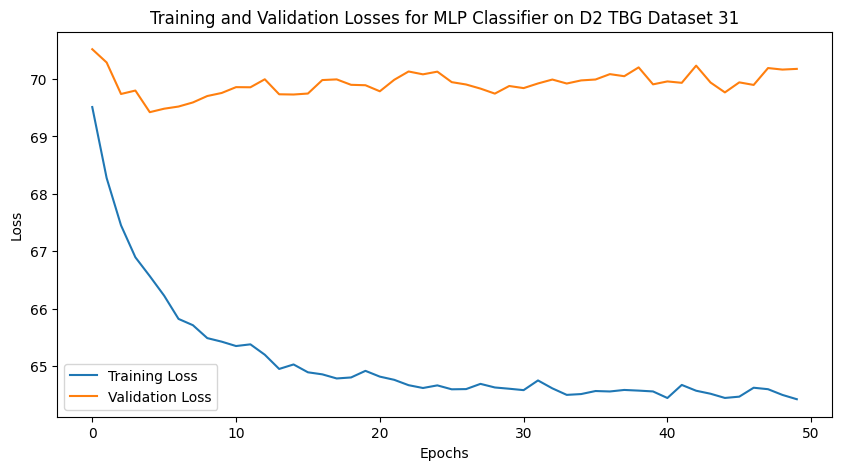

Test Loss: 56.7306, Test Accuracy: 0.6600, AUROC: 0.6989
Training on D2 TBG Dataset 32/33
Epoch 1/50, Training Loss: 69.6788, Validation Loss: 70.8037, Training Accuracy: 0.6118
Epoch 10/50, Training Loss: 65.4154, Validation Loss: 69.6950, Training Accuracy: 0.9097
Epoch 20/50, Training Loss: 64.9254, Validation Loss: 69.6455, Training Accuracy: 0.9403
Epoch 30/50, Training Loss: 64.7142, Validation Loss: 69.7313, Training Accuracy: 0.9535
Epoch 40/50, Training Loss: 64.6123, Validation Loss: 69.6703, Training Accuracy: 0.9618
Epoch 50/50, Training Loss: 64.5347, Validation Loss: 69.8764, Training Accuracy: 0.9653


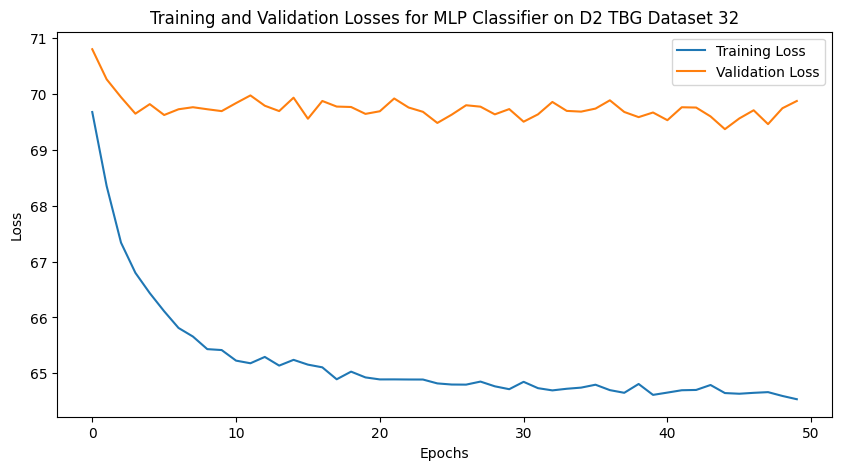

Test Loss: 56.8254, Test Accuracy: 0.6450, AUROC: 0.6999
Training on D2 TBG Dataset 33/33
Epoch 1/50, Training Loss: 69.8418, Validation Loss: 70.8379, Training Accuracy: 0.6132
Epoch 10/50, Training Loss: 65.9100, Validation Loss: 69.7163, Training Accuracy: 0.8757
Epoch 20/50, Training Loss: 65.1064, Validation Loss: 69.6101, Training Accuracy: 0.9271
Epoch 30/50, Training Loss: 64.7984, Validation Loss: 69.6013, Training Accuracy: 0.9514
Epoch 40/50, Training Loss: 64.6271, Validation Loss: 69.8899, Training Accuracy: 0.9632
Epoch 50/50, Training Loss: 64.5071, Validation Loss: 69.7602, Training Accuracy: 0.9681


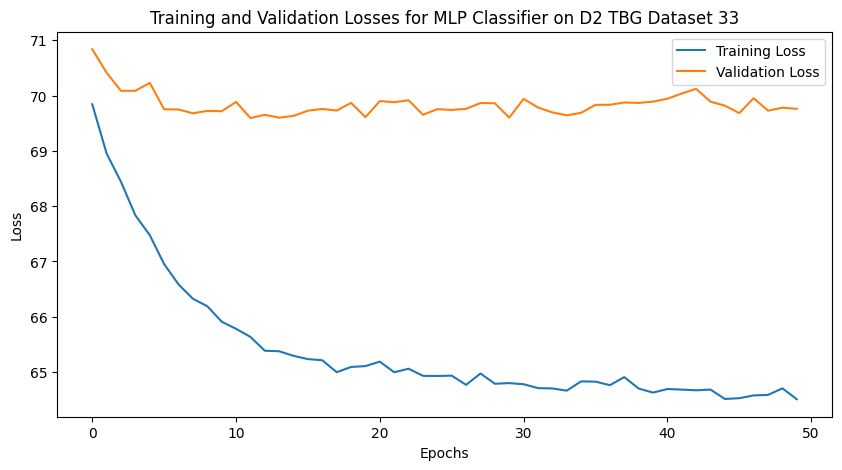

Test Loss: 56.2627, Test Accuracy: 0.6950, AUROC: 0.6905


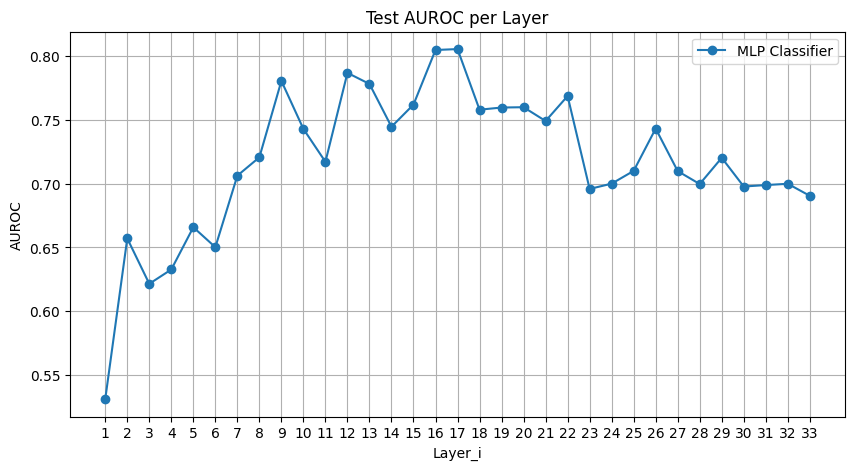

In [237]:
# Continual Training with MLP.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4096   # Token embedding dimensions
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 50
tabmlp2_test_accs = []
tabmlp2_test_aucs = []
tabmlp2_trained_models = []

for i, (train_loader, valid_loader, test_loader) in enumerate(zip(d2b_tbg_train_dataloaders, d2b_tbg_valid_dataloaders, d2b_tbg_test_dataloaders)):
    print(f"Training on D2 TBG Dataset {i+1}/{len(d2b_tbg_train_dataloaders)}")
    model = MLPClassifier(in_dim, hid_dims, dropout)
    model.load_state_dict(tabmlp_trained_models[i].state_dict())
    train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on D2 TBG Dataset {i+1}", silent=False)
    test_loss, test_acc, test_auc = evaluate_on_test(model, test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tabmlp2_test_accs.append(test_acc)
    tabmlp2_test_aucs.append(test_auc)
    tabmlp2_trained_models.append(model)

plot_1d_metrics([tabmlp2_test_aucs], ['MLP Classifier'], 'AUROC')

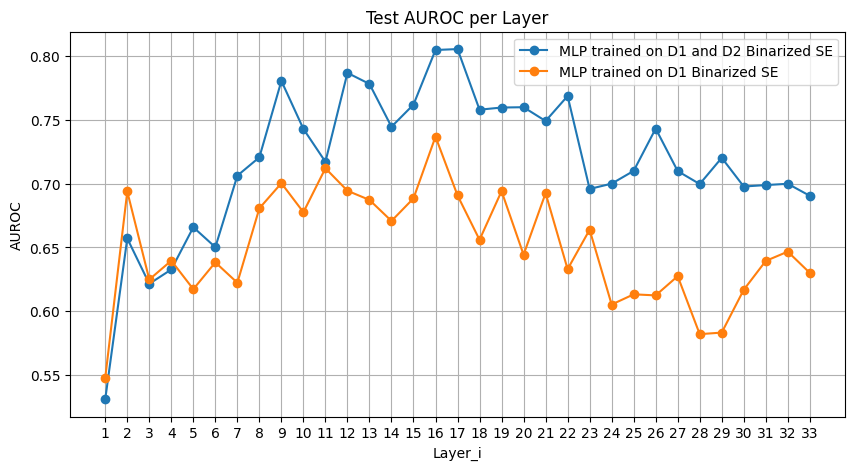

In [259]:
plot_1d_metrics([tabmlp2_test_aucs, tmlp2b_test_aucs], ['MLP trained on D1 and D2 Binarized SE', 'MLP trained on D1 Binarized SE'], 'AUROC')

#### Test on D3 with D1 models and [D1,D2] models

The models are trained or continually trained with **binarized SE's** from D1 and D2 datasets, being tested on D3's **Accuracy scores**.

In [261]:
# Prepare test sets from D3.
total_size = 300
_, _, d3b_tbg_test_dataloaders = create_dataloaders(d3_tok_bef_gen_layered_datasets, d3_bca_entropy, total_size, batch_size, set_seed=True)
d3_r_accuracies = 1 - d3_accuracies
_, _, d3a_tbg_test_dataloaders = create_dataloaders(d3_tok_bef_gen_layered_datasets, d3_r_accuracies, total_size, batch_size, set_seed=True)

_, _, d3b_X_tests, _, _, d3b_y_tests = create_Xs_and_ys(d3_tok_bef_gen_layered_datasets, d3_bca_entropy, total_size)
_, _, d3a_X_tests, _, _, d3a_y_tests = create_Xs_and_ys(d3_tok_bef_gen_layered_datasets, d3_r_accuracies, total_size)

Test Loss: 0.7072, Test Accuracy: 0.2667, AUROC: 0.1786
Test Loss: 0.3840, Test Accuracy: 0.9333, AUROC: 0.1429
Test Loss: 0.6749, Test Accuracy: 0.6333, AUROC: 0.1964
Test Loss: 0.3564, Test Accuracy: 0.9333, AUROC: 0.1607
Test Loss: 0.7473, Test Accuracy: 0.3333, AUROC: 0.2321
Test Loss: 0.3923, Test Accuracy: 0.9333, AUROC: 0.2857
Test Loss: 0.9778, Test Accuracy: 0.3333, AUROC: 0.3750
Test Loss: 0.4040, Test Accuracy: 0.9333, AUROC: 0.1786
Test Loss: 0.7901, Test Accuracy: 0.4333, AUROC: 0.3929
Test Loss: 0.4068, Test Accuracy: 0.9333, AUROC: 0.1964
Test Loss: 1.1492, Test Accuracy: 0.4333, AUROC: 0.4286
Test Loss: 0.3709, Test Accuracy: 0.9333, AUROC: 0.1429
Test Loss: 1.6428, Test Accuracy: 0.4000, AUROC: 0.3571
Test Loss: 0.3839, Test Accuracy: 0.9333, AUROC: 0.1607
Test Loss: 0.4923, Test Accuracy: 0.8333, AUROC: 0.3571
Test Loss: 0.4098, Test Accuracy: 0.9333, AUROC: 0.0893
Test Loss: 0.6847, Test Accuracy: 0.4667, AUROC: 0.5536
Test Loss: 0.5489, Test Accuracy: 0.9333, AUROC:

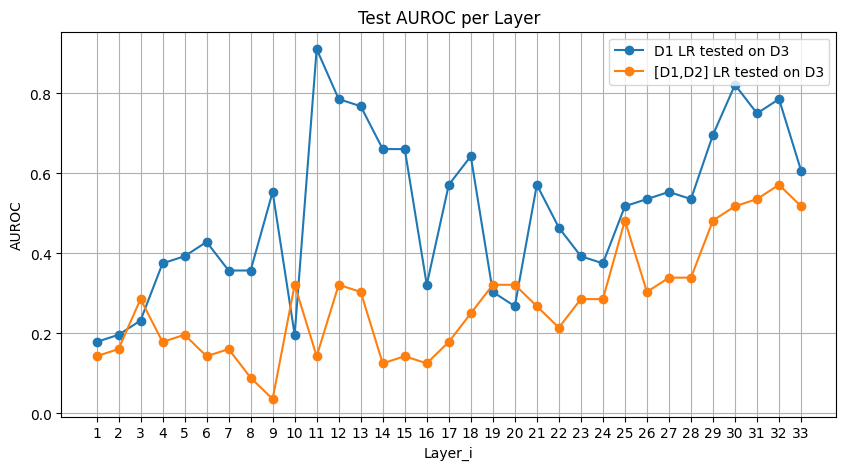

In [262]:
# Test trained LRs from D1 or [D1, D2] on D3.
# Test on Accuracy
tlr13a_test_accs = []
tlr13a_test_aucs = []
tlr23a_test_accs = []
tlr23a_test_aucs = []

for i, (X_test, y_test) in enumerate(zip(d3a_X_tests, d3a_y_tests)):
    # print("LR Model pretrained on D1 only")
    _, test_acc1, test_auc1 = sklearn_evaluate_on_test(tablr_trained_models[i], X_test, y_test, binary_cls=True)
    # print("LR Model pretrained on D1 and D2")
    _, test_acc2, test_auc2 = sklearn_evaluate_on_test(tablr2_trained_models[i], X_test, y_test, binary_cls=True)
    tlr13a_test_accs.append(test_acc1)
    tlr13a_test_aucs.append(test_auc1)
    tlr23a_test_accs.append(test_acc2)
    tlr23a_test_aucs.append(test_auc2)

# plot_1d_metrics([tlr2b_test_accs], ['Logistic Regression on Binarized SE'], 'Accuracy')
plot_1d_metrics([tlr13a_test_aucs, tlr23a_test_aucs], ["D1 LR tested on D3", "[D1,D2] LR tested on D3"], 'AUROC')

In [281]:
max(tlr13a_test_aucs), max(tlr23a_test_aucs)

(0.9107142857142858, 0.5714285714285714)

Test Loss: 96.4211, Test Accuracy: 0.8333, AUROC: 0.4643
Test Loss: 95.7372, Test Accuracy: 0.9333, AUROC: 0.2143
Test Loss: 96.4062, Test Accuracy: 0.8333, AUROC: 0.5893
Test Loss: 95.7813, Test Accuracy: 0.9333, AUROC: 0.2857
Test Loss: 95.2577, Test Accuracy: 0.0667, AUROC: 0.3750
Test Loss: 95.9657, Test Accuracy: 0.9333, AUROC: 0.3214
Test Loss: 97.2243, Test Accuracy: 0.2333, AUROC: 0.6071
Test Loss: 96.6228, Test Accuracy: 0.6000, AUROC: 0.2857
Test Loss: 97.6636, Test Accuracy: 0.6667, AUROC: 0.5179
Test Loss: 95.7151, Test Accuracy: 0.9000, AUROC: 0.3125
Test Loss: 97.7347, Test Accuracy: 0.7000, AUROC: 0.5714
Test Loss: 95.9921, Test Accuracy: 0.8667, AUROC: 0.3036
Test Loss: 95.9993, Test Accuracy: 0.8333, AUROC: 0.2321
Test Loss: 95.2335, Test Accuracy: 0.9333, AUROC: 0.4464
Test Loss: 96.1095, Test Accuracy: 0.8333, AUROC: 0.4107
Test Loss: 95.2337, Test Accuracy: 0.9333, AUROC: 0.2232
Test Loss: 95.2336, Test Accuracy: 0.9333, AUROC: 0.5714
Test Loss: 95.2335, Test Accura

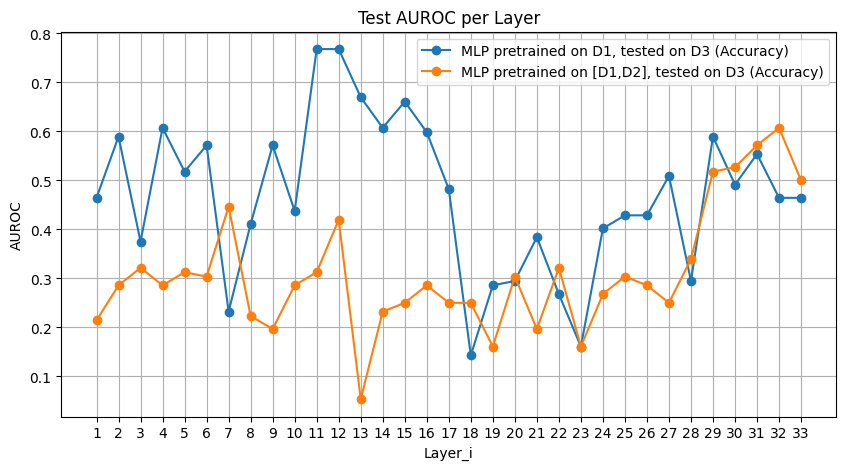

In [263]:
# Test D1/[D1,D2]-pretrained MLP on Accuracy's from D3 
tmlp13a_test_accs = []
tmlp13a_test_aucs = []
tmlp23a_test_accs = []
tmlp23a_test_aucs = []

for i, test_loader in enumerate(d3a_tbg_test_dataloaders):
    test_loss, test_acc1, test_auc1 = evaluate_on_test(tabmlp_trained_models[i], test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    test_loss, test_acc2, test_auc2 = evaluate_on_test(tabmlp2_trained_models[i], test_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tmlp13a_test_accs.append(test_acc1)
    tmlp13a_test_aucs.append(test_auc1)
    tmlp23a_test_accs.append(test_acc2)
    tmlp23a_test_aucs.append(test_auc2)

plot_1d_metrics([tmlp13a_test_aucs, tmlp23a_test_aucs], ['MLP pretrained on D1, tested on D3 (Accuracy)', 'MLP pretrained on [D1,D2], tested on D3 (Accuracy)'], 'AUROC')

In [282]:
max(tmlp13a_test_aucs), max(tmlp23a_test_aucs)

(0.7678571428571428, 0.6071428571428571)

Although models continually trained on D1 and D2 achieve better AUROC on D2's binarized SE test set, they do not fare as well on extrapolating to the Accuracy prediction on a third dataset D3 as what models trained on D1 do. 